# Setup

In [9]:

FIG_WIDTH = 7.5
MY_FONT_SIZE = 9

plt.rcParams.update({

    # --- Fonts ---
    "font.family": "Arial",
    "font.size": MY_FONT_SIZE,

    # --- Legend ---
    "legend.fontsize": MY_FONT_SIZE,
    "legend.frameon": False,

    # --- Titles ---
    "figure.titlesize": MY_FONT_SIZE,
    "axes.titleweight": "normal",
    "axes.titlesize": MY_FONT_SIZE,

    # --- Axes ---
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "axes.unicode_minus": True,
    "axes.labelsize": MY_FONT_SIZE,

    # --- Lines & markers ---
    "lines.linewidth": 1.0,
    "lines.markersize": 0.7,

    # --- Ticks ---
    "xtick.labelsize": MY_FONT_SIZE,
    "ytick.labelsize": MY_FONT_SIZE,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.bottom": True,
    "ytick.left": True,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "axes.linewidth": 0.7,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,

    # Grid
    "axes.grid": False,
    "grid.linestyle": ":",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.5,

    # --- Layout ---
    "figure.autolayout": True,

    # --- DPI ---
    "savefig.dpi": 900,
    "figure.dpi": 300,
})


In [10]:
# Notebook runtime flags (set these to True to run long experiments)
RUN_OPTUNA = False
RUN_BENCHMARKS = False


def unpack_bursty_output(out):
    """Normalize simulate_bursty_signal output to (signal, states, bursts, noise).

    Supports:
    - dict-like outputs with keys {signal, states, bursts, noise} (preferred)
    - tuple/list outputs in either (signal, states, bursts, noise) or (states, bursts, noise, signal)
    """
    import numpy as np

    if isinstance(out, dict):
        # Prefer explicit keys if they exist
        if "signal" in out and "states" in out:
            signal = out.get("signal")
            states = out.get("states")
            bursts = out.get("bursts", None)
            noise = out.get("noise", None)
            if bursts is None or noise is None:
                vals = list(out.values())
                if len(vals) >= 4:
                    signal2, states2, bursts2, noise2 = vals[:4]
                    signal = signal if signal is not None else signal2
                    states = states if states is not None else states2
                    bursts = bursts if bursts is not None else bursts2
                    noise = noise if noise is not None else noise2
            return signal, states, bursts, noise

        # Fallback: insertion order
        vals = list(out.values())
        if len(vals) >= 4:
            signal, states, bursts, noise = vals[:4]
            return signal, states, bursts, noise
        raise ValueError(f"simulate_bursty_signal returned dict with unexpected keys={list(out.keys())}")

    if isinstance(out, (list, tuple)):
        if len(out) < 4:
            raise ValueError(f"simulate_bursty_signal returned {type(out).__name__} of length {len(out)} (<4)")
        a, b, c, d = out[:4]
        if isinstance(a, np.ndarray) and np.issubdtype(a.dtype, np.integer):
            states, bursts, noise, signal = a, b, c, d
            return signal, states, bursts, noise
        signal, states, bursts, noise = a, b, c, d
        return signal, states, bursts, noise

    raise TypeError(f"simulate_bursty_signal returned unsupported type: {type(out)}")


In [11]:


from itertools import groupby

import torch
#computing spectrum
from neurodsp.spectral import compute_spectrum
from scipy.optimize import linear_sum_assignment

#computing spectrum


In [12]:


from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoNormal
from pyro.optim import Adam

In [13]:

import pandas as pd
import matplotlib.pyplot as plt

FIG_WIDTH = 7.5
MY_FONT_SIZE = 9

plt.rcParams.update({
    # --- Fonts ---
    "font.family": "Arial",
    "font.size": MY_FONT_SIZE,

    # --- Legend ---
    "legend.fontsize": MY_FONT_SIZE,
    "legend.frameon": False,

    # --- Titles ---
    "figure.titlesize": MY_FONT_SIZE,
    "axes.titleweight": "normal",
    "axes.titlesize": MY_FONT_SIZE,

    # --- Axes ---
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "axes.unicode_minus": True,
    "axes.labelsize": MY_FONT_SIZE,

    # --- Lines & markers ---
    "lines.linewidth": 1.0,
    "lines.markersize": 0.7,

    # --- Ticks ---
    "xtick.labelsize": MY_FONT_SIZE,
    "ytick.labelsize": MY_FONT_SIZE,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.bottom": True,
    "ytick.left": True,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "axes.linewidth": 0.7,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,

    # Grid
    "axes.grid": False,
    "grid.linestyle": ":",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.5,

    # --- Layout ---
    "figure.autolayout": True,

    # --- DPI ---
    "savefig.dpi": 900,
    "figure.dpi": 300,
})


## Burst simulator

In [14]:
from nds_toolbox.sim.bursts.simulator import simulate_bursty_signal
from nds_toolbox.preprocessing.features import (compute_tde, trim_data)
from nds_toolbox.preprocessing.features import choose_embedding_dim


In [161]:
"""
The following burst simulator is inspired from:
- "Quinn2019_BurstHMM/hmm_util_get_simulation.m"
- "Cho2022_BurstDetection/utils/util_data/generates_simulaiton.m"
- Cole, S., Donoghue, T., Gao, R., & Voytek, B. (2019). NeuroDSP: A package for
neural digital signal processing. Journal of Open Source Software, 4(36), 1272.
DOI: 10.21105/joss.01272
"""

import numpy as np
from scipy.signal import sawtooth
from scipy.signal.windows import tukey
from neurodsp.filt import filter_signal


def _get_duration(duration_param, rng):
    """
    Determines a duration value.

    If duration_param is a scalar (int or float), returns it.
    If it is a two-element list/tuple/array, returns a random value drawn uniformly
    between the two values.
    """
    if isinstance(duration_param, (list, tuple, np.ndarray)) and len(duration_param) == 2:
        return rng.uniform(duration_param[0], duration_param[1])
    elif np.isscalar(duration_param):
        return duration_param
    else:
        raise ValueError("Duration parameter must be a scalar or a two-element list/tuple/array.")


def make_transition_matrix(num_states, state_transition, trans_mat=None):
    if num_states < 2:
        raise ValueError("num_states must be at least 2.")

    if state_transition == "custom":
        if trans_mat is None:
            raise ValueError("trans_mat must be provided when state_transition='custom'.")
        trans_mat = np.asarray(trans_mat, dtype=float)

        if trans_mat.shape != (num_states, num_states):
            raise ValueError(
                f"trans_mat must have shape ({num_states}, {num_states}), got {trans_mat.shape}."
            )

        if not np.allclose(trans_mat.sum(axis=1), 1.0):
            raise ValueError("Each row of trans_mat must sum to 1.")

    elif state_transition == "uniform":
        trans_mat = np.ones((num_states, num_states), dtype=float) / num_states

    elif state_transition == "uniform_except_self":
        trans_mat = np.ones((num_states, num_states), dtype=float)
        np.fill_diagonal(trans_mat, 0.0)
        trans_mat /= (num_states - 1)

    elif state_transition == "return_to_baseline":
        trans_mat = np.zeros((num_states, num_states), dtype=float)
        trans_mat[0, 1:] = 1.0 / (num_states - 1)  # baseline -> others
        trans_mat[1:, 0] = 1.0  # others -> baseline

    else:
        raise ValueError(
            "state_transition must be one of: "
            "'custom', 'uniform', 'uniform_except_self', 'return_to_baseline'."
        )

    return trans_mat


def _simulate_bursts(
        time_vec,
        fs,
        f,
        burst_cycles,
        noise_duration,
        burst_type,
        state_transition="uniform",
        transition_matrix=None,
        burst_amp_sigma=0.1,
        chi=0.15,
        use_tukey=True,
        tukey_alpha=0.25,
        power_law_scale=True,
        rng=None,
):
    """
    Simulate a signal consisting of alternating noise and burst segments.

    State 0 is reserved for noise, and states 1..K are burst states.

    Parameters
    ----------
    time_vec : array-like
        Time points for the simulation.
    fs : float
        Sampling frequency in Hz.
    f : scalar or array-like
        Burst frequency/frequencies in Hz.
        - If scalar, all burst states use the same frequency.
        - If array-like, its length defines the number of burst states.
    burst_cycles : scalar or length-2 sequence
        Number of cycles per burst.
        - If scalar, use a fixed number of cycles.
        - If length-2, draw an integer uniformly from [min, max].
    noise_duration : scalar or length-2 sequence
        Noise duration in seconds.
        - If scalar, use a fixed duration.
        - If length-2, draw uniformly from [min, max].
    burst_type : {"sine", "sawtooth"}
        Waveform used for burst segments.

    state_transition (str): Transition rule governing how the latent state
        sequence evolves over time.

        - "custom": use the user-specified `transition_matrix`.
        - "uniform": transition uniformly across all states, including the
          current state.
        - "uniform_except_self": transition uniformly across all states
          except the current state.
        - "return_to_baseline": treat state 0 as the baseline state; state 0
          transitions uniformly to nonzero states, and all nonzero states
          transition back to state 0.

    transition_matrix (array-like or None): Transition probability matrix
        used only when `state_transition="custom"`. It must have shape
        `(num_states, num_states)`, where each row specifies the
        probabilities of transitioning from one state to all possible next
        states.

    burst_amp_sigma : float
        Standard deviation of burst amplitude variation.
        Currently one amplitude is sampled per burst, not per cycle.
    chi : float
        Exponent for optional 1/f^chi amplitude scaling.
    use_tukey : bool
        Whether to apply a Tukey window to each burst.
    tukey_alpha : float
        Alpha parameter for the Tukey window.
    power_law_scale : bool
        Whether to scale burst amplitude by 1 / f^chi when multiple frequencies are used.
    rng : np.random.Generator or None
        Random number generator.

    Returns
    -------
    signal : ndarray, shape (T,)
        Simulated signal.
    states : ndarray, shape (T,)
        Integer-valued state sequence. State 0 = noise, states 1..K = burst states.
    """
    if rng is None:
        rng = np.random.default_rng()

    freqs_array = np.atleast_1d(np.asarray(f, dtype=float))
    if np.any(freqs_array <= 0):
        raise ValueError("All frequencies in `f` must be positive.")

    use_scalar_freq = freqs_array.size == 1
    num_states = freqs_array.size + 1  # state 0 = noise
    init_p = np.ones(num_states, dtype=float) / num_states

    signal = np.zeros(len(time_vec), dtype=float)
    states = np.zeros(len(time_vec), dtype=int)

    trans_mat = make_transition_matrix(
        num_states=num_states,
        state_transition=state_transition,
        trans_mat=transition_matrix,
    )

    t = 0.0
    last_state = None

    while int(round(t * fs)) < len(time_vec):
        start_idx = int(round(t * fs))
        if start_idx >= len(time_vec):
            break

        # sample current state
        if last_state is None:
            current_state = rng.choice(num_states, p=init_p)
        else:
            current_state = rng.choice(num_states, p=trans_mat[last_state])

        last_state = current_state

        if current_state == 0:
            # ----- noise segment -----
            curr_noise_duration = _get_duration(noise_duration, rng)
            n_noise_samples = int(round(curr_noise_duration * fs))
            end_idx = min(start_idx + n_noise_samples, len(time_vec))

            states[start_idx:end_idx] = 0

            # advance using sample count to avoid drift
            t += (end_idx - start_idx) / fs

        else:
            # ----- burst segment -----
            freq_burst = freqs_array[0] if use_scalar_freq else freqs_array[current_state - 1]

            if isinstance(burst_cycles, (list, tuple, np.ndarray)) and len(burst_cycles) == 2:
                num_cycles = rng.integers(burst_cycles[0], burst_cycles[1] + 1)
            elif np.isscalar(burst_cycles):
                num_cycles = int(burst_cycles)
            else:
                raise ValueError("`burst_cycles` must be a scalar or a two-element sequence.")

            if num_cycles <= 0:
                raise ValueError("`burst_cycles` must be positive.")

            samples_per_cycle = int(round(fs / freq_burst))
            if samples_per_cycle <= 0:
                raise ValueError("Invalid samples_per_cycle. Check `fs` and `f`.")

            total_samples = samples_per_cycle * num_cycles
            aligned_time = np.arange(total_samples) / fs

            burst_amplitude = np.abs(rng.normal(loc=1.0, scale=burst_amp_sigma))

            if (not use_scalar_freq) and power_law_scale:
                burst_amplitude *= 1.0 / (freq_burst ** chi)

            if burst_type == "sine":
                burst_signal = burst_amplitude * np.sin(2 * np.pi * freq_burst * aligned_time)
            elif burst_type == "sawtooth":
                burst_signal = burst_amplitude * sawtooth(2 * np.pi * freq_burst * aligned_time, width=1)
            else:
                raise ValueError("Unsupported `burst_type`. Choose 'sine' or 'sawtooth'.")

            if use_tukey:
                burst_signal *= tukey(total_samples, alpha=tukey_alpha)

            end_idx = min(start_idx + total_samples, len(time_vec))
            burst_signal = burst_signal[: end_idx - start_idx]

            signal[start_idx:end_idx] = burst_signal
            states[start_idx:end_idx] = current_state

            # advance using exact written sample count
            t += (end_idx - start_idx) / fs

    return signal, states


def _generate_colored_noise(num_data, fs, beta=1, rng=None):
    """
    Generate colored noise with a 1/f^beta power spectrum.

    Parameters:
        beta (float): Exponent for the 1/f^beta distribution.
                      Use beta=0 for white noise, beta=1 for pink noise, beta=2 for brown noise.
        num_data (int): Number of samples in the noise signal.

    Returns:
        np.ndarray: The generated noise signal.

    Notes:
        - This function is based on neurodsp.sim.aperiodic.sim_powerlaw.[1]
        - The original reference is [2]

    References:
        [1] Cole, S., Donoghue, T., Gao, R., & Voytek, B. (2019). NeuroDSP: A package for
neural digital signal processing. Journal of Open Source Software, 4(36), 1272.
DOI: 10.21105/joss.01272. https://neurodsp-tools.github.io/neurodsp/_modules/neurodsp/sim/aperiodic.html#sim_powerlaw
        [2] Timmer, J., & Konig, M. (1995). On Generating Power Law Noise.
           Astronomy and Astrophysics, 300, 707–710.
    """

    if rng is None:
        rng = np.random.default_rng()

    # Generate white noise in the time domain.
    white_noise = rng.standard_normal(num_data)

    # Transform to frequency domain using the real FFT.
    spectrum = np.fft.rfft(white_noise)

    # Create frequency array; np.fft.rfftfreq returns frequencies for the rFFT.
    f = np.fft.rfftfreq(num_data, 1 / fs)

    spectrum[1:] /= f[1:] ** (beta / 2)  # |spectrum| ∝ 1/f^(β/2) (hence, power ∝ 1/f^β)
    spectrum[0] = 0

    # Transform back to the time domain.
    colored_noise = np.fft.irfft(spectrum, n=num_data).real
    #colored_noise = (colored_noise - colored_noise.mean()) / colored_noise.std()

    return np.array(colored_noise)


def _add_noise(bursts, states, noise, snr_db, use_filter=True, fs=None, highpass_f=0.5):
    """
    Mix a clean burst signal with noise to achieve a target SNR (dB).

    Parameters
    ----------
    bursts : 1-D array
        Array that already contains bursts *and* zeros where there is noise.
    states : 1-D int array
        Parallel state vector (0 = noise gaps, >0 = burst indices).
    noise : 1-D array
        Noise signal (same length as bursts).
    snr_db : float
        Desired SNR, in decibels, defined as
            10·log10( signal_power / noise_power ).

    Returns
    -------
    noisy : 1-D array
        bursts + scaled_noise
    """

    if bursts.shape != noise.shape or bursts.shape != states.shape:
        raise ValueError("bursts, noise, and states must have identical shapes")
    if use_filter and (fs is None or highpass_f is None):
        raise ValueError("`fs` and `filter_frequency` must be provided when use_filter=True")

    bursts_copy = bursts.copy()
    noise_copy = noise.copy()  # this will be scaled based on SNR below
    all_states = np.unique(states)

    if use_filter:
        filtered_noise = filter_signal(noise_copy, fs, 'highpass', f_range=(highpass_f, None), remove_edges=False)

    else:
        filtered_noise = noise_copy

    noise_power = np.var(filtered_noise)
    for s in all_states:

        mask = states == s

        if s == 0:
            burst_power = np.var(bursts_copy[states != 0])

        else:
            burst_power = np.var(bursts_copy[mask])

        # desired noise power for that SNR
        snr_linear = 10 ** (snr_db / 10)
        desired_burst_power = snr_linear * noise_power

        # Scale bursts
        scaling_factor = np.sqrt(desired_burst_power / burst_power)
        bursts_copy[mask] *= scaling_factor

    return bursts_copy + noise_copy, bursts_copy


def simulate_bursty_signal(
        time_vec,
        fs,
        freq,
        burst_cycles_param,
        noise_duration_param,
        state_transition='uniform',
        transition_matrix=None,
        burst_type="sine",
        use_filter=True,
        highpass_f=0.5,
        snr_db=0,
        burst_amp_sigma=0.1,
        beta=1,
        power_law_scale = True,
        chi=0.15,
        use_tukey=True,
        tukey_alpha=0.25,
        rng=None):
    """
    Simulate a bursty signal with added noise.

    """

    if rng is None:
        rng = np.random.default_rng()

    # Generate bursts using the specified burst type and amplitude scale.
    bursts, states = _simulate_bursts(
        time_vec, fs, freq,
        burst_cycles_param, noise_duration_param, state_transition=state_transition,
        transition_matrix=transition_matrix,
        burst_type=burst_type, burst_amp_sigma=burst_amp_sigma,
        power_law_scale=power_law_scale, chi =chi,
        use_tukey=use_tukey, tukey_alpha=tukey_alpha, rng=rng
    )

    # Generate colored noise
    noise = _generate_colored_noise(len(time_vec), fs, beta, rng=rng)

    # scale noise based on the desired SNR
    signal, scaled_bursts = _add_noise(bursts, states, noise, snr_db, use_filter=use_filter, fs=fs,highpass_f=highpass_f)

    return {"signal": signal,
            "states": states,
            "bursts": scaled_bursts,
            "noise": noise, }


In [209]:

# Set seeds for reproducibility.
seed = 2025
rng = np.random.default_rng(seed)

# ---parameters for burst simulator---
n_seconds = 60 * 3  # Total duration in seconds.

fs = 250
time_vec = np.linspace(0, n_seconds, int(fs * n_seconds))

snr_db = 0

freq = np.array([20, 40])  #ground truth = 4 states (including noise state)

# For burst segments, specify duration as the number of cycles.
burst_cycles = [3, 12]  #[3, 7]

# For noise segments, specify duration in seconds.
noise_duration = [0.5, 2]  #[0.5, 3.]

burst_amp_sigma = 0.1

beta = 1  #pink noise

state_transition = 'return_to_baseline'
tukey_alpha = 0.25

num_states = len(freq) + 1

## simulate a bursty signal
out = simulate_bursty_signal(time_vec, fs, freq, burst_cycles, noise_duration, state_transition=state_transition,
                             burst_type="sine", use_filter=True, snr_db=snr_db, burst_amp_sigma=burst_amp_sigma,
                             beta=beta, tukey_alpha=tukey_alpha, rng=rng)

signal, states, bursts, noise = out.values()
states_onehot = np.eye(num_states)[states]


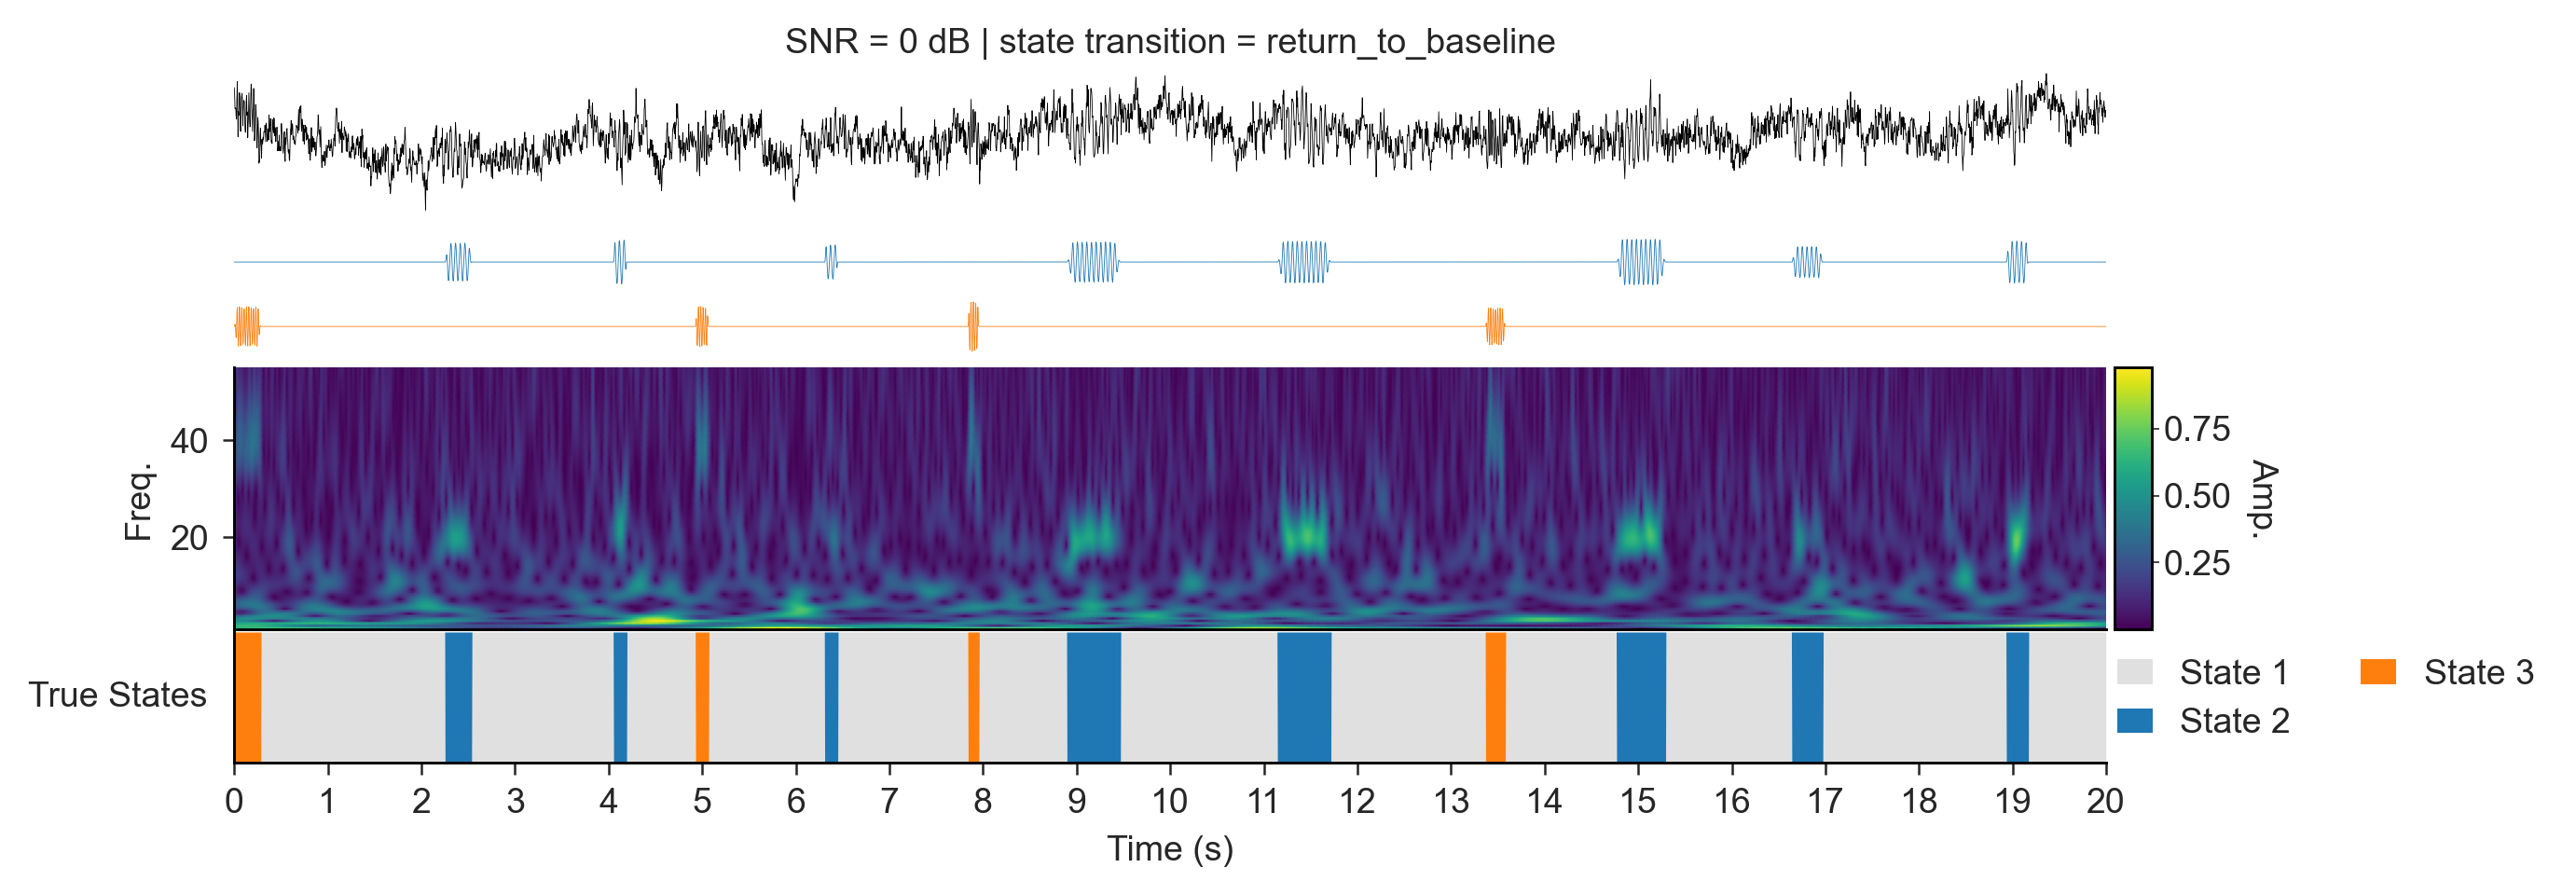

In [210]:



import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from nds_toolbox.preprocessing.features import compute_wavelet

plot_t = 20
#compute wavelet
t, f, amp = compute_wavelet(signal[:plot_t * fs], fs, f_min=1, f_max=80, df=0.5, wavelet="cmor1.5-1.0")

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"State {i + 1}" for i in range(num_states)]

mosaic = [["b1", "b1"],
          ["b2", "b2"],
          ["b3", "b3"],
          ]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 3),  # a hair taller
    constrained_layout=True,
    gridspec_kw={"height_ratios": [0.7, 0.6, 0.3]}
)
fig.set_constrained_layout_pads(w_pad=0., h_pad=0., hspace=0.01)

axes["b1"].plot(time_vec[:plot_t * fs], 0.3 * (signal[:plot_t * fs]), lw=0.2, color="k")
axes["b1"].grid(False)
axes["b1"].set_frame_on(False)

axes["b1"].set_title(f"SNR = {snr_db} dB | state transition = {state_transition}", pad=0.3)

axes["b1"].plot(time_vec[:plot_t * fs], 0.3 * (-2 + bursts[:plot_t * fs] * (states[:plot_t * fs] == 1)), lw=0.2,
                color=colors[1])
axes["b1"].plot(time_vec[:plot_t * fs], 0.3 * (-3 + bursts[:plot_t * fs] * (states[:plot_t * fs] == 2)), lw=0.2,
                color=colors[2])

axes["b1"].set_yticks([])
axes["b1"].set_xticks([])

for s in ("top", "right", "bottom", "left"):
    axes["b1"].spines[s].set_visible(False)
axes["b1"].set_frame_on(False)
axes["b1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)

im = axes["b2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)
axes["b2"].set_ylabel("Freq.")
#axes["b2"].set_title("Wavelet Transform", pad = 0.3)


#axes["b2"].tick_params(axis='y', which='both', left=True, labelleft=True, l)
axes["b2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["b2"].yaxis.set_major_locator(MultipleLocator(20))

axes["b2"].set_ylim(1, 55)

cax = inset_axes(
    axes["b2"],  # parent axis
    width="2%",  # width as percentage of a2
    height="100%",  # match the height
    loc="center right",  # position inside a2
    borderpad=-1.3  # negative value moves it outside slightly
)

# Add the colorbar to the inset axis
cb = fig.colorbar(im, cax=cax)
cb.set_label("Amp.", rotation=270, labelpad=12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)

axes["b3"].stackplot(time_vec[:plot_t * fs], states_onehot[:plot_t * fs].T, linewidth=0, colors=colors,
                     labels=state_labels)
axes["b3"].set_ylabel(f"True States", rotation=0, labelpad=30, va="center")
axes["b3"].tick_params(axis='y', which='both', left=False, labelleft=False)

for key in ["b1", "b2", "b3"]:
    axes[key].sharex(axes["b1"])

axes["b3"].set_xlabel("Time (s)")
axes["b3"].xaxis.set_major_locator(MultipleLocator(1.0))
#axes["b6"].tick_params(axis='x', which='both', bottom=True, labelbottom=True, length = 0)
axes["b3"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["b3"].set_ylim(0, 1)
axes["b3"].set_xlim(0, plot_t)

axes["b3"].spines["bottom"].set_visible(True)  # keep x-axis frame

handles, labels = axes["b3"].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="center left",  # anchor to left of the bbox
           ncol=2,
           bbox_to_anchor=(0.981, 0.2),  # (x, y) in figure coordinates
           frameon=False,
           handlelength=1)



In [211]:
"""
tukey_alphas = [0, 0.1, 0.25, 0.5, 0.75, 1]

signal_vec = []
states_vec = []
for tukey_alpha in tukey_alphas:
## simulate a bursty signal
    seed = 2025
    rng = np.random.default_rng(seed)

    signal_dict = simulate_bursty_signal(time_vec, fs, freq, burst_cycles, noise_duration, burst_type = "sine", use_filter= True, snr_db= snr_db, burst_amp_sigma = burst_amp_sigma, beta = beta, tukey_alpha = tukey_alpha, rng = rng)
    sig, st, bursts, noise,  = signal_dict.values()
    signal_vec.append(sig)
    states_vec.append(st)
plt.plot(time_vec, signal, lw = 2)
plt.xlim(0,0.5)


plt.figure(figsize = (5, 2))
for i, signal in enumerate(signal_vec):
    plt.plot(time_vec, signal, lw = 2, label = f"{tukey_alphas[i]}")

plt.plot(time_vec, states)
plt.xlim(0,0.5)
plt.legend()

"""


'\ntukey_alphas = [0, 0.1, 0.25, 0.5, 0.75, 1]\n\nsignal_vec = []\nstates_vec = []\nfor tukey_alpha in tukey_alphas:\n## simulate a bursty signal\n    seed = 2025\n    rng = np.random.default_rng(seed)\n\n    signal_dict = simulate_bursty_signal(time_vec, fs, freq, burst_cycles, noise_duration, burst_type = "sine", use_filter= True, snr_db= snr_db, burst_amp_sigma = burst_amp_sigma, beta = beta, tukey_alpha = tukey_alpha, rng = rng)\n    sig, st, bursts, noise,  = signal_dict.values()\n    signal_vec.append(sig)\n    states_vec.append(st)\nplt.plot(time_vec, signal, lw = 2)\nplt.xlim(0,0.5)\n\n\nplt.figure(figsize = (5, 2))\nfor i, signal in enumerate(signal_vec):\n    plt.plot(time_vec, signal, lw = 2, label = f"{tukey_alphas[i]}")\n\nplt.plot(time_vec, states)\nplt.xlim(0,0.5)\nplt.legend()\n\n'



# dpgmm

In [165]:
signal = (signal - np.mean(signal)) / np.std(signal)  #standarize
num_emb = choose_embedding_dim(np.mean(freq), fs, min_cycles=2.5, ensure_odd=True)
tde_signal = compute_tde(signal, num_emb)

trimmed_signal = trim_data(signal, num_emb, verbose=False)
trimmed_states = trim_data(states, num_emb, verbose=False)
trimmed_time_vec = np.linspace(0, len(trimmed_states) / fs, len(trimmed_states))



Chosen window size = 0.083 (sec): minimum cycles of 2.5 at 30.0 Hz
Chosen embedding dimension = 21: sampling rate = 250 Hz
10 data points were lost from both ends.
data shape: (44980, 21)


In [144]:

import numpy as np

from jax import random
import jax.numpy as jnp
import numpyro

from numpyro.infer.initialization import init_to_feasible

learning_rate = 1e-2
num_particles = 10
seed = 2025
num_epochs = 3000
batch_size = 2 ** 10
use_epoch_tqdm = True
learn_alpha = True
learn_mean = False

x = jnp.array(tde_signal)
guide = AutoNormal(dpgmm_model, init_loc_fn=init_to_feasible)

# For numerical stability, normalize the scale by the total number of data points.
scale_factor = 1.0 / float(x.size)
scaled_model = numpyro.handlers.scale(dpgmm_model, scale=scale_factor)
scaled_guide = numpyro.handlers.scale(guide, scale=scale_factor)

optimizer = numpyro.optim.ClippedAdam(step_size=learning_rate,
                                      b1=0.95,
                                      b2=0.999,
                                      clip_norm=10, )

elbo = Trace_ELBO(num_particles=num_particles, vectorize_particles=True)

svi = SVI(scaled_model, scaled_guide, optimizer, loss=elbo)

rng_key = random.PRNGKey(int(seed))

svi_result = svi.run(rng_key, num_epochs, x, num_states=num_states, batch_size=batch_size,
                     learn_mean=learn_mean, learn_alpha=learn_alpha, progress_bar=use_epoch_tqdm)

est_params = guide.median(svi_result.params)

#compute ELBO estimate with 100 monte carlo samples
elbo_eval = Trace_ELBO(num_particles=100, vectorize_particles=True)

final_loss = elbo_eval.loss(
    rng_key,
    svi_result.params,
    scaled_model,
    scaled_guide,
    x,
    num_states=num_states,
    batch_size=batch_size,
    learn_mean=learn_mean,
    learn_alpha=learn_alpha, )



  3%|▎         | 90/3000 [00:02<01:14, 38.90it/s] 


KeyboardInterrupt: 

0.764833
0.76460415


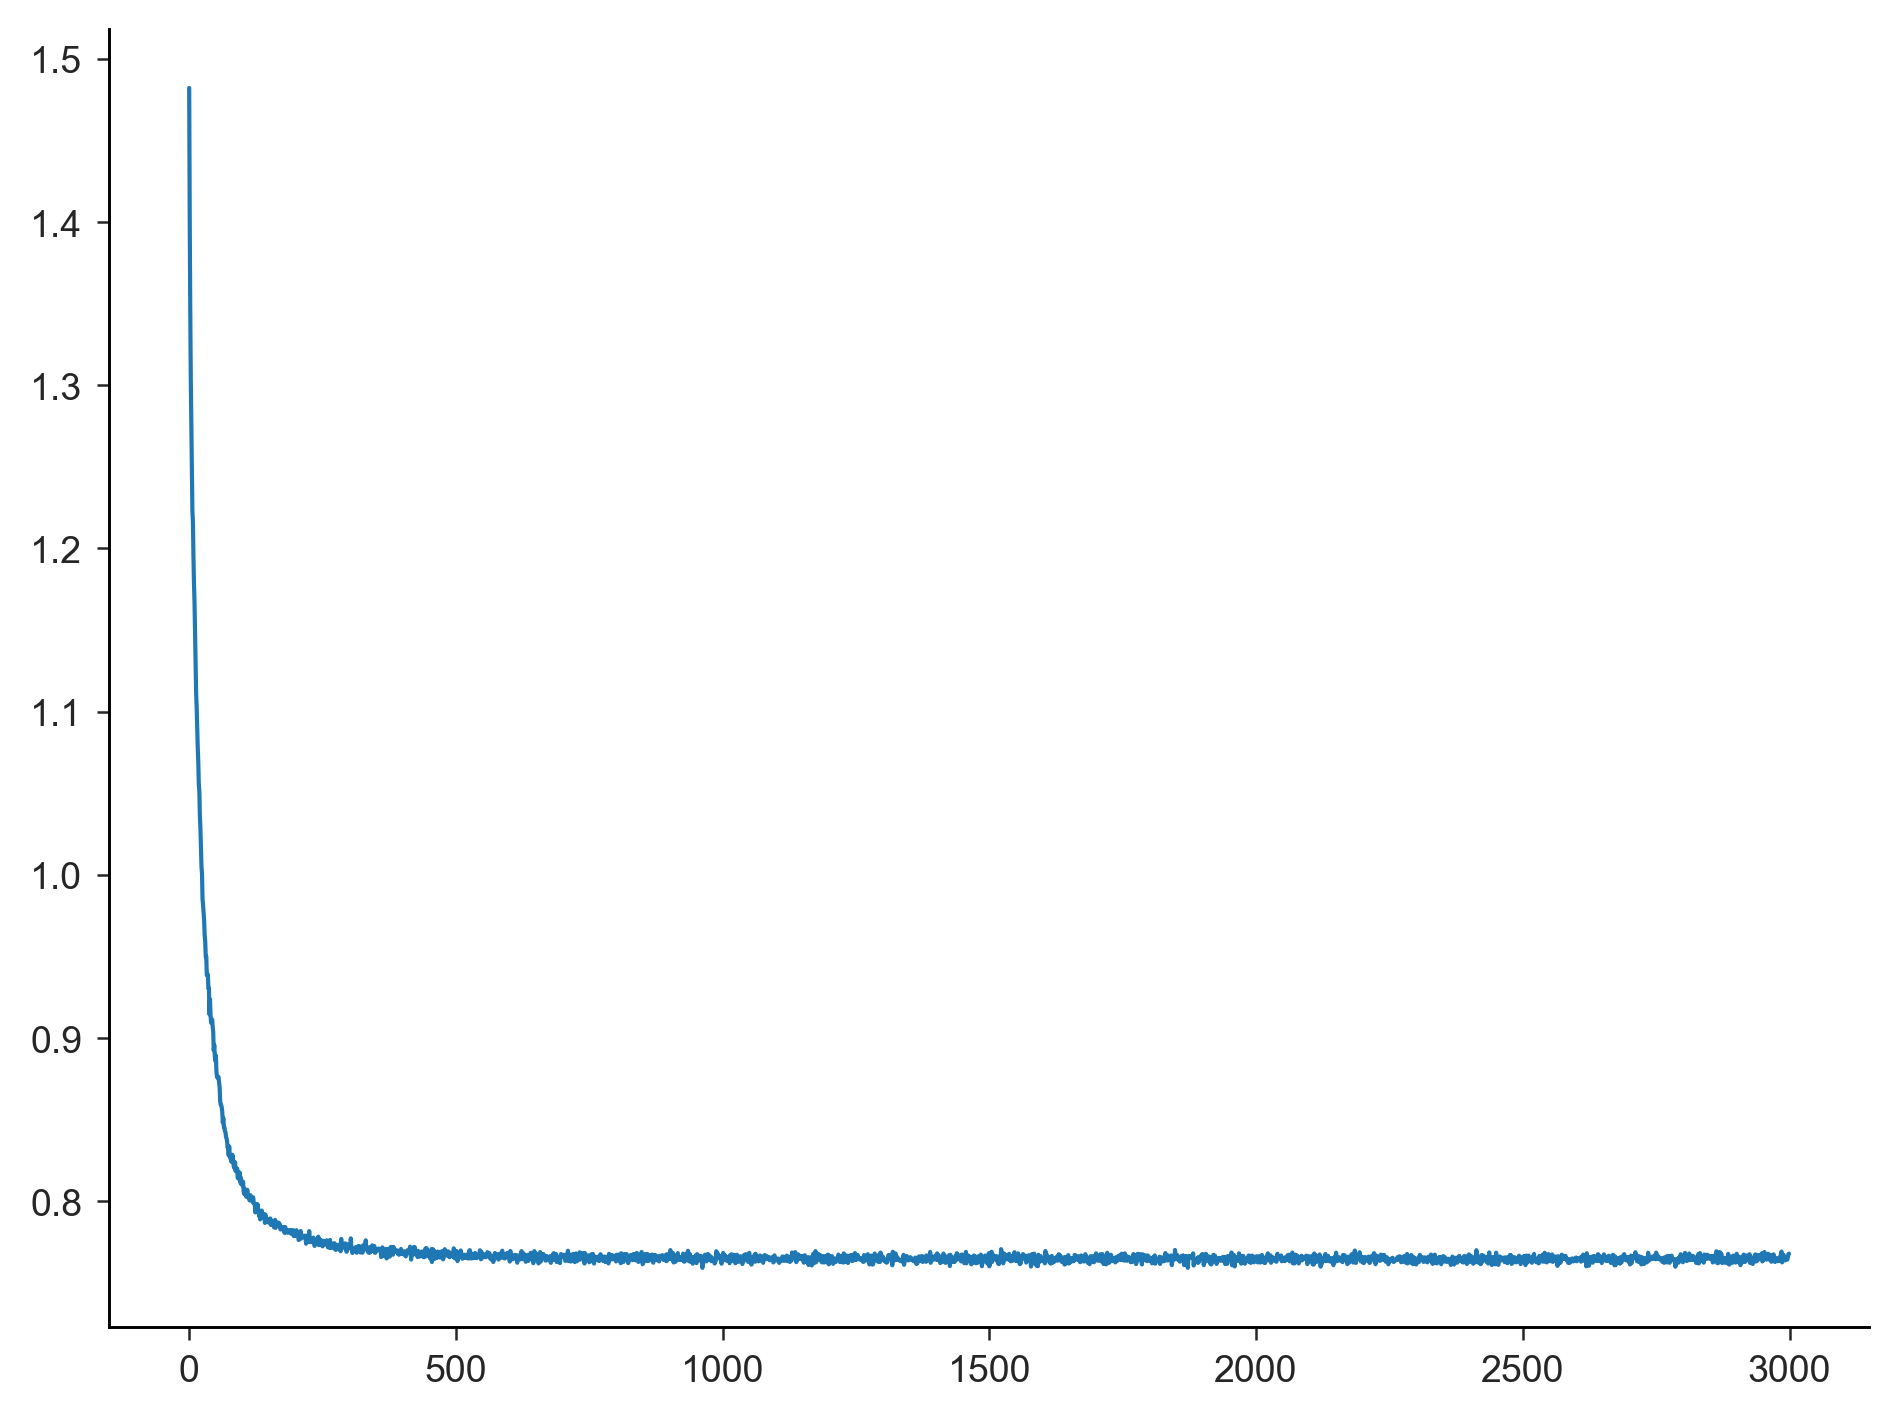

In [56]:
losses = svi_result.losses

plt.plot(np.array(losses))
print(np.mean(losses[2500:]))
print(final_loss)
plt.show()




In [57]:
params = extract_params(est_params, learn_mean=False, learn_alpha=learn_alpha)
alpha, untrunc_weights, untrunc_means, untrunc_covs = params["alpha"], params["weights"], params["means"], params[
    "covs"]
untrunc_means = np.zeros((num_states, x.shape[1]))
trunc_means, trunc_covs, trunc_weights, trunc_info = truncate(untrunc_means, untrunc_covs, untrunc_weights,
                                                              verbose=True, return_info=True, remove_edge_states=True)

print(final_loss)

[truncate]
  total components              : 3
  mass threshold                : 0.990

  Stage 1: mass truncation
    kept components             : 3
    kept original indices       : [0, 1, 2]
    retained weight mass        : 1.0000
    dropped weight mass         : 0.0000

  Stage 2: edge-state removal
    CV threshold                : 0.100
    removed components          : 0
    removed original indices    : []
    CVs in active set           : [0.0163, 0.0109, 0.0108]

  Final result
    final components kept       : 3
    final original indices      : [0, 1, 2]
    final retained weight mass  : 1.0000
    final dropped weight mass   : 0.0000
0.76460415


In [58]:
from jax.example_libraries import optimizers as jax_optim

lr_schedule = jax_optim.exponential_decay(
    step_size=1e-3,
    decay_steps=1000,
    decay_rate=0.95,
)

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


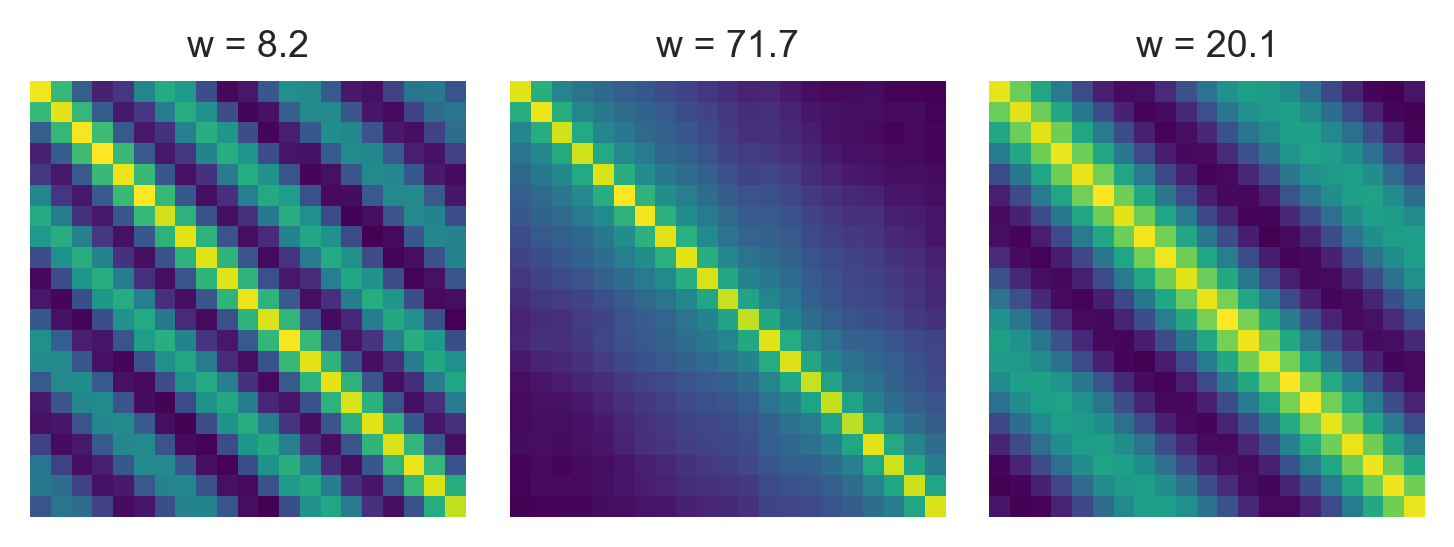

In [59]:
fig, ax = plt.subplots(1, trunc_covs.shape[0], figsize=(trunc_covs.shape[0] * 2, 2), gridspec_kw={"wspace": 0.1})
for i, cov in enumerate(trunc_covs):
    im = ax[i].imshow(cov, cmap="viridis")
    ax[i].set_axis_off()
    ax[i].set_title(f"w = {trunc_weights[i] * 100:.1f}", fontsize=9)

plt.show()

In [60]:
trunc_means, trunc_covs, trunc_weights, trunc_info = truncate(untrunc_means, untrunc_covs, untrunc_weights,
                                                              verbose=True, return_info=True, remove_edge_states=False)

est_states_with_edge = get_states(tde_data, trunc_means, trunc_covs, trunc_weights)
est_states_onehot_with_edge = np.eye(10)[est_states_with_edge]

true_states_onehot = np.eye(trimmed_states.max() + 1, dtype=np.float32)[trimmed_states]

order, reordered_est_states_onehot = match_states(
    true_states_onehot, est_states_onehot_with_edge, verbose=False
)
est_states_with_edge = np.argmax(reordered_est_states_onehot, axis=1)


[truncate]
  total components              : 3
  mass threshold                : 0.990

  Stage 1: mass truncation
    kept components             : 3
    kept original indices       : [0, 1, 2]
    retained weight mass        : 1.0000
    dropped weight mass         : 0.0000

  Final result
    final components kept       : 3
    final original indices      : [0, 1, 2]
    final retained weight mass  : 1.0000
    final dropped weight mass   : 0.0000


In [266]:
from tqdm.auto import tqdm
import numpy as np

import os

import jax
from jax import random
import jax.numpy as jnp
from jax.scipy.special import logsumexp
import numpyro
import numpyro.distributions as dist

import jax.scipy.stats as jss
from numpyro.infer.initialization import init_to_median, init_to_feasible


# see https://github.com/luiarthur/TuringBnpBenchmarks/blob/master/src/dp-gmm/notebooks//dp_sb_gmm_pyro.ipynb

@jax.jit
def stick_breaking(v):
    batch_ndims = len(v.shape) - 1
    cumprod_one_minus_v = jnp.exp(jnp.log1p(-v).cumsum(-1))
    one_v = jnp.pad(v, [[0, 0]] * batch_ndims + [[0, 1]], constant_values=1)
    c_one = jnp.pad(cumprod_one_minus_v, [[0, 0]] * batch_ndims + [[1, 0]],
                    constant_values=1)
    return one_v * c_one


def dpgmm_model(data, *, num_states, batch_size=None, alpha_prior=1.0, learn_alpha=True, learn_mean=True):
    num_data, num_dim = data.shape

    if learn_alpha:
        # hyper prior
        alpha = numpyro.sample("alpha", dist.HalfCauchy(1))

    else:
        alpha = numpyro.deterministic("alpha", jnp.array(alpha_prior))

    # stick-breaking
    with numpyro.plate("v_plates", num_states - 1):
        v = numpyro.sample("v", dist.Beta(1.0, alpha))

    weights = stick_breaking(v)

    numpyro.deterministic("weights", weights)

    # --------  component‑specific parameters  ----------------------------
    if learn_mean:
        # sample a separate mean for every component
        with numpyro.plate("components", num_states):
            mean = numpyro.sample(
                "mean",
                dist.MultivariateNormal(jnp.zeros(num_dim),
                                        jnp.eye(num_dim))
            )
            sigma = numpyro.sample("sigma",
                                   dist.HalfCauchy(jnp.ones(num_dim)).to_event(
                                       1))

            chol_corr = numpyro.sample("chol_corr",
                                       dist.LKJCholesky(num_dim, concentration=1))

            L_cov = chol_corr * sigma[..., None]

    else:
        # fixed zero mean for each component
        mean = numpyro.deterministic("mean", jnp.zeros((num_states, num_dim)))
        with numpyro.plate("components", num_states):
            sigma = numpyro.sample("sigma",
                                   dist.HalfCauchy(jnp.ones(num_dim)).to_event(1))

            chol_corr = numpyro.sample("chol_corr",
                                       dist.LKJCholesky(num_dim, concentration=1.0))
            L_cov = numpyro.deterministic("L_cov", chol_corr * sigma[..., None])

    if batch_size is None:
        batch_size = num_data  # use all the data point all the times

    # mixture assignment + likelihood
    with numpyro.plate("data", num_data, subsample_size=batch_size) as ind:
        batch_data = data[ind]
        mixture_dist = dist.MixtureSameFamily(dist.Categorical(probs=weights),
                                              dist.MultivariateNormal(mean, scale_tril=L_cov))
        numpyro.sample("obs", mixture_dist, obs=batch_data)


from numpyro.infer import SVI, TraceEnum_ELBO, Trace_ELBO, init_to_value
from numpyro.infer.autoguide import AutoDelta, AutoDiagonalNormal, AutoNormal
from jax import jit


from joblib import Parallel, delayed

def _fit_DPGMM(x,
               num_states,
               *,
               rng_key=None,
               seed=0,
               learn_mean=False,
               learn_alpha=True,
               num_epochs=3000,
               num_particles=1,
               batch_size=2 ** 9,
               alpha_prior=1.0,
               learning_rate=5e-2,
               use_epoch_tqdm=False
               ):
    x = jnp.array(x)
    guide = AutoNormal(dpgmm_model, init_loc_fn=init_to_feasible)

    # For numerical stability, normalize the scale by the total number of data points.
    scale_factor = 1.0 / float(x.size)
    scaled_model = numpyro.handlers.scale(dpgmm_model, scale=scale_factor)
    scaled_guide = numpyro.handlers.scale(guide, scale=scale_factor)

    optimizer = numpyro.optim.ClippedAdam(step_size=learning_rate,
                                          b1=0.95,
                                          b2=0.999,
                                          clip_norm=10, )

    elbo = Trace_ELBO(num_particles=num_particles, vectorize_particles=True)

    svi = SVI(scaled_model, scaled_guide, optimizer, loss=elbo)

    if rng_key is None:
        rng_key = random.PRNGKey(int(seed))

    svi_result = svi.run(rng_key, num_epochs, x, num_states=num_states, batch_size=batch_size, alpha_prior=alpha_prior,
                         learn_mean=learn_mean, learn_alpha=learn_alpha, progress_bar=use_epoch_tqdm)

    est_params = guide.median(svi_result.params)


    #compute ELBO estimate with 100 monte carlo samples
    elbo_eval = Trace_ELBO(num_particles = 100, vectorize_particles = True)


    final_loss = elbo_eval.loss(
        rng_key,
        svi_result.params,
        scaled_model,
        scaled_guide,
        x,
        num_states=num_states,
        batch_size=batch_size,
        alpha_prior=alpha_prior,
        learn_mean=learn_mean,
        learn_alpha=learn_alpha,)

    return est_params, np.array(svi_result.losses), final_loss

from tqdm_joblib import tqdm_joblib
def fit_DPGMM(
        *,
        data,
        num_states,
        learn_mean=False,
        learn_alpha=True,
        num_models=10,
        num_epochs=3000,
        num_particles= 10,
        batch_size=2**10,
        use_epoch_tqdm=False,
        use_model_tqdm=True,
        alpha_prior=1.0,
        learning_rate=5e-2,
        verbose=False,
        n_jobs=1,  # how many processes (-1 for all cores)
        main_seed=0,  # master seed for all runs
):
    x = np.array(data)

    # --- generate one integer seed per model run ---
    # Use numpy's SeedSequence for independent child seeds (robust & portable)
    ss = np.random.SeedSequence(int(main_seed))
    child_seeds = [s.generate_state(1, dtype=np.uint32)[0] for s in ss.spawn(num_models)]

    iterator = range(num_models)
    if use_model_tqdm and n_jobs == 1:
        iterator = tqdm(iterator, desc=f"Fitting {num_models} DPGMM models", unit="model", leave=False)

    loss_best = np.inf
    est_params_best = None
    best_model_id = None
    best_seed = None
    loss_all = []

    if n_jobs == 1:
        for i in iterator:
            params_i, losses_i, final_loss_i = _fit_DPGMM(
                x,
                num_states,
                rng_key=None,
                seed=int(child_seeds[i]),
                learn_mean=learn_mean,
                learn_alpha=learn_alpha,
                num_epochs=num_epochs,
                num_particles=num_particles,
                batch_size=batch_size,
                alpha_prior=alpha_prior,
                learning_rate=learning_rate,
                use_epoch_tqdm=use_epoch_tqdm,
            )
            loss_all.append(losses_i)
            run_best = final_loss_i

            if run_best < loss_best:
                loss_best = run_best
                est_params_best = params_i
                best_model_id = i
                best_seed = child_seeds[i]

    else:
        # ---- parallel with joblib ----
        indices = list(range(num_models))

        if use_model_tqdm:
            with tqdm_joblib(total=len(indices), desc=f"Fitting {num_models} DPGMM models"):
                results = Parallel(n_jobs=n_jobs)(
                    delayed(_fit_DPGMM)(
                        x,
                        num_states,
                        learn_mean=learn_mean,
                        learn_alpha=learn_alpha,
                        num_epochs=num_epochs,
                        num_particles=num_particles,
                        batch_size=batch_size,
                        alpha_prior=alpha_prior,
                        learning_rate=learning_rate,
                        use_epoch_tqdm=use_epoch_tqdm,
                        seed=int(child_seeds[i]),
                    )
                    for i in indices
                )

        else:
            if verbose:
                print("------running dpgmm-----")
            results = Parallel(n_jobs=n_jobs, return_as="generator")(
                delayed(_fit_DPGMM)(
                    x,
                    num_states,
                    learn_mean=learn_mean,
                    learn_alpha=learn_alpha,
                    num_epochs=num_epochs,
                    num_particles=num_particles,
                    batch_size=batch_size,
                    alpha_prior=alpha_prior,
                    learning_rate=learning_rate,
                    use_epoch_tqdm=use_epoch_tqdm,
                    seed=int(child_seeds[i]),
                )
                for i in indices
            )

        # collect in order
        results = list(results)
        for i, (params_i, losses_i, final_loss_i) in zip(indices, results):
            loss_all.append(losses_i)
            run_best = final_loss_i

            if run_best < loss_best:
                loss_best = run_best
                est_params_best = params_i
                best_model_id = i
                best_seed = child_seeds[i]

    if verbose:
        print(f"Best negative ELBO: {loss_best:.6g}")
        if best_model_id is not None:
            print(f"Best model ID: {best_model_id}")

    params = extract_params(est_params_best, learn_mean=learn_mean, learn_alpha=learn_alpha)
    alpha, weights, means, covs = params["alpha"], params["weights"], params["means"], params["covs"]

    if alpha is None:
        alpha = float(alpha_prior)
    if means is None:
        means = np.zeros((num_states, x.shape[1]))

    return {
        "est_params": {
            "alpha": alpha,
            "weights": weights,
            "means": means,
            "covs": covs,
        },
        "loss_best": loss_best,
        "model_id_best": best_model_id,
        "seed_best": int(best_seed) if best_seed is not None else None,
        "loss_all": loss_all,
    }


def extract_params(est_params, learn_mean=True, learn_alpha=True):
    # alpha
    alpha = None
    if learn_alpha:
        alpha = est_params["alpha"]

    # stick-breaking weights
    v = est_params["v"]
    weights = stick_breaking(v)

    # covariances
    chol_corr = est_params["chol_corr"]
    sigma = est_params["sigma"]
    L_covs = [jnp.diag(sig) @ L for sig, L in zip(sigma, chol_corr)]
    covs = jnp.array([L @ L.T for L in L_covs])

    means = None
    if learn_mean:
        means = est_params["mean"]

    return {
        "alpha": alpha,
        "weights": weights,
        "means": means,
        "covs": covs,
    }


import jax.numpy as jnp
import jax.numpy as jnp


def truncate(
    means,
    covs,
    weights,
    mass_threshold=0.99,
    remove_edge_states=False,
    edge_states_cv=0.1,
    verbose=False,
    return_info=False,
):
    """
    Truncate mixture components in two stages:

    1. Keep the smallest set of components whose cumulative weight mass
       reaches `mass_threshold`.
    2. Optionally remove "edge states" among those retained components,
       where edge states are defined by a diagonal covariance CV above
       `edge_states_cv`.

    Parameters
    ----------
    means : array, shape (K, ...)
    covs : array, shape (K, D, D)
    weights : array, shape (K,)
    mass_threshold : float
        Cumulative mass threshold for initial truncation.
    remove_edge_states : bool
        Whether to remove edge states after mass truncation.
    edge_states_cv : float
        Threshold on coefficient of variation of covariance diagonals.
    verbose : bool
        Whether to print a readable summary.
    return_info : bool
        Whether to return a summary string in addition to truncated params.

    Returns
    -------
    trunc_means, trunc_covs, trunc_weights
        Truncated parameters after renormalization.
    info : str, optional
        Human-readable summary if `return_info=True`.
    """
    means = jnp.asarray(means)
    covs = jnp.asarray(covs)
    w = jnp.asarray(weights)

    K = w.shape[0]

    # ----------------------------
    # (0) Basic validation
    # ----------------------------
    if means.shape[0] != K or covs.shape[0] != K:
        raise ValueError("means, covs, and weights must agree on the first dimension K.")

    if not (0.0 < mass_threshold <= 1.0):
        raise ValueError("mass_threshold must be in (0, 1].")

    if edge_states_cv < 0:
        raise ValueError("edge_states_cv must be nonnegative.")

    # ----------------------------
    # (1) Mass truncation
    # ----------------------------
    sort_idx = jnp.argsort(w)[::-1]
    w_sorted = w[sort_idx]
    cdf = jnp.cumsum(w_sorted)

    reached = cdf >= mass_threshold
    k0 = int(jnp.where(jnp.any(reached), jnp.argmax(reached) + 1, K))

    active_sorted_idx = sort_idx[:k0]
    active_idx = jnp.sort(active_sorted_idx)  # original component indices

    # diagnostics for stage 1
    mass_kept_stage1 = float(jnp.sum(w[active_idx]))
    mass_dropped_stage1 = float(1.0 - mass_kept_stage1)

    # ----------------------------
    # (2) Optional edge-state removal
    # ----------------------------
    final_idx = active_idx
    removed_edge_idx = jnp.array([], dtype=active_idx.dtype)
    kept_cv = None
    removed_cv = None
    cv_diags = None

    if remove_edge_states and active_idx.shape[0] > 0:
        trunc_covs_stage1 = covs[active_idx]  # (k0, D, D)
        diag = jnp.diagonal(trunc_covs_stage1, axis1=-2, axis2=-1)  # (k0, D)

        mu = jnp.mean(diag, axis=-1)
        sd = jnp.std(diag, axis=-1)
        cv_diags = sd / (mu + 1e-12)

        keep_mask = cv_diags <= edge_states_cv
        removed_edge_idx = active_idx[~keep_mask]   # original component indices

        # keep at least one state
        if not bool(jnp.any(keep_mask)):
            best_idx_within_active = jnp.argmin(cv_diags)
            keep_mask = jnp.zeros_like(keep_mask, dtype=bool).at[best_idx_within_active].set(True)
            removed_edge_idx = active_idx[~keep_mask]

        final_idx = active_idx[keep_mask]
        kept_cv = cv_diags[keep_mask]
        removed_cv = cv_diags[~keep_mask]

    # ----------------------------
    # (3) Final truncated params
    # ----------------------------
    trunc_means = means[final_idx]
    trunc_covs = covs[final_idx]

    mass_kept_final = jnp.sum(w[final_idx])
    trunc_weights = w[final_idx] / (mass_kept_final + 1e-12)

    # ----------------------------
    # (4) output log
    # ----------------------------
    info = None
    if return_info or verbose:
        k_mass = int(active_idx.shape[0])
        k_final = int(final_idx.shape[0])
        n_edge_removed = int(removed_edge_idx.shape[0])

        kept_mass_final = float(mass_kept_final)
        dropped_mass_final = float(1.0 - kept_mass_final)

        lines = [
            "[truncate]",
            f"  total components              : {K}",
            f"  mass threshold                : {float(mass_threshold):.3f}",
            "",
            "  Stage 1: mass truncation",
            f"    kept components             : {k_mass}",
            f"    kept original indices       : {list(map(int, active_idx.tolist()))}",
            f"    retained weight mass        : {mass_kept_stage1:.4f}",
            f"    dropped weight mass         : {mass_dropped_stage1:.4f}",
        ]

        if remove_edge_states:
            lines += [
                "",
                "  Stage 2: edge-state removal",
                f"    CV threshold                : {float(edge_states_cv):.3f}",
                f"    removed components          : {n_edge_removed}",
                f"    removed original indices    : {list(map(int, removed_edge_idx.tolist()))}",
            ]

            if cv_diags is not None:
                lines.append(
                    f"    CVs in active set           : {[round(float(x), 4) for x in cv_diags.tolist()]}"
                )

        lines += [
            "",
            "  Final result",
            f"    final components kept       : {k_final}",
            f"    final original indices      : {list(map(int, final_idx.tolist()))}",
            f"    final retained weight mass  : {kept_mass_final:.4f}",
            f"    final dropped weight mass   : {dropped_mass_final:.4f}",
        ]

        info = "\n".join(lines)

        if verbose:
            print(info)

    if return_info:
        return trunc_means, trunc_covs, trunc_weights, info

    return trunc_means, trunc_covs, trunc_weights


def mvn_log_likelihood(x, means, covs):
    # Computes the logpdf of a multivariate normal for each observation given a set of covariance matrices.
    def _mvn_logpdf(x, mean, cov):
        return jss.multivariate_normal.logpdf(x, mean, cov)

    # Vectorize over states for a fixed observation.
    _log_pdf_over_state = jax.vmap(_mvn_logpdf, in_axes=(None, 0, 0))

    # Vectorize over time (observations).
    log_likelihood = jax.vmap(_log_pdf_over_state, in_axes=(0, None, None))
    return log_likelihood(x, means, covs)


def get_state_probs(x, means, covs, weights):
    log_likelihoods = mvn_log_likelihood(x, means, covs)
    log_weights = jnp.log(jnp.clip(weights, 1e-12, 1.0))

    log_joint =  log_weights + log_likelihoods
    log_normalizer = logsumexp(log_joint, axis=-1, keepdims=True)
    probs = jnp.exp(log_joint - log_normalizer)

    return probs


def get_states(x, means, covs, weights):
    log_likelihoods = mvn_log_likelihood(x, means, covs)
    log_joint = jnp.log(jnp.array(weights)) + log_likelihoods
    states = jnp.argmax(log_joint, axis=-1)
    return states




In [267]:
from nds_toolbox.preprocessing.features import choose_embedding_dim
from nds_toolbox.preprocessing.features import (compute_tde, trim_data)
#from nds_toolbox.models.dpgmm_numpyro import fit_DPGMM, truncate, get_states
#from nds_toolbox.models.dpgmm_numpyro import fit_DPGMM, get_states

from nds_toolbox.analysis.burst_analysis import summarize_states
from nds_toolbox.analysis.utils import imputing_mode


def run_dpgmm_pipeline(*, data, fs,
                       num_emb,
                       num_states,
                       min_samples,
                       seed,
                       use_model_tqdm=True,
                       verbose=True):
    #Time-delay embedding
    tde_data = compute_tde(data, num_emb)
    trimmed_signal = trim_data(data, num_embeddings=num_emb, verbose=False)
    trimmed_time_vec = np.arange(len(trimmed_signal)) / fs

    #DP-GMM
    dpgmm_result = fit_DPGMM(data=tde_data,
                             num_states=num_states,
                             use_epoch_tqdm=False,
                             n_jobs=10,
                             use_model_tqdm=use_model_tqdm,
                             learning_rate=5e-2,
                             batch_size=2 ** 10,
                             num_models=10,
                             num_particles=10,
                             learn_alpha=True,
                             alpha_prior=0.5,
                             num_epochs=3000,
                             main_seed=seed,
                             verbose=verbose)

    est_params, loss_best, model_id_best, key_best, losses_all = dpgmm_result.values()

    alpha = est_params["alpha"]
    means = est_params["means"]
    covs = est_params["covs"]
    weights = est_params["weights"]

    order = np.argsort(-weights)
    weights = weights[order]
    means = means[order]
    covs = covs[order]

    est_params["weights"] = weights
    est_params["means"] = means
    est_params["covs"] = covs

    trunc_means, trunc_covs, trunc_weights, trunc_info = truncate(means, covs, weights, verbose=True, return_info=True, remove_edge_states=True)

    #the estimated states with truncated params
    est_states = get_states(tde_data, trunc_means, trunc_covs, trunc_weights)

    num_active_states = int(len(trunc_weights))  # after truncation

    #knn imputation
    imputed_est_states = imputing_mode(est_states, min_samples=min_samples)

    est_params = {
        "alpha": alpha,
        "weights": trunc_weights,
        "means": trunc_means,
        "covs": trunc_covs,
        "untrunc_means": means,
        "untrunc_covs": covs,
        "untrunc_weights": weights,
        "trunc_info": trunc_info, }

    return {
        "tde_data": tde_data,
        "trimmed_signal": trimmed_signal,
        "trimmed_time_vec": trimmed_time_vec,
        "num_active_states": num_active_states,
        "est_params": est_params,
        "est_states": est_states,
        "imputed_est_states": imputed_est_states,
        "loss_best": loss_best,
        "model_id_best": model_id_best,
        "key_best": key_best,
        "losses_all": losses_all,
    }









# test

In [268]:
signal = (signal - np.mean(signal)) / np.std(signal)  #standarize
num_emb = choose_embedding_dim(np.mean(freq), fs, min_cycles=2.5, ensure_odd=True)
tde_signal = compute_tde(signal, num_emb)

trimmed_signal = trim_data(signal, num_emb, verbose=False)
trimmed_states = trim_data(states, num_emb, verbose=False)
trimmed_time_vec = np.linspace(0, len(trimmed_states) / fs, len(trimmed_states))



Chosen window size = 0.083 (sec): minimum cycles of 2.5 at 30.0 Hz
Chosen embedding dimension = 21: sampling rate = 250 Hz
10 data points were lost from both ends.
data shape: (44980, 21)


In [269]:
#tukey alpha = 0.2
#prior = gamma
#initializatin ? kmeans for example
#

num_states = int(np.ceil(np.log(len(signal))))
print(num_states)

min_samples = np.round((2 / np.max(freq)) * fs).astype(int)
signal = (signal - np.mean(signal)) / np.std(signal)  #standarize the signal

res = run_dpgmm_pipeline(data=signal,
                         fs=fs,
                         num_emb=num_emb,
                         num_states=num_states,
                         min_samples=min_samples,
                         seed=seed)

#halfcauchy(1) 0.69992
#halfcauchy(0.5)0.69992

11
10 data points were lost from both ends.
data shape: (44980, 21)


Fitting 10 DPGMM models:   0%|          | 0/10 [00:00<?, ?it/s]

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


Best negative ELBO: 0.765323
Best model ID: 2
[truncate]
  total components              : 11
  mass threshold                : 0.990

  Stage 1: mass truncation
    kept components             : 3
    kept original indices       : [0, 1, 2]
    retained weight mass        : 0.9994
    dropped weight mass         : 0.0006

  Stage 2: edge-state removal
    CV threshold                : 0.100
    removed components          : 0
    removed original indices    : []
    CVs in active set           : [0.0166, 0.031, 0.0397]

  Final result
    final components kept       : 3
    final original indices      : [0, 1, 2]
    final retained weight mass  : 0.9994
    final dropped weight mass   : 0.0006


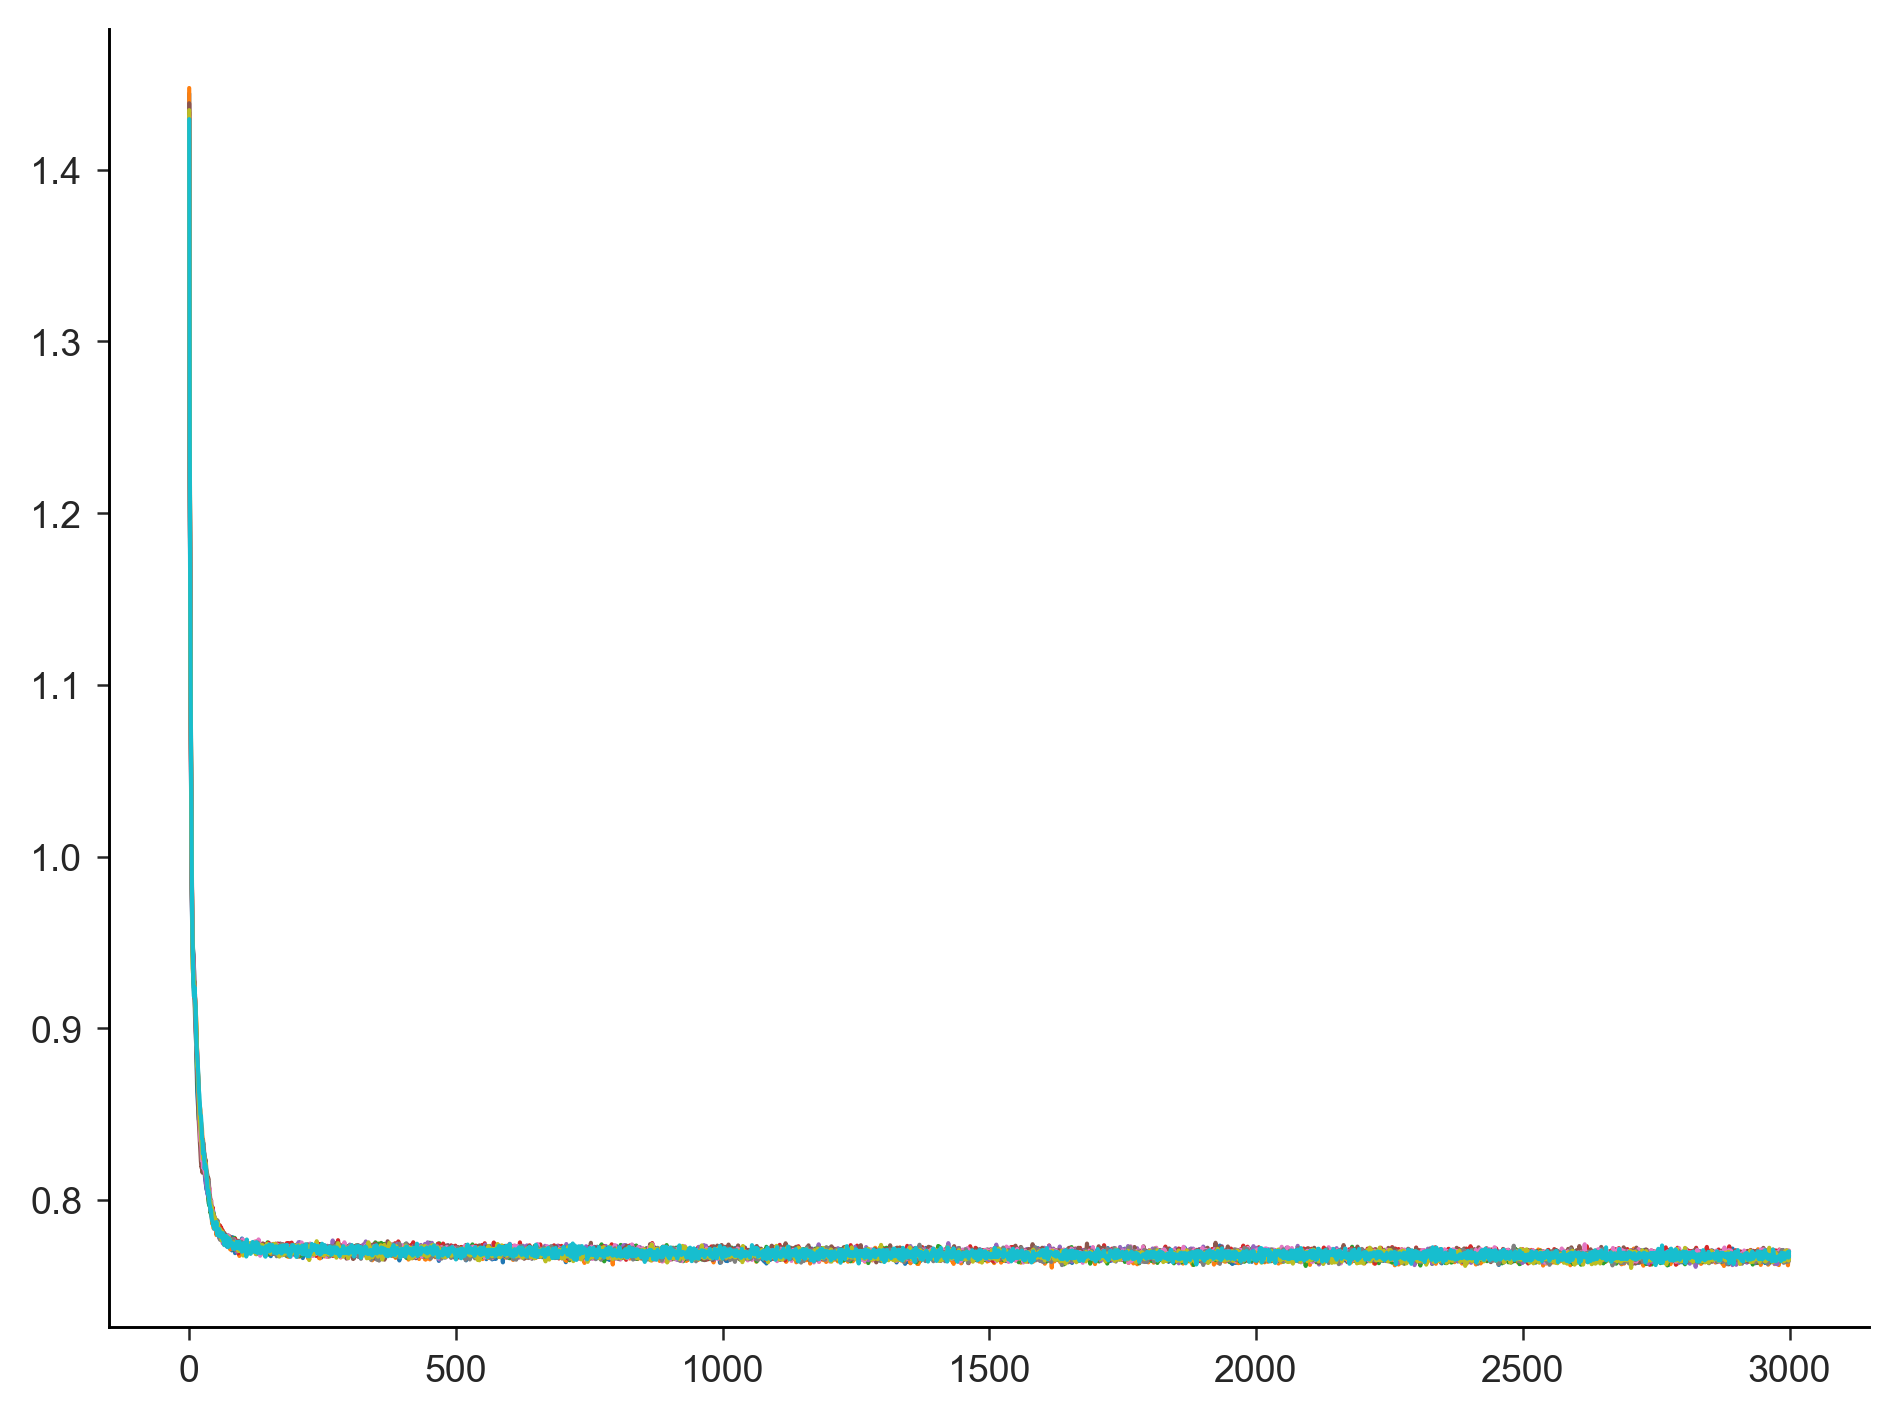

In [270]:
losses = np.array(res["losses_all"])
plt.plot(losses.T)

In [271]:
tde_data = res["tde_data"]
trimmed_signal = res["trimmed_signal"]
trimmed_time_vec = res["trimmed_time_vec"]
num_active_states = res["num_active_states"]
est_params = res["est_params"]
weights = est_params["weights"]
means = est_params["means"]
covs = est_params["covs"]

alpha = est_params["alpha"]
untrunc_weights = est_params["untrunc_weights"]
untrunc_means = est_params["untrunc_means"]
untrunc_covs = est_params["untrunc_covs"]
est_states = res["est_states"]
est_states_onehot = np.eye(num_active_states)[est_states]

est_states_imputed = res["imputed_est_states"]
est_states_imputed_onehot = np.eye(num_active_states)[est_states_imputed]

#summary stats
summary_stats = summarize_states(trimmed_signal, est_states_imputed, fs, num_states=num_active_states)

fo = summary_stats["fractional_occupancies"]
lifetimes = summary_stats["lifetimes"]
median_lifetimes = summary_stats["median_lt_states"]
CV_intervals = summary_stats["CV_intervals"]
burst_rates = summary_stats["burst_rates"]
powers = summary_stats["powers"]
spectra = summary_stats["spectra"]
f_vec, psd_vec = summary_stats["spectra"]


In [272]:
from nds_toolbox.utils.helper import match_states

trunc_means, trunc_covs, trunc_weights, trunc_info = truncate(untrunc_means, untrunc_covs, untrunc_weights,
                                                              verbose=True, return_info=True, remove_edge_states=False)

est_states_with_edge = get_states(tde_data, trunc_means, trunc_covs, trunc_weights)
est_states_onehot_with_edge = np.eye(10)[est_states_with_edge]

true_states_onehot = np.eye(trimmed_states.max() + 1, dtype=np.float32)[trimmed_states]

order, reordered_est_states_onehot = match_states(
    true_states_onehot, est_states_onehot_with_edge, verbose=False
)
est_states_with_edge = np.argmax(reordered_est_states_onehot, axis=1)


[truncate]
  total components              : 11
  mass threshold                : 0.990

  Stage 1: mass truncation
    kept components             : 3
    kept original indices       : [0, 1, 2]
    retained weight mass        : 0.9994
    dropped weight mass         : 0.0006

  Final result
    final components kept       : 3
    final original indices      : [0, 1, 2]
    final retained weight mass  : 0.9994
    final dropped weight mass   : 0.0006


In [273]:
try:
    median_lifetimes
except NameError as e:
    print(f'Skipped cell (missing name): {e}')


In [274]:
try:
    print("alpha", alpha)
except NameError as e:
    print(f'Skipped cell (missing name): {e}')


alpha 0.6313759


In [275]:
true_states_onehot = np.eye(trimmed_states.max() + 1, dtype=np.float32)[trimmed_states]
true_states_onehot.shape

(44980, 3)

In [276]:
from nds_toolbox.preprocessing.features import compute_wavelet


In [277]:
order

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [278]:
from sklearn.metrics import matthews_corrcoef

true_states_onehot = np.eye(trimmed_states.max() + 1, dtype=np.float32)[trimmed_states]

order, reordered_est_states_onehot = match_states(
    true_states_onehot, est_states_onehot, verbose=False
)
est_states = np.argmax(reordered_est_states_onehot, axis=1)

mcc = matthews_corrcoef(trimmed_states, est_states)

order, reordered_est_states_imputed_onehot = match_states(
    true_states_onehot, est_states_imputed_onehot, verbose=False
)
est_states_imputed = np.argmax(reordered_est_states_imputed_onehot, axis=1)

mcc_imputed = matthews_corrcoef(trimmed_states, est_states_imputed)

print("MCC:", mcc)
print("MCC (imputed)", mcc_imputed)



MCC: 0.8061757975140222
MCC (imputed) 0.881115617673358


In [279]:
trunc_means, trunc_covs, trunc_weights, trunc_info = truncate(untrunc_means, untrunc_covs, untrunc_weights,
                                                              verbose=True, return_info=True, remove_edge_states=True)

est_states_with_edge = get_states(tde_data, trunc_means, trunc_covs, trunc_weights)
est_states_onehot_with_edge = np.eye(10)[est_states_with_edge]

true_states_onehot = np.eye(trimmed_states.max() + 1, dtype=np.float32)[trimmed_states]

order, reordered_est_states_onehot = match_states(
    true_states_onehot, est_states_onehot_with_edge, verbose=False
)
est_states_with_edge = np.argmax(reordered_est_states_onehot, axis=1)


[truncate]
  total components              : 11
  mass threshold                : 0.990

  Stage 1: mass truncation
    kept components             : 3
    kept original indices       : [0, 1, 2]
    retained weight mass        : 0.9994
    dropped weight mass         : 0.0006

  Stage 2: edge-state removal
    CV threshold                : 0.100
    removed components          : 0
    removed original indices    : []
    CVs in active set           : [0.0166, 0.031, 0.0397]

  Final result
    final components kept       : 3
    final original indices      : [0, 1, 2]
    final retained weight mass  : 0.9994
    final dropped weight mass   : 0.0006


In [280]:



def plot_summary_fig(res):
    # --- inputs ---
    tde_data = res["tde_data"]
    trimmed_signal = res["trimmed_signal"]
    trimmed_time_vec = res["trimmed_time_vec"]
    num_active_states = res["num_active_states"]
    est_params = res["est_params"]

    weights = np.array(est_params["weights"])
    means = est_params["means"]
    covs = np.array(est_params["covs"])

    untrunc_weights = np.array(est_params["untrunc_weights"])
    untrunc_means = est_params["untrunc_means"]
    untrunc_covs = np.array(est_params["untrunc_covs"])

    est_states = res["est_states"]
    est_states_imputed = res["imputed_est_states"]

    # expected from res or globals
    trimmed_states = res.get("trimmed_states", globals().get("trimmed_states"))
    fs = res.get("fs", globals().get("fs"))

    if trimmed_states is None:
        raise KeyError("trimmed_states must be provided in res or as a global variable.")
    if fs is None:
        raise KeyError("fs must be provided in res or as a global variable.")

    n_plot_states = untrunc_covs.shape[0]

    # --- helpers ---
    def onehot(x, n_classes):
        return np.eye(n_classes, dtype=np.float32)[x]

    def reorder_states(true_onehot, pred_onehot):
        order, reordered = match_states(true_onehot, pred_onehot, verbose=False)
        return np.argmax(reordered, axis=1), reordered, order

    # --- one-hot states ---
    true_states_onehot = onehot(trimmed_states, trimmed_states.max() + 1)
    est_states_onehot = onehot(est_states, num_active_states)
    est_states_imputed_onehot = onehot(est_states_imputed, num_active_states)

    est_states, reordered_est_states_onehot, order = reorder_states(true_states_onehot, est_states_onehot)
    est_states_onehot = onehot(est_states, num_active_states)

    est_states_imputed, reordered_est_states_imputed_onehot, order = reorder_states(
        true_states_onehot, est_states_imputed_onehot
    )
    est_states_imputed_onehot = onehot(est_states_imputed, num_active_states)

    # --- version with edge states kept ---
    trunc_means, trunc_covs, trunc_weights, trunc_info = truncate(
        untrunc_means,
        untrunc_covs,
        untrunc_weights,
        verbose=True,
        return_info=True,
        remove_edge_states=False,
    )

    est_states_with_edge = get_states(tde_data, trunc_means, trunc_covs, trunc_weights)
    est_states_onehot_with_edge = onehot(est_states_with_edge, len(trunc_means))

    est_states_with_edge, reordered_est_states_onehot, _ = reorder_states(
        true_states_onehot, est_states_onehot_with_edge
    )
    est_states_onehot_with_edge = onehot(est_states_with_edge, len(trunc_means))

    untrunc_covs[:len(order)] = untrunc_covs[:len(order)][order]
    #untrunc_weights = untrunc_weights[order]
    weights = weights[order]
    covs = covs[order]

    # --- summary stats ---
    summary_stats = summarize_states(trimmed_signal, est_states, fs, num_states=num_active_states)
    fo = summary_stats["fractional_occupancies"]
    lifetimes = summary_stats["lifetimes"]
    median_lifetimes = summary_stats["median_lt_states"]
    CV_intervals = summary_stats["CV_intervals"]
    burst_rates = summary_stats["burst_rates"]
    powers = summary_stats["powers"]
    f_vec, psd_vec = summary_stats["spectra"]
    psd_vec = np.array(psd_vec)[order]

    # --- style ---
    cmap = plt.get_cmap("tab10")
    colors = ["#BDBDBD"] + [cmap(i) for i in range(n_plot_states)]
    state_labels = [f"S{i + 1}" for i in range(n_plot_states)]

    start_t = 0
    plot_t = 20

    # --- wavelet ---
    t, f, amp = compute_wavelet(
        trimmed_signal[start_t * fs: plot_t * fs],
        fs,
        f_min=1,
        f_max=80,
        df=0.5,
        wavelet="cmor1.5-1.0",
    )
    t += start_t

    # --- layout ---
    mosaic = [
        ["a1", "a1"],
        ["a2", "a2"],
        ["a3", "a3"],
        ["a4", "a4"],
        ["a5", "a5"],
        ["a6", "a6"],
        ["gap", "gap"],
        ["b", "c"],
        ["d", "c"],
    ]

    fig, axes = plt.subplot_mosaic(
        mosaic,
        figsize=(FIG_WIDTH, 5.8),
        constrained_layout=True,
        gridspec_kw={
            "height_ratios": [0.4, 0.6, 0.4, 0.4, 0.4, 0.4, 0.1, 1.0, 0.1],
            "width_ratios": [0.6, 0.4],
        },
    )
    fig.set_constrained_layout_pads(w_pad=0.0, h_pad=0.0, hspace=0.01)
    axes["gap"].set_visible(False)

    idx = slice(start_t * fs, plot_t * fs)
    t_plot = trimmed_time_vec[idx]

    # --- a1: raw signal ---
    ax = axes["a1"]
    ax.plot(t_plot, trimmed_signal[idx], lw=0.2, color="k")
    axes["a1"].sharex(axes["a3"])

    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_frame_on(False)
    for s in ("top", "right", "bottom", "left"):
        ax.spines[s].set_visible(False)
    ax.tick_params(axis="both", which="both",
                   bottom=False, top=False, left=False, right=False,
                   labelbottom=False, labelleft=False)

    # --- a2: wavelet ---
    im = axes["a2"].imshow(
        amp,
        extent=[t[0], t[-1], f[0], f[-1]],
        origin="lower",
        aspect="auto",
        cmap="viridis",
        vmin=amp.min(),
        vmax=amp.max(),
    )
    axes["a2"].set_ylabel("Freq.")
    axes["a2"].set_ylim(1, 40)
    axes["a2"].yaxis.set_major_locator(MultipleLocator(10))
    axes["a2"].tick_params(axis="x", which="both", bottom=False, labelbottom=False)

    cax = inset_axes(
        axes["a2"],
        width="2%",
        height="100%",
        loc="center right",
        borderpad=-1.3,
    )
    cb = fig.colorbar(im, cax=cax)
    cb.set_label("Amp.", rotation=270, labelpad=12)
    cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)

    # --- state panels ---
    panel_data = [
        ("a3", true_states_onehot, "True states", 40),
        ("a4", est_states_onehot_with_edge, "DP-GMM", 40),
        ("a5", est_states_onehot, "DP-GMM\n (edge-removed)", 50),
        ("a6", est_states_imputed_onehot, "DP-GMM\n (edge-removed + imputed)", 50),
    ]

    for key, state_mat, ylabel, pad in panel_data:
        axes[key].stackplot(
            t_plot,
            state_mat[idx].T,
            linewidth=0,
            colors=colors,
            labels=state_labels,
        )
        axes[key].set_ylabel(ylabel, rotation=0, labelpad=pad, va="center")
        axes[key].set_ylim(0, 1)
        axes[key].set_xlim(start_t, plot_t)
        axes[key].tick_params(axis="y", which="both", left=False, labelleft=False)

    for key in ["a1", "a2", "a3", "a4", "a5"]:
        axes[key].tick_params(axis="x", which="both", bottom=False, labelbottom=False)

    axes["a6"].xaxis.set_major_locator(MultipleLocator(1.0))
    axes["a6"].set_xlabel("Time (s)")
    axes["a6"].spines["bottom"].set_visible(True)

    # --- legend ---
    handles, labels = axes["a4"].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(0.99, 0.62),
        frameon=False,
        handlelength=1,
        handleheight=0.5,
        labelspacing=0.0,
        ncol=1,
        columnspacing=0.2,
    )

    # --- b: mixture weights ---
    for k, w in enumerate(untrunc_weights):
        axes["b"].bar(
            k,
            w,
            width=0.7,
            color=colors[k],
            zorder=1,
            align="center",
            edgecolor="k",
        )
        axes["b"].text(
            k,
            w + 0.02,
            f"{w * 100:.1f}%",
            ha="center",
            color="k",
            fontsize=MY_FONT_SIZE - 3,
        )

    axes["b"].set_ylabel("Mixture weights")
    axes["b"].set_xticks(np.arange(n_plot_states), labels=np.arange(1, n_plot_states + 1))
    axes["b"].tick_params(axis="y")

    # --- c: PSDs ---
    for i in range(num_active_states):
        axes["c"].plot(f_vec[i], psd_vec[i], color=colors[i], lw=0.8, alpha=1)

    axes["c"].set_xlim(0, 50)
    axes["c"].set_xlabel("Frequency (Hz)")
    axes["c"].set_ylabel("PSD (a.u.)")

    # --- d: empty alignment panel ---
    axes["d"].set_xticks([])
    axes["d"].set_yticks([])
    for spine in axes["d"].spines.values():
        spine.set_visible(False)
    axes["d"].set_xlabel("State id")

    fig.align_xlabels([axes["c"], axes["d"]])
    fig.align_ylabels([axes["a3"], axes["a4"]])
    fig.canvas.draw()
    plt.show()

    # --- covariance matrices ---
    fig, ax = plt.subplots(
        1,
        untrunc_covs.shape[0],
        figsize=(untrunc_covs.shape[0] * 2, 2),
        gridspec_kw={"wspace": 0.1},
    )

    for i, cov in enumerate(untrunc_covs):
        ax[i].imshow(cov, cmap="viridis")
        ax[i].set_axis_off()

    plt.show()

    true_states = np.argmax(true_states_onehot, axis=1)
    est_states_with_edge = np.argmax(est_states_onehot_with_edge, axis=1)
    est_states_without_edge = np.argmax(est_states_onehot, axis=1)
    est_states_imputed = np.argmax(est_states_imputed_onehot, axis=1)

    return true_states, est_states_with_edge, est_states_without_edge, est_states_imputed


[truncate]
  total components              : 11
  mass threshold                : 0.990

  Stage 1: mass truncation
    kept components             : 3
    kept original indices       : [0, 1, 2]
    retained weight mass        : 0.9994
    dropped weight mass         : 0.0006

  Final result
    final components kept       : 3
    final original indices      : [0, 1, 2]
    final retained weight mass  : 0.9994
    final dropped weight mass   : 0.0006


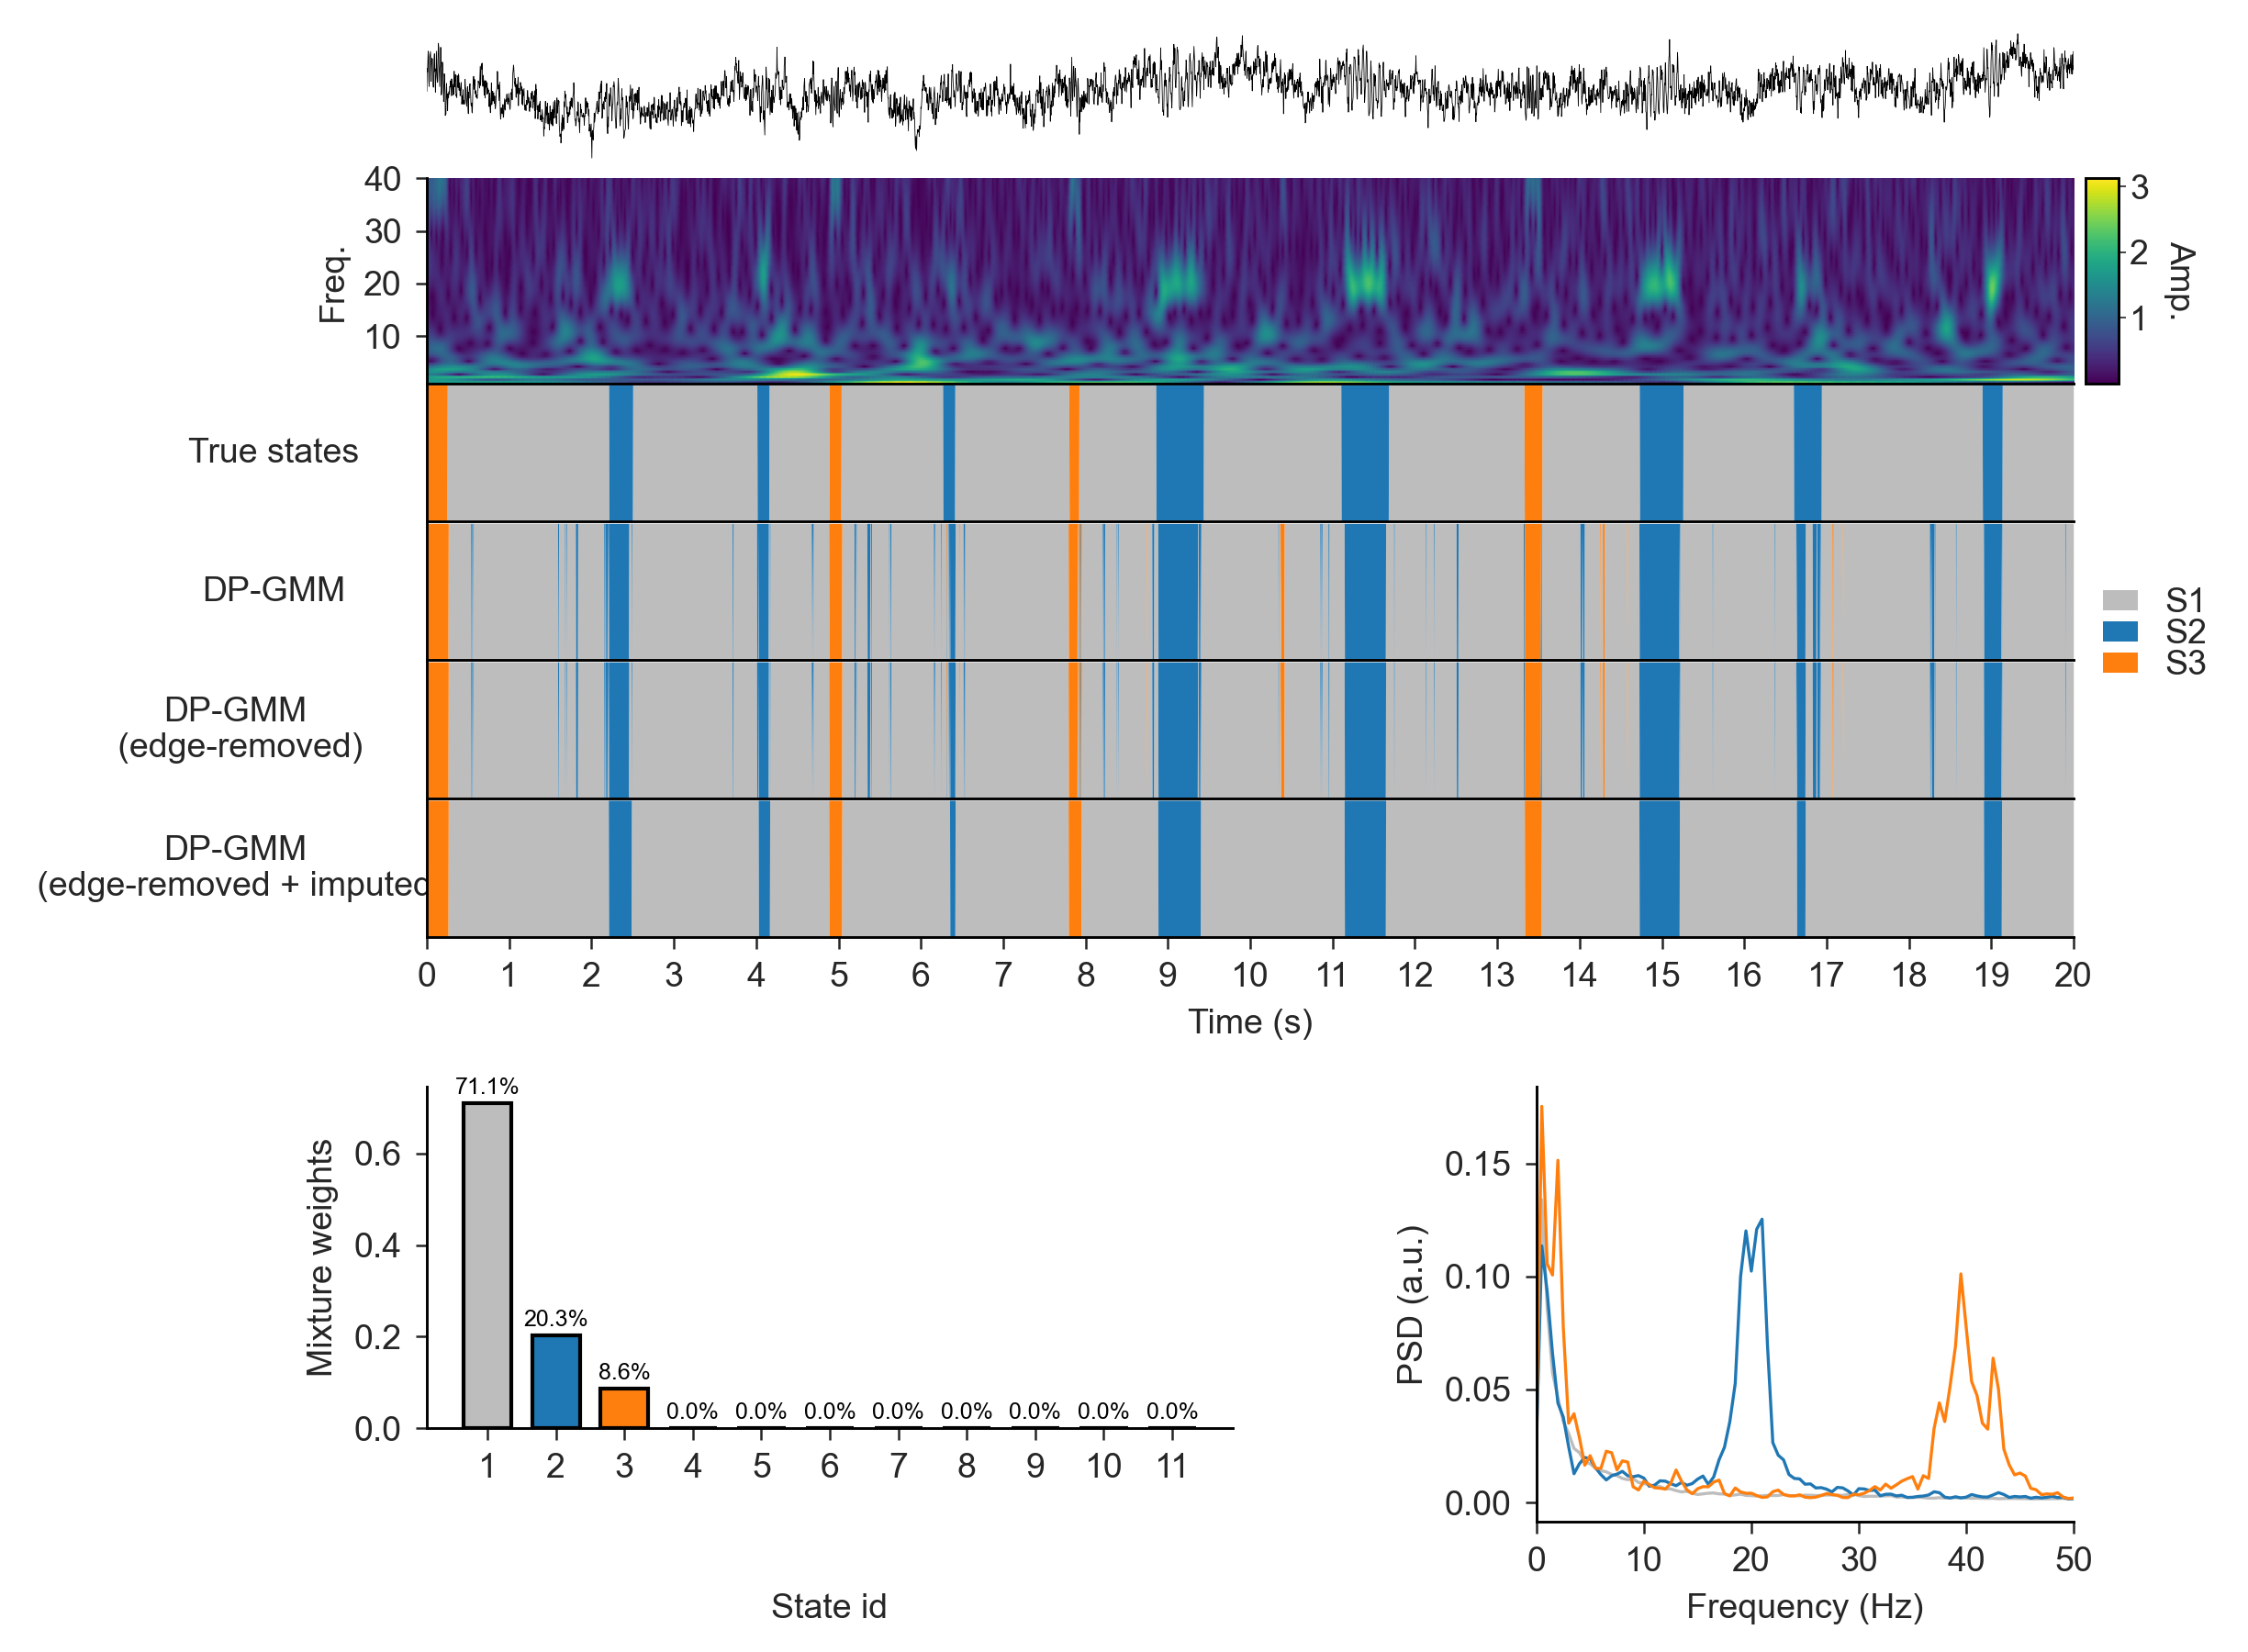

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


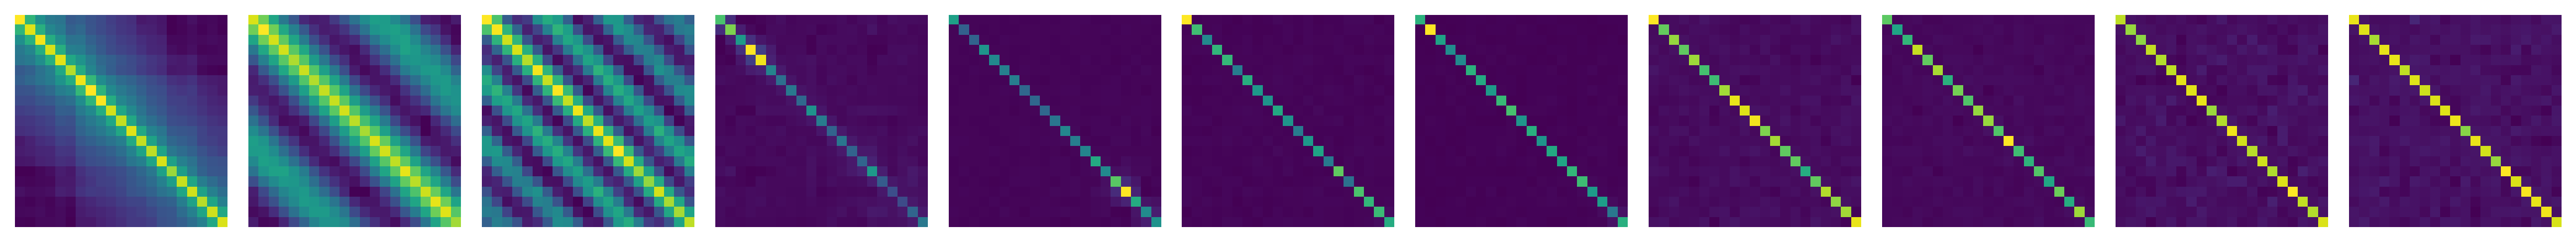

In [281]:
true_states, est_states_with_edge, est_states_without_edge, est_states_imputed = plot_summary_fig(res)


In [221]:
from nds_toolbox.analysis.burst_analysis import summarize_states
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def plot_summary_fig(res):
    from nds_toolbox.analysis.burst_analysis import summarize_states
    import matplotlib.pyplot as plt
    from matplotlib.ticker import MultipleLocator
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    tde_data = res["tde_data"]
    trimmed_signal = res["trimmed_signal"]
    trimmed_time_vec = res["trimmed_time_vec"]
    num_active_states = res["num_active_states"]
    est_params = res["est_params"]
    weights = est_params["weights"]
    means = est_params["means"]
    covs = est_params["covs"]

    untrunc_weights = est_params["untrunc_weights"]
    untrunc_means = np.array(est_params["untrunc_means"])
    untrunc_covs = np.array(est_params["untrunc_covs"])
    est_states = res["est_states"]
    est_states_onehot = np.eye(num_active_states)[est_states]

    est_states_imputed = res["imputed_est_states"]
    est_states_imputed_onehot = np.eye(num_active_states)[est_states_imputed]

    true_states_onehot = np.eye(trimmed_states.max() + 1, dtype=np.float32)[trimmed_states]

    order, reordered_est_states_onehot = match_states(
        true_states_onehot, est_states_onehot, verbose=False
    )
    est_states = np.argmax(reordered_est_states_onehot, axis=1)
    est_states_onehot = np.eye(num_active_states)[est_states]

    untrunc_covs[:len(order)] = untrunc_covs[:len(order)][order]
    untrunc_weights = untrunc_weights[order]
    weights = weights[order]
    covs = covs[order]

    order, reordered_est_states_imputed_onehot = match_states(
        true_states_onehot, est_states_imputed_onehot, verbose=False
    )
    est_states_imputed = np.argmax(reordered_est_states_imputed_onehot, axis=1)
    est_states_imputed_onehot = np.eye(num_active_states)[est_states_imputed]

    #summary stats
    summary_stats = summarize_states(trimmed_signal, est_states, fs, num_states=num_active_states)

    fo = summary_stats["fractional_occupancies"]
    lifetimes = summary_stats["lifetimes"]
    median_lifetimes = summary_stats["median_lt_states"]
    CV_intervals = summary_stats["CV_intervals"]
    burst_rates = summary_stats["burst_rates"]
    powers = summary_stats["powers"]
    spectra = summary_stats["spectra"]
    f_vec, psd_vec = summary_stats["spectra"]

    cmap = plt.get_cmap("tab10")
    colors = [cmap(i) for i in range(num_states + 1)]
    grey = ["#BDBDBD"]
    colors = grey + colors

    state_labels = [f"S{i + 1}" for i in range(num_active_states)]

    start_t = 0
    plot_t = 30

    t, f, amp = compute_wavelet(trimmed_signal[start_t * fs:plot_t * fs], fs, f_min=1, f_max=80, df=0.5,
                                wavelet="cmor1.5-1.0")
    t += start_t

    mosaic = [["a1", "a1"],
              ["a2", "a2"],
              ["a3", "a3"],
              ["a4", "a4"],
              ["a5", "a5"],
              ["gap", "gap"],
              ["b", "c"],
              ["d", "c"],
              ]

    fig, axes = plt.subplot_mosaic(
        mosaic,
        figsize=(FIG_WIDTH - 1, 4.),  # a hair taller
        constrained_layout=True,
        gridspec_kw={"height_ratios": [0.4, 0.6, 0.4, 0.4, 0.4, 0.1, 1., 0.1],
                     "width_ratios": [0.6, 0.4]}
    )
    fig.set_constrained_layout_pads(w_pad=0.0, h_pad=0., hspace=0.0)
    axes["gap"].set_visible(False)

    axes["a1"].plot(trimmed_time_vec[start_t * fs:plot_t * fs], trimmed_signal[start_t * fs:plot_t * fs], lw=0.2,
                    color="k")
    axes["a1"].set_frame_on(False)
    axes["a1"].set_title(
        f"SNR = {snr_db} dB | burst_var = {burst_amp_sigma}| tukey_alpha = {tukey_alpha} \n  MCC = {np.round(mcc, 2)} | MCC (imputed) = {np.round(mcc_imputed, 2)} ",
        pad=0.3)
    axes["a1"].sharex(axes["a3"])
    axes["a1"].set_yticks([])
    axes["a1"].set_xticks([])

    #axes["b1"].set_ylabel(f"{plot_f}Hz", fontsize = TINY_SIZE, rotation = 0, labelpad = 20)

    for s in ("top", "right", "bottom", "left"):
        axes["a1"].spines[s].set_visible(False)
    axes["a1"].set_frame_on(False)
    axes["a1"].tick_params(axis='both', which='both',
                           bottom=False, top=False, left=False, right=False,
                           labelbottom=False, labelleft=False)

    im = axes["a2"].imshow(
        amp, extent=[t[0], t[-1], f[0], f[-1]],
        origin="lower", aspect="auto", cmap="viridis",
        vmin=amp.min(), vmax=amp.max()
    )
    axes["a2"].set_ylabel("Freq.")
    #axes["a2"].set_title("Wavelet Transform",pad = 0.3)

    axes["a2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
    axes["a2"].yaxis.set_major_locator(MultipleLocator(10))

    axes["a2"].set_ylim(1, 40)
    #axes["a2"].sharex(axes["a1"])

    cax = inset_axes(
        axes["a2"],  # parent axis
        width="2%",  # width as percentage of a2
        height="100%",  # match the height
        loc="center right",  # position inside a2
        borderpad=-1.3  # negative value moves it outside slightly
    )

    # Add the colorbar to the inset axis
    cb = fig.colorbar(im, cax=cax)
    cb.set_label("Amp.", rotation=270, labelpad=12)
    cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)

    axes["a3"].stackplot(trimmed_time_vec[start_t * fs:plot_t * fs], true_states_onehot[start_t * fs:plot_t * fs].T,
                         linewidth=0, colors=colors, labels=state_labels)
    axes["a3"].set_ylabel(f"True states", rotation=0, labelpad=30, va="center")
    axes["a3"].sharex(axes["a5"])

    axes["a4"].stackplot(trimmed_time_vec[start_t * fs:plot_t * fs], est_states_onehot[start_t * fs:plot_t * fs].T,
                         linewidth=0, colors=colors, labels=state_labels)
    axes["a4"].set_ylabel(f"DP-GMM", rotation=0, labelpad=30, va="center")
    axes["a4"].sharex(axes["a5"])

    axes["a5"].stackplot(trimmed_time_vec[start_t * fs:plot_t * fs],
                         est_states_imputed_onehot[start_t * fs:plot_t * fs].T, linewidth=0, colors=colors,
                         labels=state_labels)
    axes["a5"].set_ylabel(f"DP-GMM \n (imputed)", rotation=0, labelpad=50, va="center")
    axes["a5"].sharex(axes["a5"])

    for key in ["a1", "a2", "a3", "a4"]:
        axes[key].tick_params(axis="x", which="both", bottom=False, labelbottom=False)

    from matplotlib.ticker import MultipleLocator
    axes["a5"].xaxis.set_major_locator(MultipleLocator(1.0))

    axes["a5"].set_xlabel("Time (s)")

    #axes["a4"].xaxis.set_major_locator(MultipleLocator(1.0))
    #axes["a5"].xaxis.set_minor_locator(MultipleLocator(0.5))
    #axes["a5"].tick_params(axis='x', which='both', bottom=True, labelbottom=True, length = 0)
    axes["a5"].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes["a5"].set_ylim(0, 1)
    axes["a5"].set_xlim(start_t, plot_t)

    axes["a5"].spines["bottom"].set_visible(True)  # keep x-axis frame

    handles, labels = axes["a5"].get_legend_handles_labels()

    fig.legend(handles, labels,
               loc="center left",  # anchor to left of the bbox
               bbox_to_anchor=(0.98, 0.62),  # (x, y) in figure coordinates
               frameon=False,
               handlelength=1,
               handleheight=0.5,
               labelspacing=0.0,
               ncol=2,
               columnspacing=0.2,
               )

    for k, w in enumerate(untrunc_weights):
        axes["b"].bar(k, w, width=0.7, color=colors[k], zorder=1, align="center", edgecolor="k")
        axes["b"].text(k, w + 0.02, "%.1f%%" % (w * 100.0), horizontalalignment="center", color="k",
                       fontsize=MY_FONT_SIZE - 3)
        axes["b"].set_ylabel("Mixture weights")
        axes["b"].set_xticks(np.arange(num_states), labels=np.arange(1, num_states + 1))
        axes["b"].tick_params(axis='y')

        #axes["b"].set_ylim(0, 0.3)

    for i in range(num_active_states):
        axes["c"].plot(f_vec[i], psd_vec[i], color=colors[i], lw=0.8, alpha=1)
        axes["c"].set_xlim(0, 50)
        axes["c"].set_xlabel("Frequency (Hz)")
        axes["c"].set_ylabel("PSD (a.u.)")
        #axes["c"].set_ylim(0, 0.23)
        #ab_c.tick_params(axis="both", which="both", bottom = False, top = False, left = False, right = False)
        #ab_c.grid(False)
        #axes["c"].set_yscale("log")
        #axes["c"].set_xscale("log")

    axes["d"].set_xticks([])
    axes["d"].set_yticks([])
    axes["d"].spines[:].set_visible(False)
    axes["d"].set_xlabel("State id")
    fig.align_xlabels([axes["c"], axes["d"]])

    fig.align_ylabels([axes["a3"], axes["a4"]])

    fig.canvas.draw()
    #fig.savefig(f"results.jpg",bbox_inches="tight",)

    plt.show()

    fig, ax = plt.subplots(1, untrunc_covs.shape[0], figsize=(untrunc_covs.shape[0] * 2, 2),
                           gridspec_kw={"wspace": 0.1})
    for i, cov in enumerate(untrunc_covs):
        ax[i].imshow(cov, cmap="viridis")
        ax[i].set_axis_off()

    plt.show()

    est_states_imputed_onehot
    est_states_onehot





In [222]:



def empirical_transition_matrix(states, n_states=None, alpha=0.0, ignore_negative=True):
    """
    Compute empirical transition counts and probabilities from a state sequence.

    Parameters
    ----------
    states : array-like of shape (T,)
        Integer state labels over time.
    n_states : int or None
        Number of states. If None, inferred as max(states)+1 after filtering.
    alpha : float
        Additive pseudocount for smoothing.
    ignore_negative : bool
        If True, removes labels < 0 before computing transitions.

    Returns
    -------
    counts : (K, K) ndarray
        Transition count matrix.
    probs : (K, K) ndarray
        Row-normalized transition probability matrix.
    """
    z = np.asarray(states).astype(int)

    if ignore_negative:
        z = z[z >= 0]

    if z.ndim != 1:
        raise ValueError("states must be 1D")

    if len(z) < 2:
        raise ValueError("Need at least 2 time points")

    if n_states is None:
        n_states = int(z.max()) + 1

    counts = np.zeros((n_states, n_states), dtype=float)

    for a, b in zip(z[:-1], z[1:]):
        if 0 <= a < n_states and 0 <= b < n_states:
            counts[a, b] += 1

    probs = counts + alpha
    row_sums = probs.sum(axis=1, keepdims=True)

    # avoid division by zero for states never visited
    probs = np.divide(probs, row_sums, out=np.zeros_like(probs), where=row_sums > 0)

    return counts, probs

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.draw()
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.draw()
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.draw()
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.draw()
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible

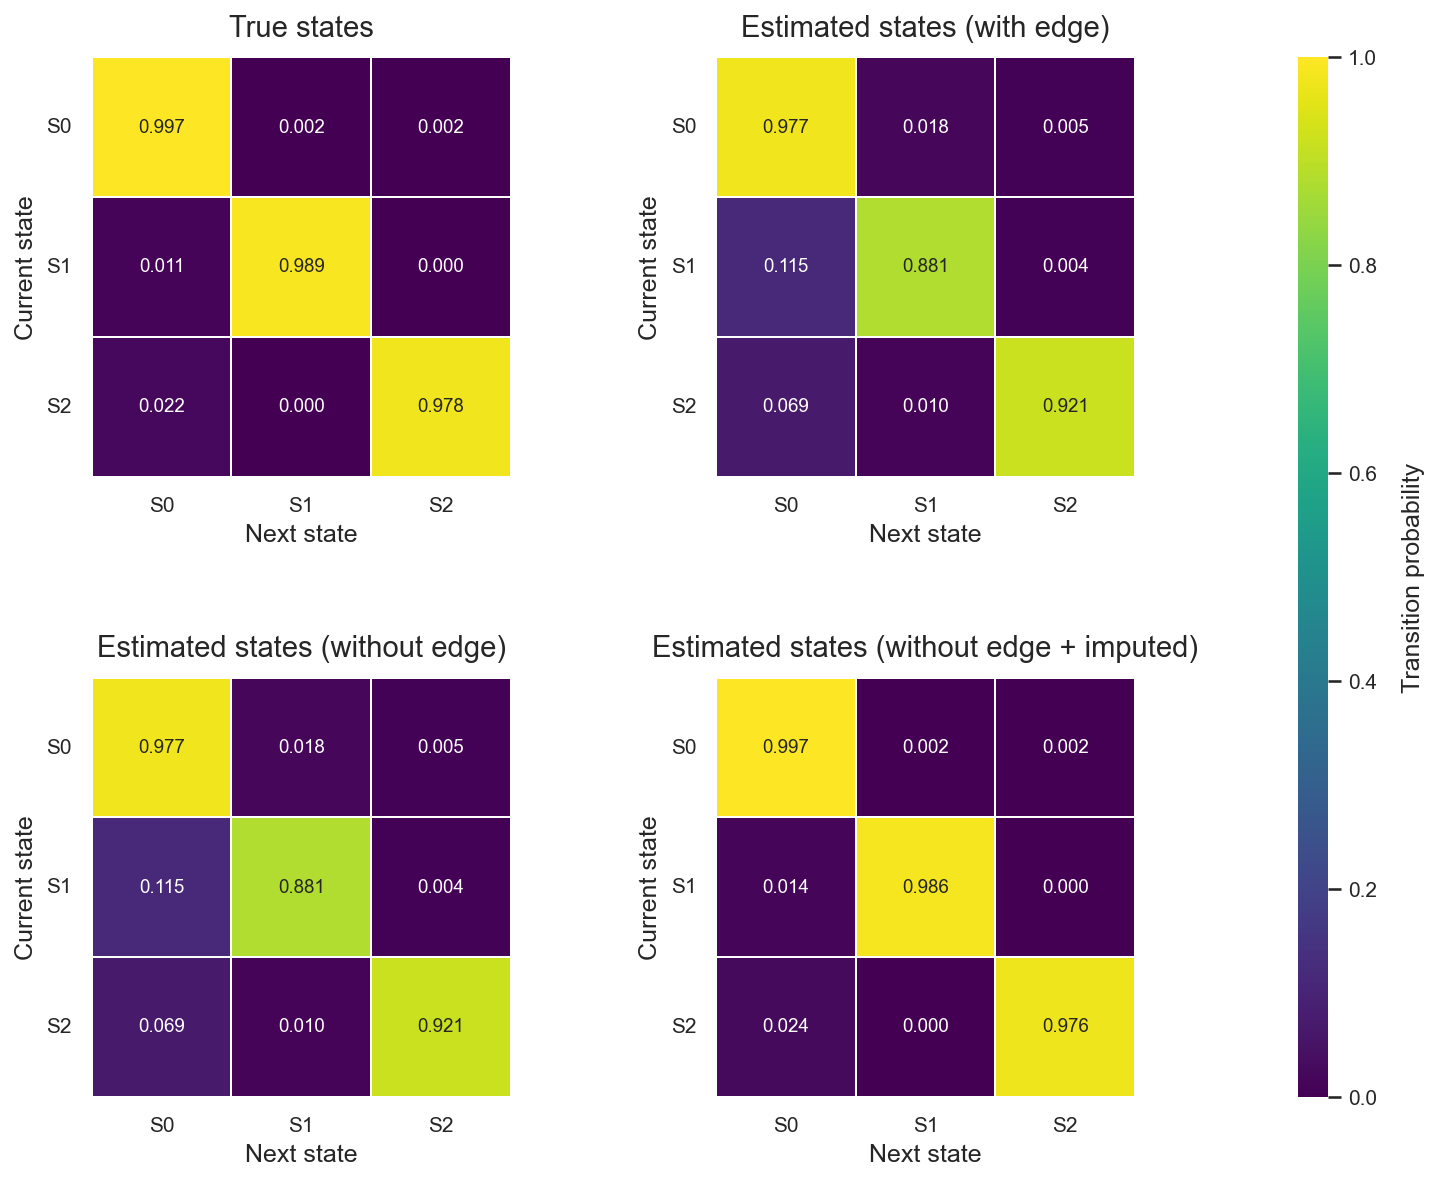

In [223]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Inputs
# ------------------------------------------------------------
_, P_true_states = empirical_transition_matrix(true_states)
_, P_est_states_with_edge = empirical_transition_matrix(est_states_with_edge)
_, P_est_states_without_edge = empirical_transition_matrix(est_states_without_edge)
_, P_est_states_imputed = empirical_transition_matrix(est_states_imputed)

matrices = [
    ("True states", np.asarray(P_true_states)),
    ("Estimated states (with edge)", np.asarray(P_est_states_with_edge)),
    ("Estimated states (without edge)", np.asarray(P_est_states_without_edge)),
    ("Estimated states (without edge + imputed)", np.asarray(P_est_states_imputed)),
]

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------
sns.set_theme(style="white")

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# shared color scale across all panels
vmin, vmax = 0.0, 1.0

# ------------------------------------------------------------
# Figure layout: 2x2 heatmaps + one external colorbar
# ------------------------------------------------------------
fig = plt.figure(figsize=(11, 9))
gs = fig.add_gridspec(
    nrows=2, ncols=3,
    width_ratios=[1, 1, 0.06],
    wspace=0.35,
    hspace=0.48
)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
]
cax = fig.add_subplot(gs[:, 2])  # colorbar axis spanning both rows

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
for i, (ax, (title, P)) in enumerate(zip(axes, matrices)):
    n_states = P.shape[0]
    labels = [f"S{k}" for k in range(n_states)]

    # slightly smaller annotation font for large matrices
    annot_size = 9 if n_states <= 4 else 9

    sns.heatmap(
        P,
        ax=ax,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        annot=True,
        fmt=".3f",
        annot_kws={"size": annot_size},
        square=True,
        linewidths=0.8,
        linecolor="white",
        cbar=(i == 0),
        cbar_ax=cax if i == 0 else None,
        xticklabels=labels,
        yticklabels=labels,
    )

    ax.set_title(title, pad=10)
    ax.set_xlabel("Next state")
    ax.set_ylabel("Current state")

    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)

    # cleaner frame
    for spine in ax.spines.values():
        spine.set_visible(False)

# colorbar formatting
cax.set_ylabel("Transition probability", rotation=90, labelpad=12)
cax.tick_params(labelsize=10)

plt.show()

In [112]:
est_states_with_edge.max()

np.int64(7)

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.draw()
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.draw()
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.draw()
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.draw()
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible

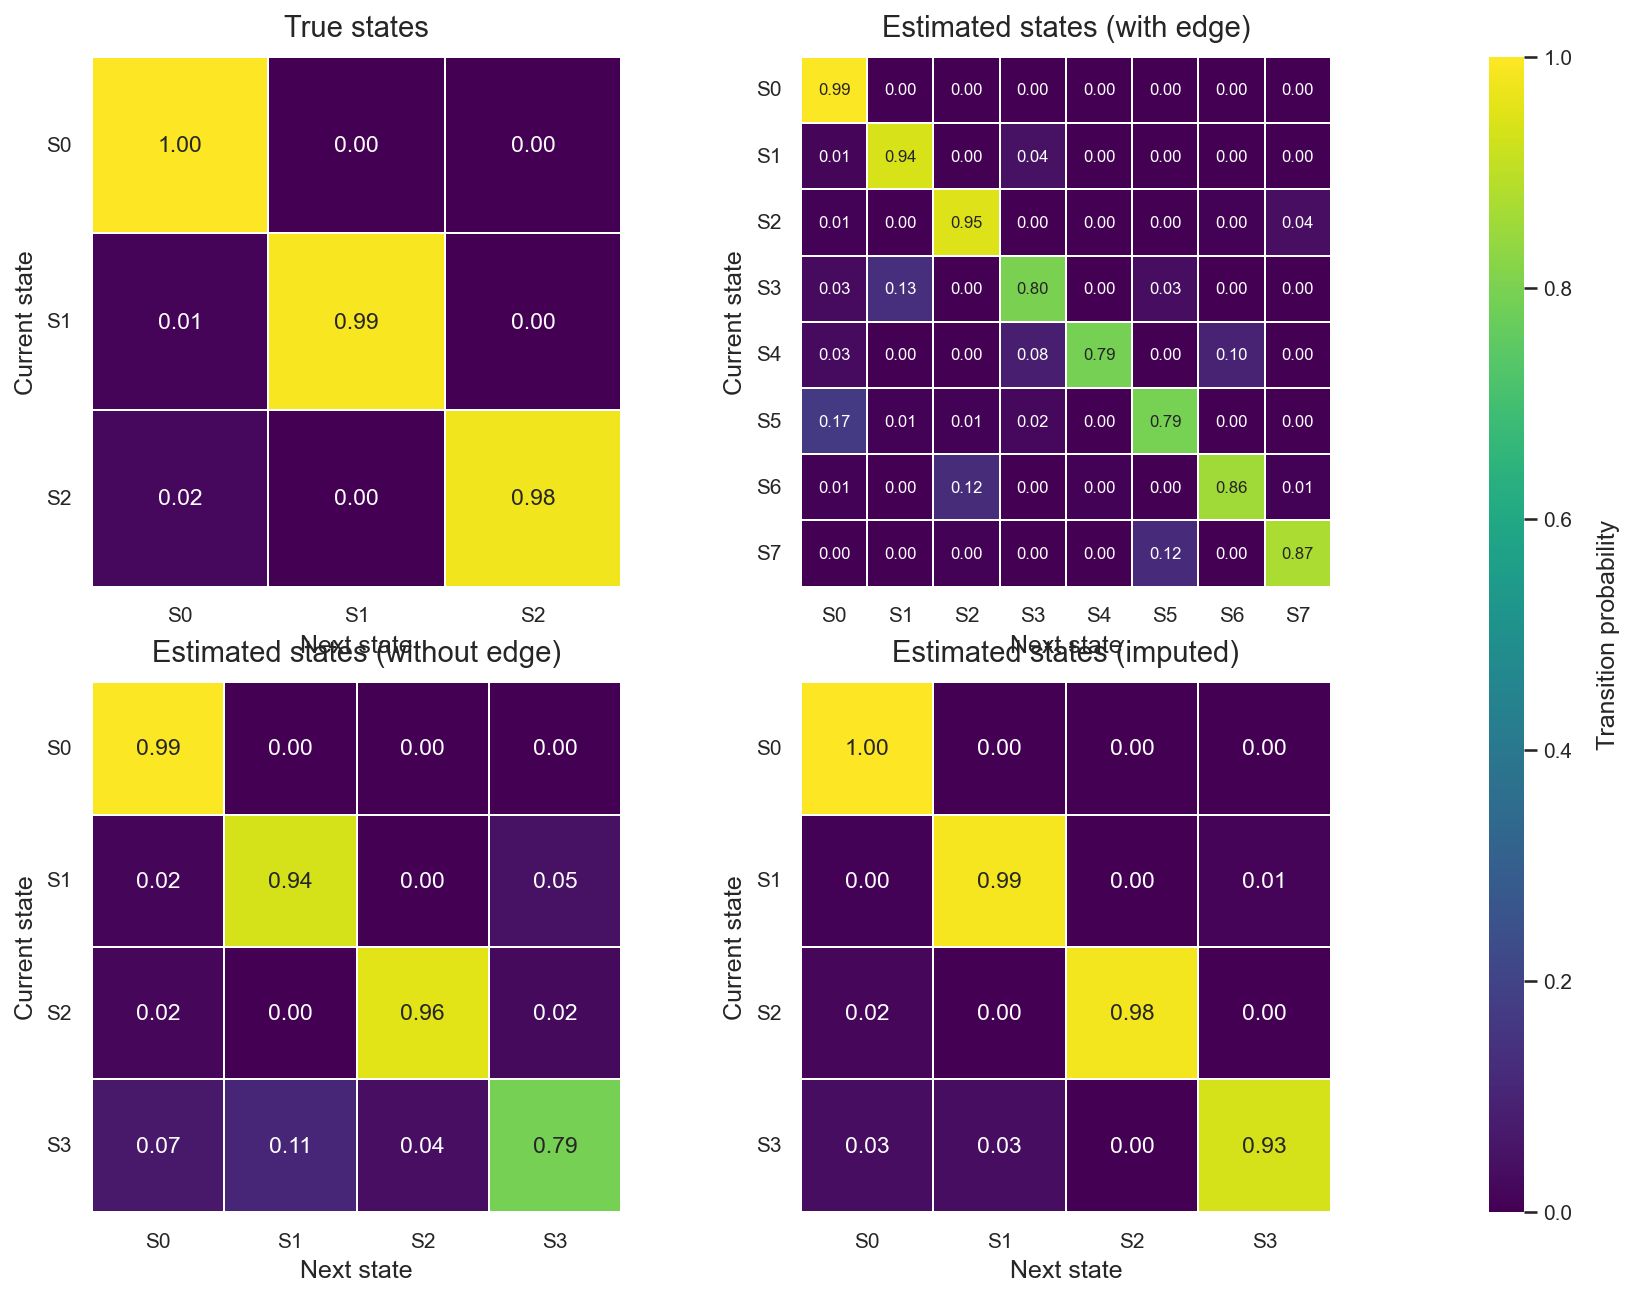

In [128]:
_, P_true_states = empirical_transition_matrix(true_states)
_, P_est_states_with_edge = empirical_transition_matrix(est_states_with_edge)
_, P_est_states_without_edge = empirical_transition_matrix(est_states_without_edge)
_, P_est_states_imputed = empirical_transition_matrix(est_states_imputed)

sns.heatmap(P_est_states_with_edge, cmap="viridis")

plt.show()


In [122]:
from nds_toolbox.models.hmm_pyro import compute_stationary_distribution

compute_stationary_distribution(P_true_states)
compute_stationary_distribution(P_est_states_with_edge)
compute_stationary_distribution(P_est_states_without_edge)
compute_stationary_distribution(P_est_states_imputed)


Array([0.8144986 , 0.09268284, 0.06727419, 0.0255444 ], dtype=float32)

In [81]:



def toeplitz_projection(C):
    D = C.shape[0]
    gamma = jnp.array([jnp.mean(jnp.diagonal(C, offset=k)) for k in range(D)])
    T = jnp.array([[gamma[jnp.abs(i - j)] for j in range(D)] for i in range(D)])
    return T


def non_toeplitz_score(C, eps=1e-12):
    T = toeplitz_projection(C)
    return jnp.linalg.norm(C - T) / (jnp.linalg.norm(C) + eps)



In [82]:
for i, cov in enumerate(untrunc_covs):
    d = np.diag(np.asarray(cov))
    print("cv", np.std(d) / (np.mean(d) + 1e-12))

cv 0.013334102
cv 0.018770562
cv 0.10014832
cv 0.03287813
cv 0.67256564
cv 0.7910994
cv 0.36816293
cv 0.44418153
cv 0.096568905
cv 0.0766028
cv 0.1213799


In [83]:



def psd_from_tde_cov(C, fs, nfft=4096):
    m = C.shape[0]
    r = np.array([np.mean(np.diag(C, k)) for k in range(m)])  # r[0..m-1]
    r_full = np.concatenate([r[:0:-1], r])  # symmetric
    S = np.fft.rfft(r_full, n=nfft)
    psd = np.real(S)
    f = np.fft.rfftfreq(nfft, d=1 / fs)
    return f, psd


def peakiness(f, psd, fmin=5, fmax=60):
    mask = (f >= fmin) & (f <= fmax)
    p = psd[mask]
    return float(p.max() / (p.mean() + 1e-12)), float(f[mask][np.argmax(p)])


In [84]:
import numpy as np


def autocov_from_tde_cov(C, *, symmetrize=True):
    """
    C: (m,m) covariance of time-delay embedded samples [x_t, x_{t-1}, ..., x_{t-(m-1)}]
    returns r_pos: length m array with r[k] for k=0..m-1
    """
    C = np.asarray(C)
    if symmetrize:
        C = 0.5 * (C + C.T)

    m = C.shape[0]
    r_pos = np.array([np.mean(np.diag(C, k=k)) for k in range(m)])  # k = lag
    return r_pos


In [85]:

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states + 1)]
grey = ["#BDBDBD"]
colors = grey + colors



In [86]:
num_emb

21

In [87]:
dim_vec = np.arange(-num_emb // 2 + 1, num_emb // 2 + 1)

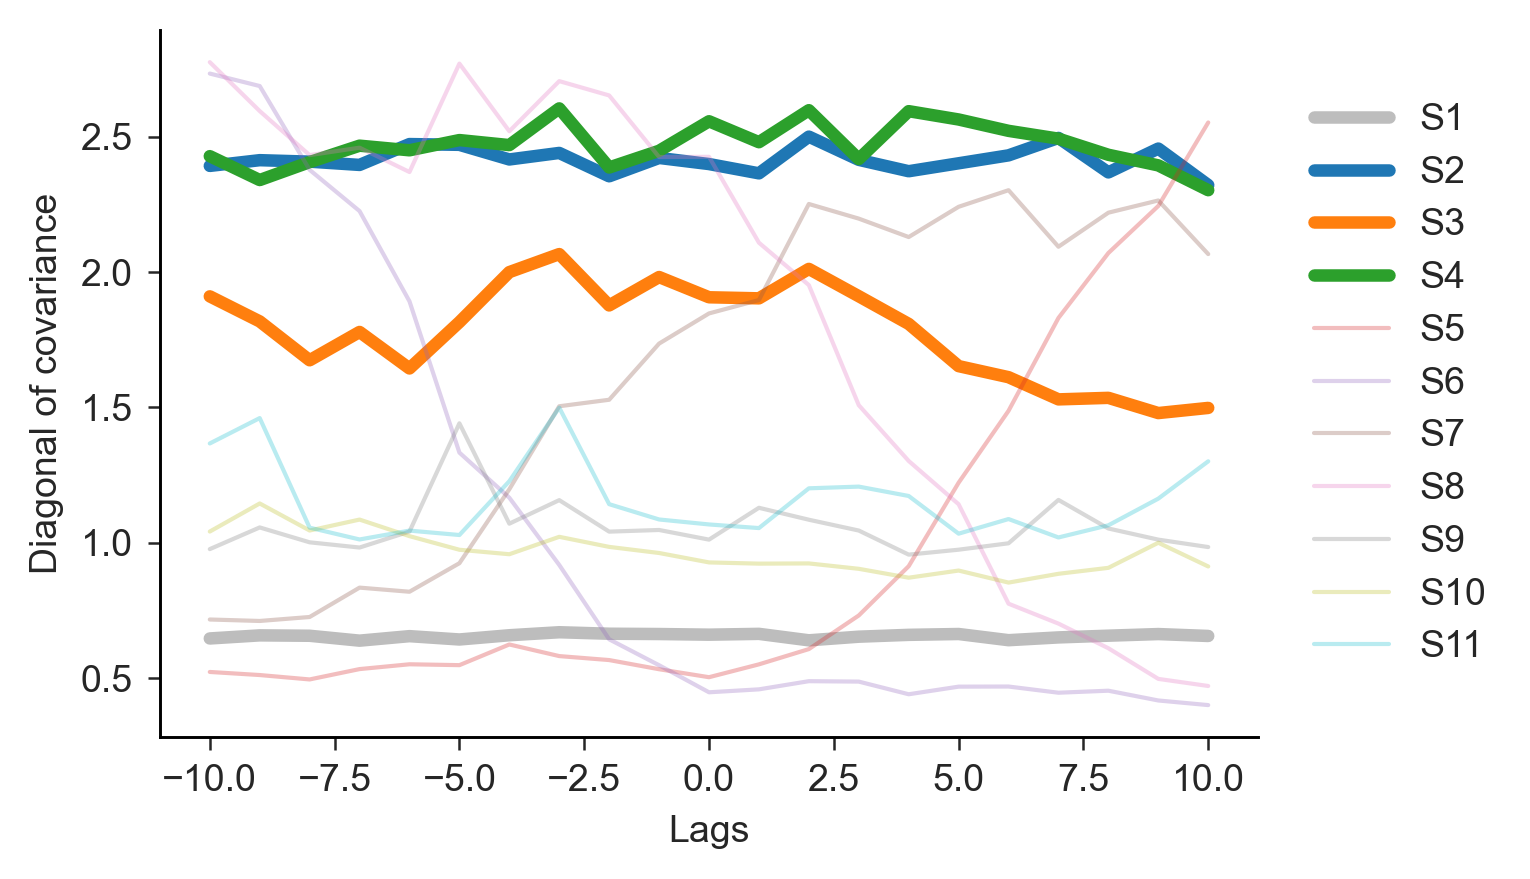

In [88]:
plt.figure(figsize=(FIG_WIDTH - 1, 3))

for i, cov in enumerate(untrunc_covs):

    if i <= 3:
        plt.plot(dim_vec, np.diag(cov), label=f"S{i + 1}", color=colors[i], lw=3)

    else:
        plt.plot(dim_vec, np.diag(cov), label=f"S{i + 1}", color=colors[i], lw=1, alpha=0.3)

plt.xlabel("Lags")
plt.ylabel("Diagonal of covariance")

# legend outside (right)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

# leave room on the right for the legend
plt.tight_layout(rect=[0, 0, 0.80, 1])

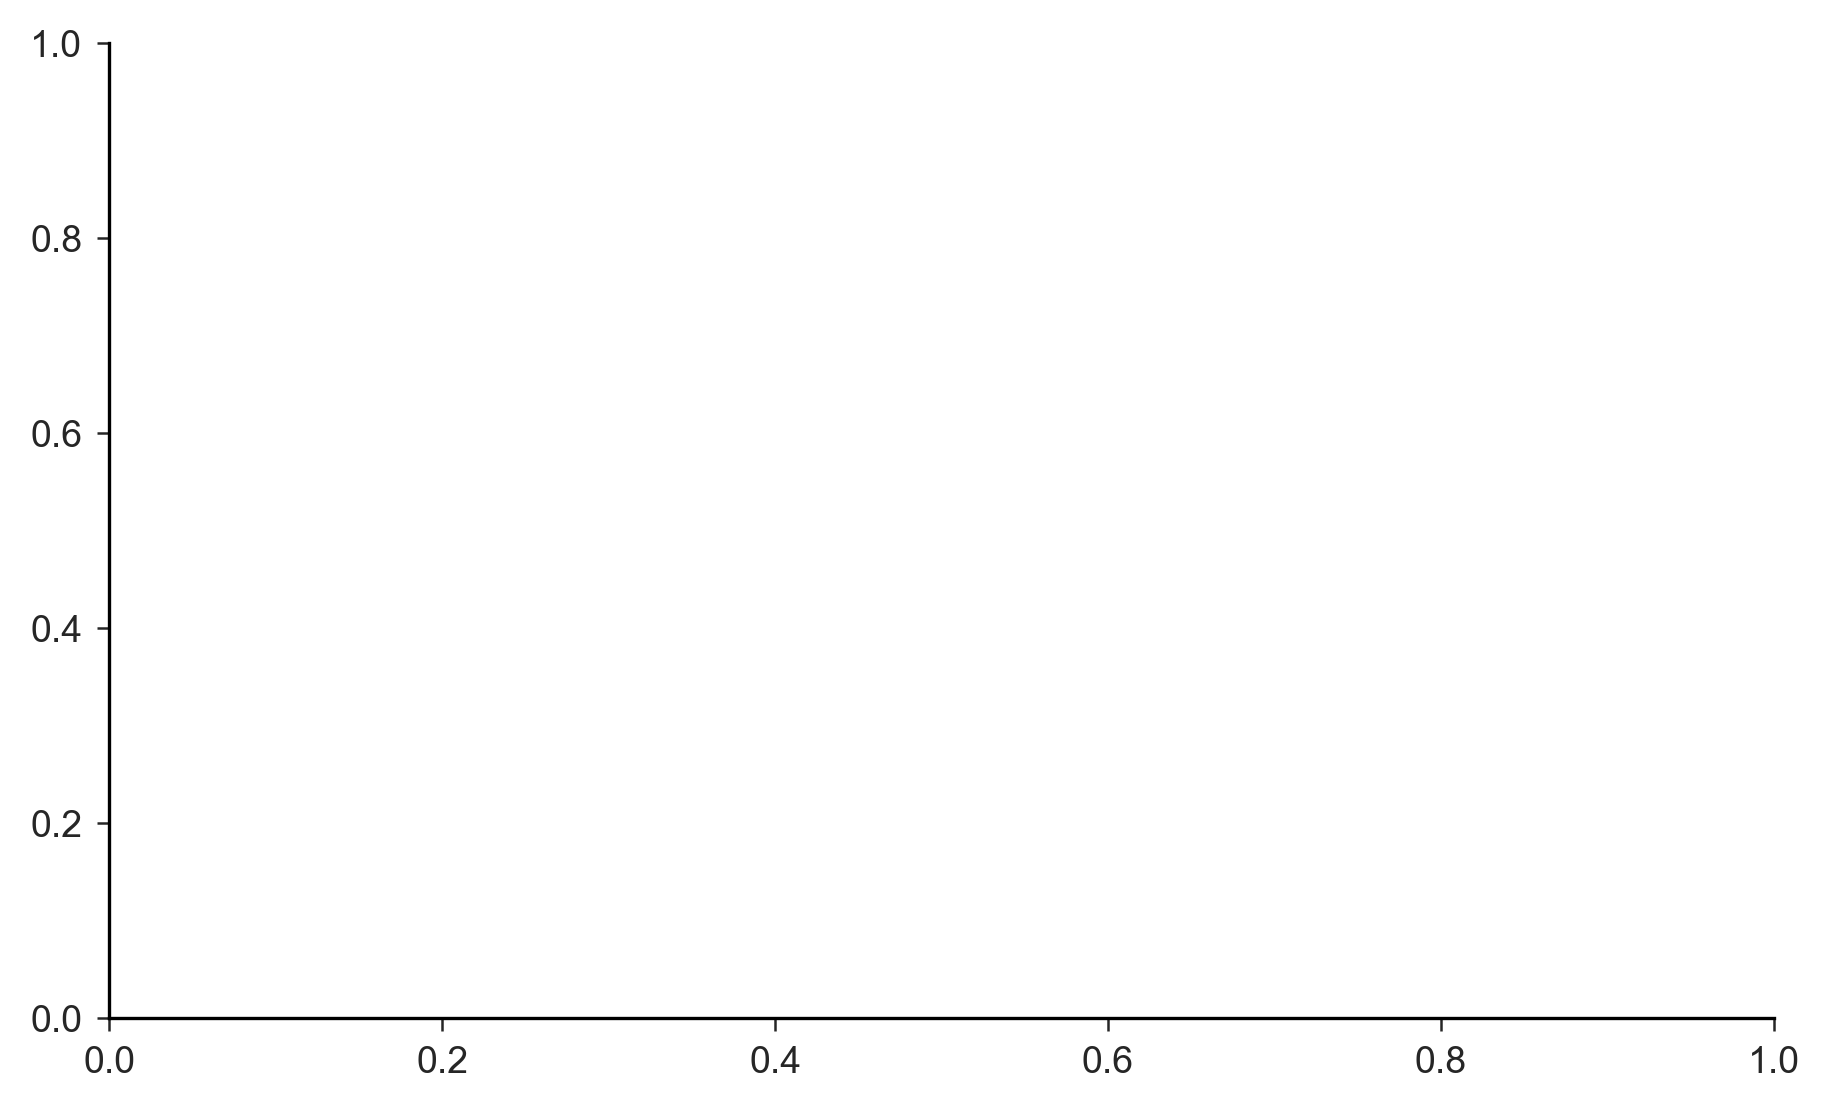

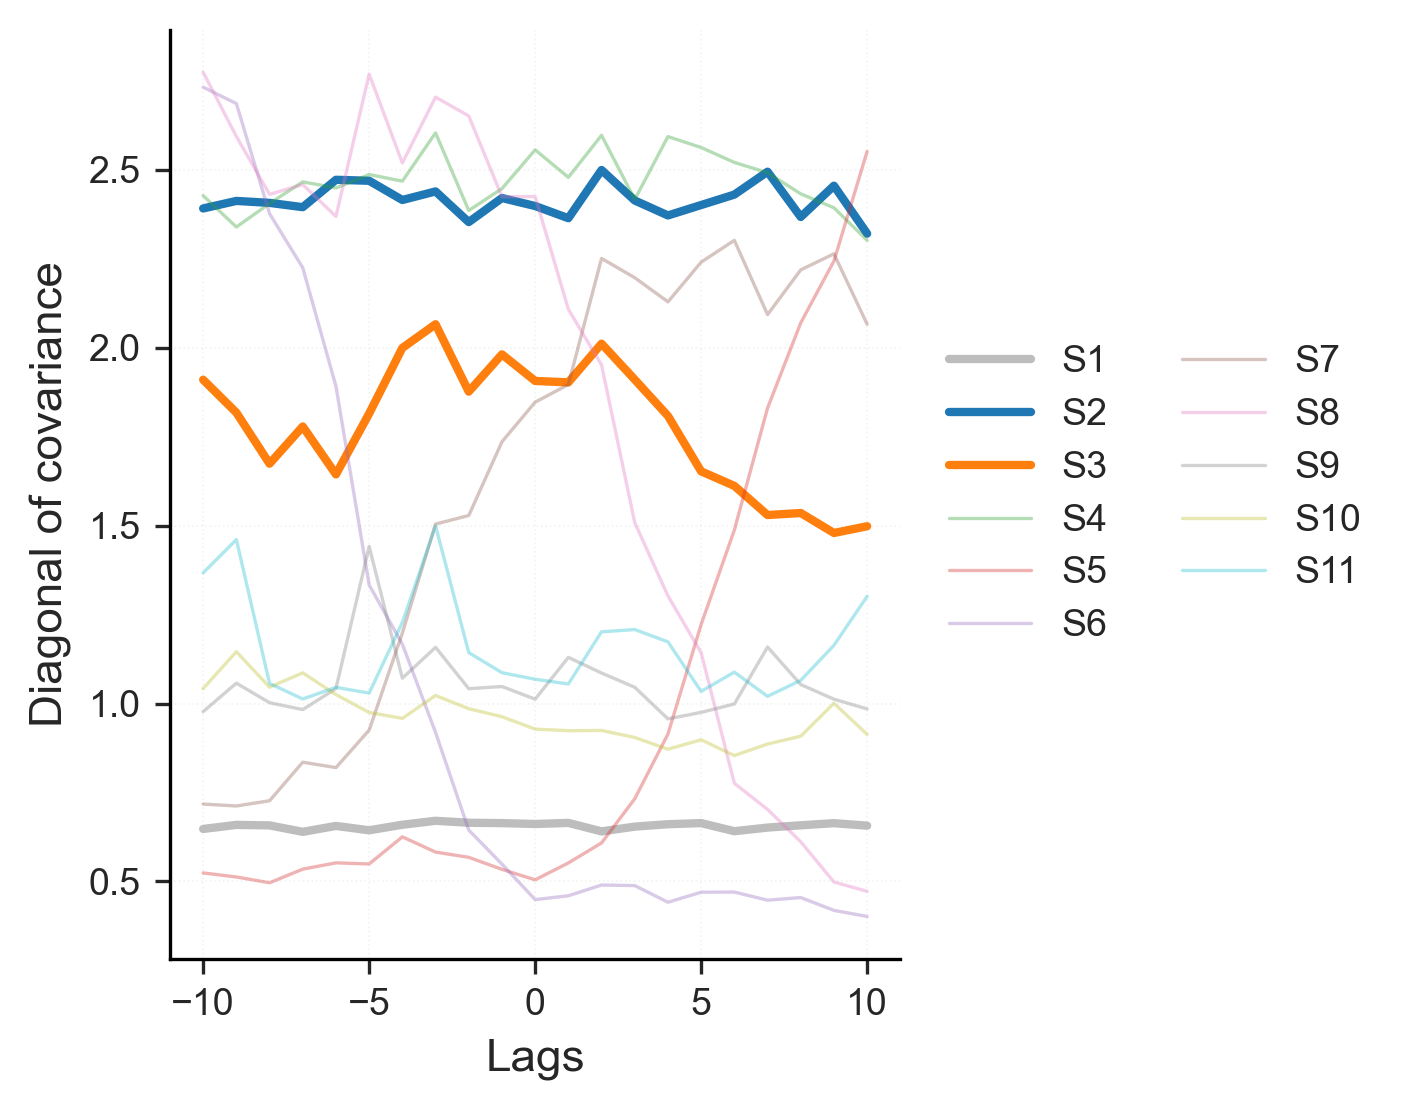

In [89]:
import numpy as np
import matplotlib.pyplot as plt

# ---- publication-ish defaults (tweak to your journal) ----
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.linewidth": 0.8,
    "lines.solid_capstyle": "round",
})

fig, ax = plt.subplots(figsize=(6.2, 3.8))

top_k = 3

fig, ax = plt.subplots(figsize=(6.2, 3.8))

for i, cov in enumerate(untrunc_covs):
    y = np.diag(cov)
    lw = 2.0 if i < 3 else 0.8
    alpha = 1.0 if i < 3 else 0.35
    ax.plot(dim_vec, y, color=colors[i], lw=lw, alpha=alpha, label=f"S{i + 1}")

ax.set_xlabel("Lags")
ax.set_ylabel("Diagonal of covariance")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(direction="out", length=3.5, width=0.8)
ax.grid(True, which="major", linewidth=0.4, alpha=0.25)

# split legend into columns so it doesn't become a tall wall
ncol = 2 if len(untrunc_covs) <= 12 else 3
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, ncol=ncol, handlelength=2.2)

fig.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()


IndexError: list index out of range

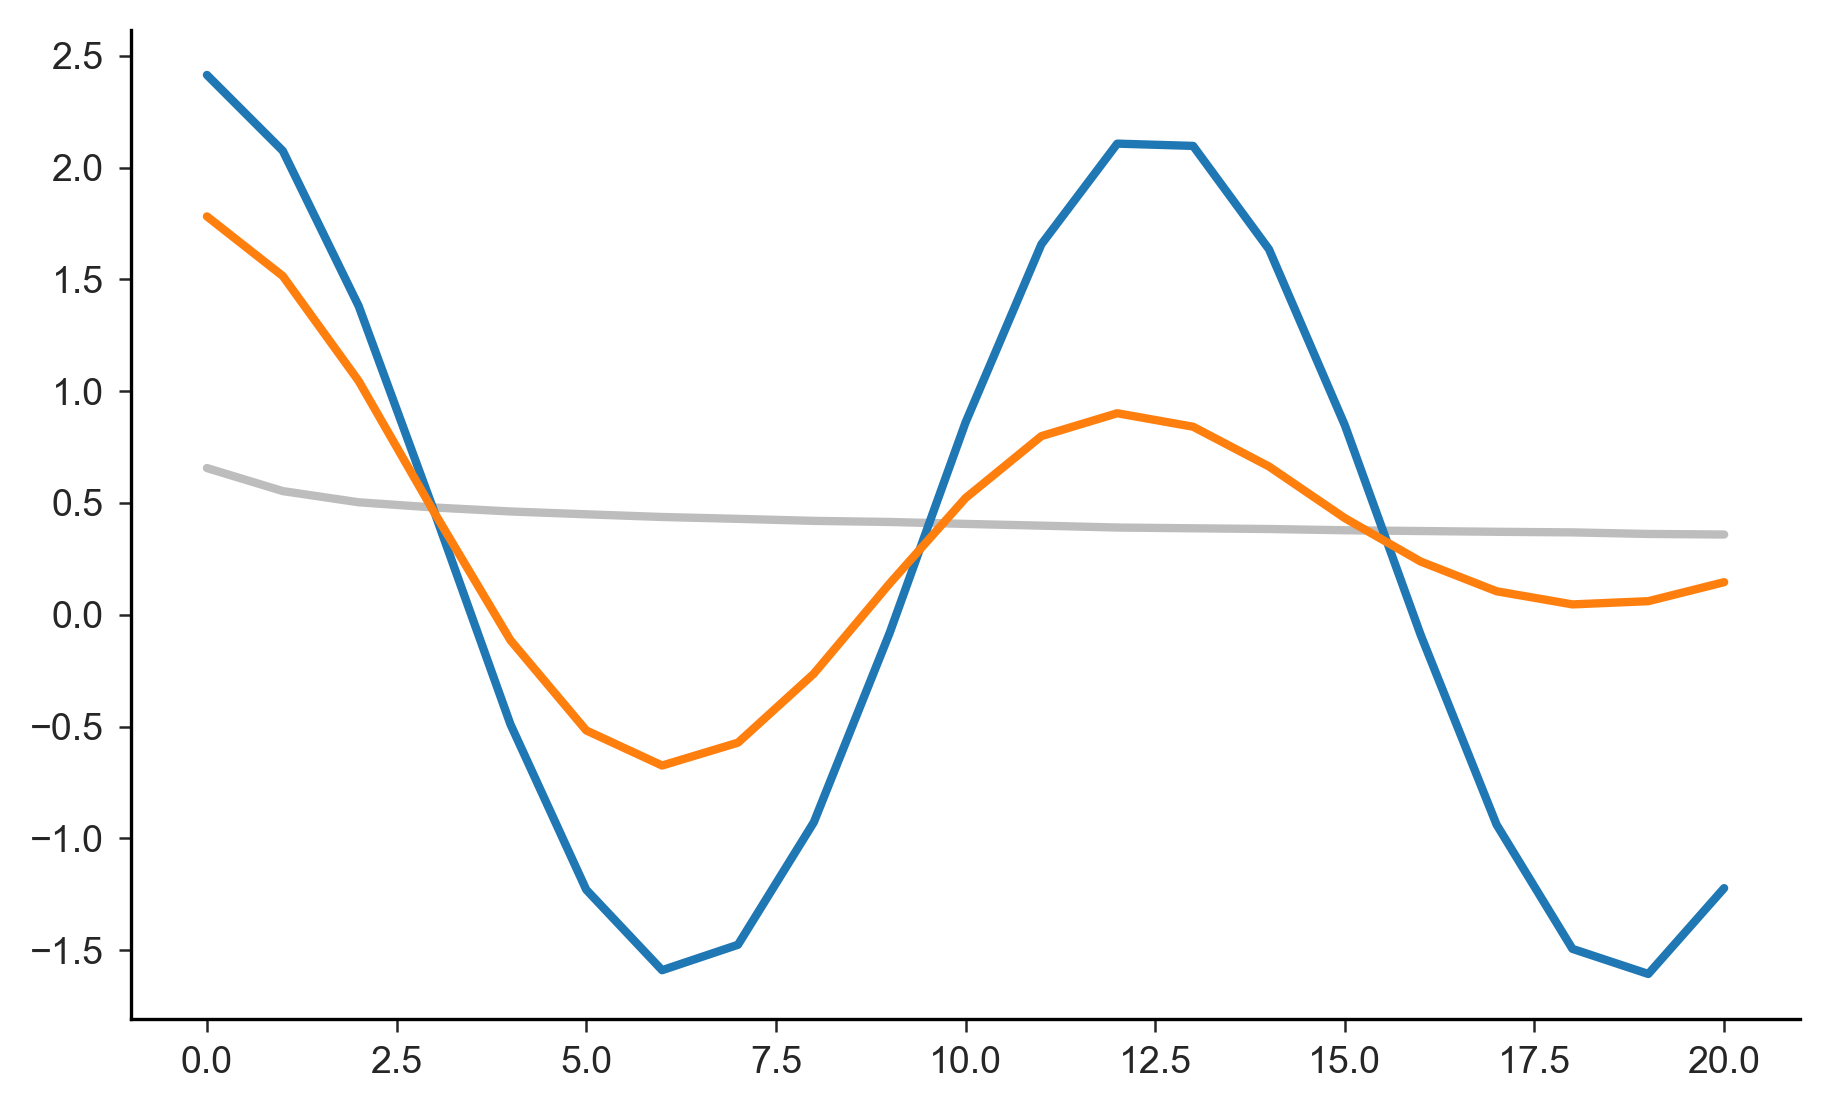

In [90]:
fig, ax = plt.subplots(figsize=(6.2, 3.8))
for i, cov in enumerate(covs):
    r = autocov_from_tde_cov(cov)
    plt.plot(r, color=colors[i], label=labels[i], lw=2)
ax.set_xlabel("Lags")
ax.set_ylabel("autocovariance function")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

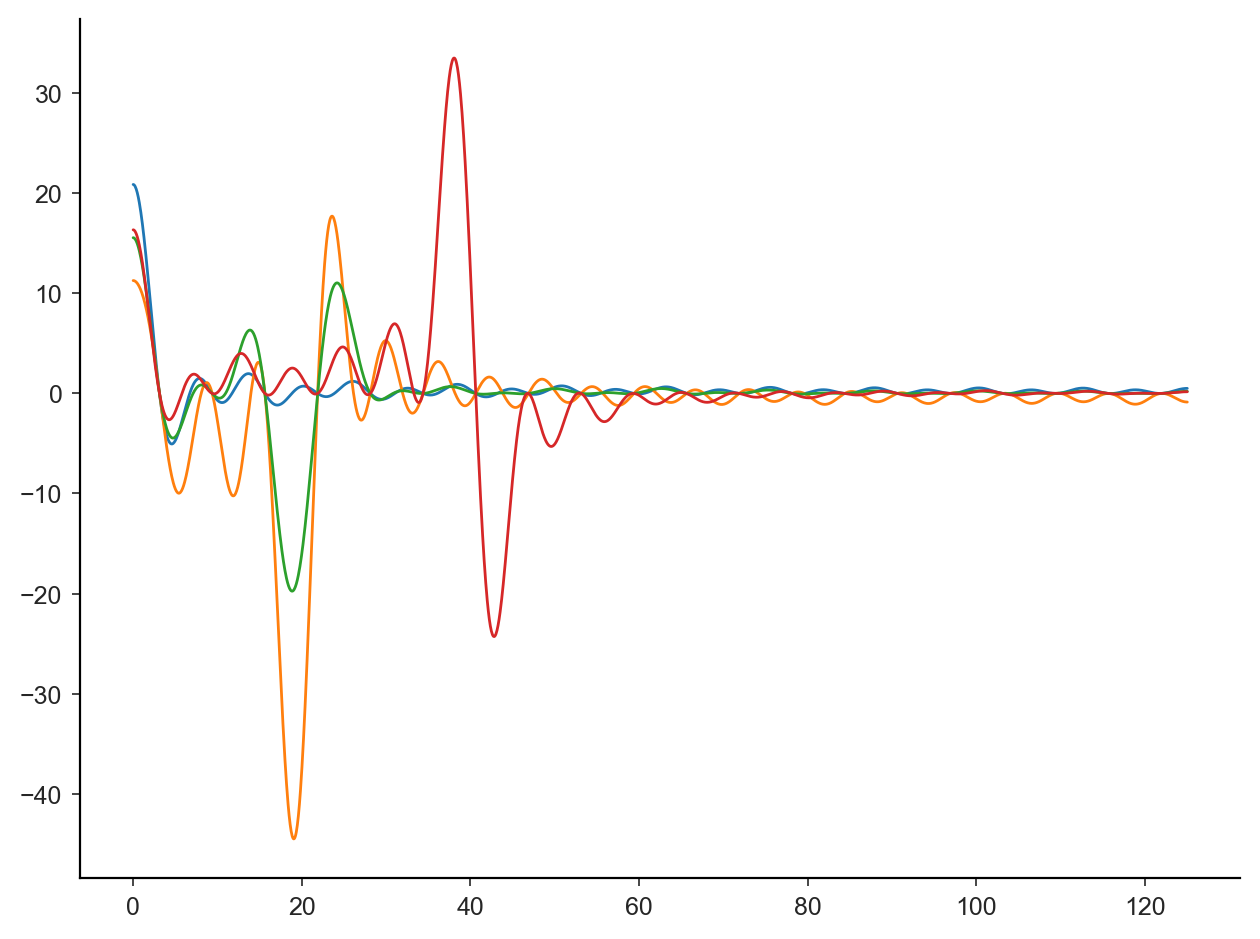

In [85]:
for cov in covs:
    f, psd = psd_from_tde_cov(cov, fs)
    plt.plot(f, psd)

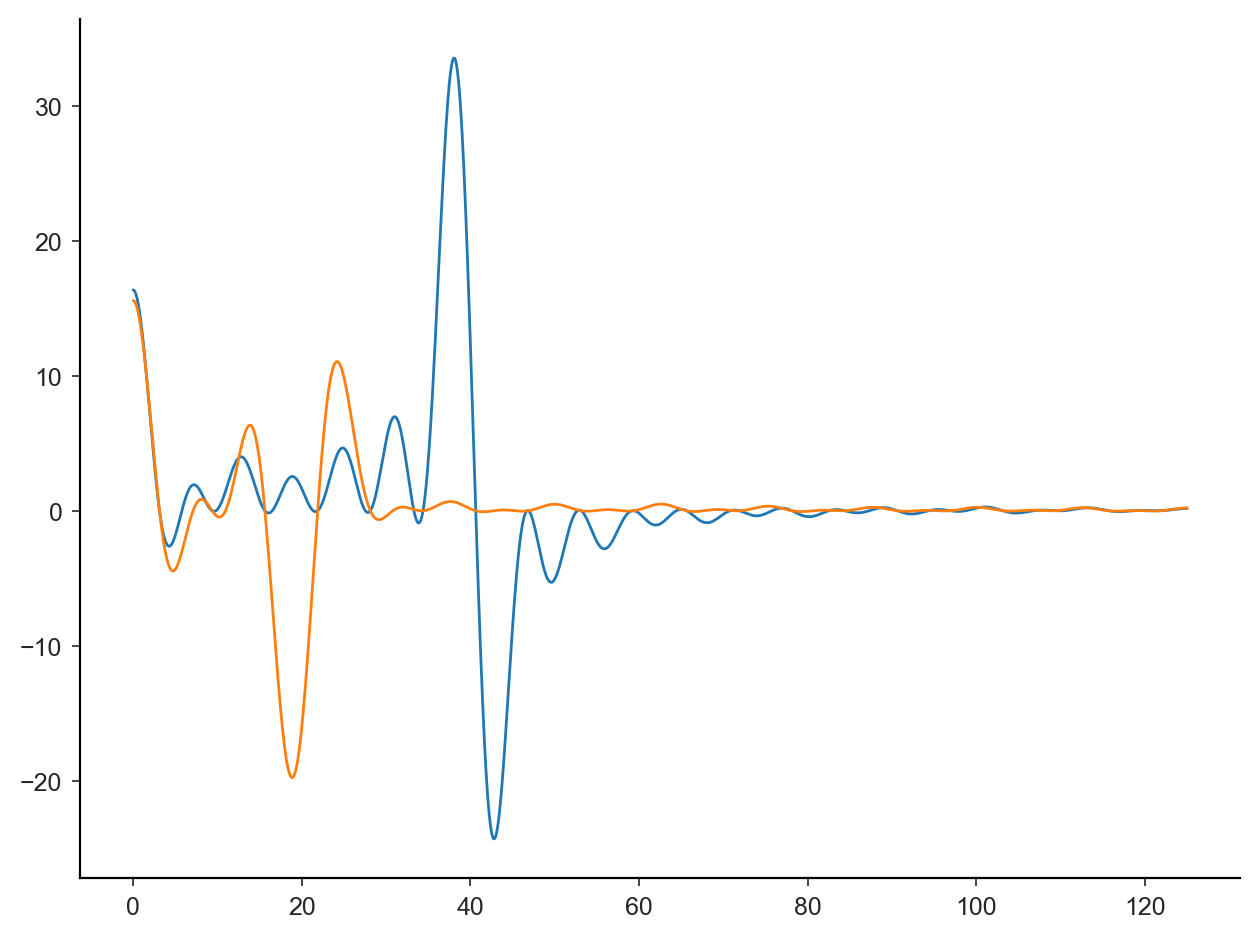

In [86]:
f, psd = psd_from_tde_cov(covs[-1], fs)
plt.plot(f, psd)

f, psd = psd_from_tde_cov(covs[-2], fs)
plt.plot(f, psd)


# optuna

In [ ]:
def match_states(one_hot_states1, one_hot_states2, verbose=False, eps=1e-12):
    """
    Robust state matching:
    - drops inactive (all-constant) columns before matching to avoid Hungarian ties
    - matches active columns via correlation
    - returns a full-length 'order' for original columns of one_hot_states2:
        matched active columns first (in best-match order), then the remaining columns.
    """
    assert one_hot_states1.shape[0] == one_hot_states2.shape[0], "T must match"
    K1 = one_hot_states1.shape[1]
    K2 = one_hot_states2.shape[1]

    # Active columns: not constant over time
    std1 = one_hot_states1.std(axis=0)
    std2 = one_hot_states2.std(axis=0)
    active1 = np.where(std1 > eps)[0]
    active2 = np.where(std2 > eps)[0]

    if verbose:
        print(f"Active in 1: {len(active1)}/{K1}, Active in 2: {len(active2)}/{K2}")

    # If nothing active, nothing to match
    if len(active1) == 0 or len(active2) == 0:
        order = np.arange(K2)
        return order, one_hot_states2

    # Build correlation matrix only over active columns
    C = np.zeros((len(active1), len(active2)), dtype=float)
    for ii, i in enumerate(active1):
        x = one_hot_states1[:, i]
        x_std = x.std()
        for jj, j in enumerate(active2):
            y = one_hot_states2[:, j]
            y_std = y.std()
            if x_std <= eps or y_std <= eps:
                C[ii, jj] = 0.0
            else:
                C[ii, jj] = np.corrcoef(x, y)[0, 1]

    # Hungarian: maximize total correlation
    row_ind, col_ind = linear_sum_assignment(-C)

    # Map: active2[col_ind[k]] is matched to active1[row_ind[k]]
    matched_active2 = active2[col_ind]

    # Build full order for columns of one_hot_states2
    remaining2 = np.setdiff1d(np.arange(K2), matched_active2, assume_unique=False)
    order = np.concatenate([matched_active2, remaining2])

    reordered_one_hot_states2 = one_hot_states2[:, order]

    if verbose:
        for r, c in zip(row_ind, col_ind):
            print(f"state1 {active1[r]}  <->  state2 {active2[c]}  corr={C[r, c]:.3f}")

    return order, reordered_one_hot_states2




In [ ]:


def run_dpgmm_pipeline(*, data, fs,
                       num_emb,
                       num_states,
                       min_samples,
                       seed,
                       num_particles,
                       learning_rate,
                       batch_size,
                       num_epochs,
                       use_model_tqdm=True,
                       verbose=True):
    #Time-delay embedding
    tde_data = compute_tde(data, num_emb)
    trimmed_signal = trim_data(data, num_embeddings=num_emb, verbose=False)
    trimmed_time_vec = np.arange(len(trimmed_signal)) / fs

    #DP-GMM
    dpgmm_result = fit_DPGMM(data=tde_data,
                             num_states=num_states,
                             use_epoch_tqdm=False,
                             n_jobs=-1,
                             use_model_tqdm=use_model_tqdm,
                             learning_rate=learning_rate,
                             batch_size=batch_size,
                             num_models=8,
                             num_particles=num_particles,
                             learn_alpha=True,
                             alpha_prior=0.5,
                             num_epochs=num_epochs,
                             main_seed=seed,
                             verbose=verbose)

    est_params, loss_best, model_id_best, key_best, losses_all = dpgmm_result.values()

    alpha = est_params["alpha"]
    means = est_params["means"]
    covs = est_params["covs"]
    weights = est_params["weights"]

    order = np.argsort(-weights)
    weights = weights[order]
    means = means[order]
    covs = covs[order]

    est_params["weights"] = weights
    est_params["means"] = means
    est_params["covs"] = covs

    trunc_means, trunc_covs, trunc_weights, trunc_info = truncate(means, covs, weights, verbose=True, return_info=True)

    #the estimated states with truncated params
    est_states = get_states(tde_data, trunc_means, trunc_covs, trunc_weights)

    num_active_states = int(len(trunc_weights))  # after truncation

    #knn imputation
    imputed_est_states = imputing_mode(est_states, min_samples=min_samples)

    est_params = {
        "alpha": alpha,
        "weights": trunc_weights,
        "means": trunc_means,
        "covs": trunc_covs,
        "untrunc_means": means,
        "untrunc_covs": covs,
        "untrunc_weights": weights,
        "trunc_info": trunc_info, }

    return {
        "tde_data": tde_data,
        "trimmed_signal": trimmed_signal,
        "trimmed_time_vec": trimmed_time_vec,
        "num_active_states": num_active_states,
        "est_params": est_params,
        "est_states": est_states,
        "imputed_est_states": imputed_est_states,
        "loss_best": loss_best,
        "model_id_best": model_id_best,
        "key_best": key_best,
        "losses_all": losses_all,
    }









In [ ]:
if RUN_OPTUNA:
    import numpy as np
    import optuna
    from sklearn.metrics import matthews_corrcoef

    # -----------------------
    # Fixed simulation config
    # -----------------------
    n_seconds = 60 * 3

    snr_db = 0
    freq = np.array([20, 40])
    burst_cycles = [3, 7]
    noise_duration = [0.5, 3]
    burst_amp_sigma = 0.1
    beta = 1

    # Use a fixed small evaluation set of signals
    DATA_SEEDS = np.arange(5)


    def make_dataset(seed: int, fs: int):
        rng = np.random.default_rng(seed)
        d = simulate_bursty_signal(
            time_vec, fs, freq, burst_cycles, noise_duration,
            burst_type="sine", use_filter=True,
            snr_db=snr_db, burst_amp_sigma=burst_amp_sigma, beta=beta, rng=rng
        )

        # Prefer explicit keys if available
        if "signal" in d:
            signal = d["signal"]
        else:
            signal = next(iter(d.values()))

        if "states" in d:
            states = d["states"]
        else:
            cand = [v for v in d.values()
                    if isinstance(v, np.ndarray) and np.issubdtype(v.dtype, np.integer)]
            if not cand:
                raise ValueError(f"Could not find 'states' in output keys={list(d.keys())}")
            states = cand[0]

        # standardize deterministically per-signal
        signal = (signal - signal.mean()) / (signal.std() + 1e-12)
        return signal, states


    def objective(trial: optuna.Trial) -> float:
        fs = trial.suggest_categorical(
            "fs", [100, 250, 500])
        learning_rate = trial.suggest_categorical(
            "learning_rate", [1e-2, 5e-2]
        )
        n_seconds = 60 * 3

        snr_db = 0
        freq = np.array([20, 40])
        burst_cycles = [3, 7]
        noise_duration = [0.5, 3]
        burst_amp_sigma = 0.1
        beta = 1
        time_vec = np.linspace(0, n_seconds, int(fs * n_seconds), endpoint=False)

        mccs = []
        K_ests = []

        for j in range(2):

            # deterministic but different init per (trial, dataset)
            init_seed = 10_000 + 1000 * trial.number + j

            signal, states_true = make_dataset(init_seed, fs)
            num_states = int(np.ceil(np.log(len(signal))))
            min_samples = int(np.round((2 / np.max(freq)) * fs))
            num_emb = choose_embedding_dim(np.mean(freq), fs, min_cycles=2.5, ensure_odd=True)

            res = run_dpgmm_pipeline(
                data=signal,
                fs=fs,
                num_emb=num_emb,
                num_states=num_states,
                min_samples=min_samples,
                learning_rate=learning_rate,
                batch_size=2 ** 10,
                num_epochs=3000,
                num_particles=10,
                seed=init_seed,
                verbose=False,
            )

            est_states = res["est_states"]
            K_est = int(res["num_active_states"])
            K_ests.append(K_est)

            if K_est < 2:
                mccs.append(-1.0)
                continue

            trimmed_true = trim_data(states_true, num_embeddings=num_emb, verbose=False).astype(int)

            K_true = int(trimmed_true.max() + 1)
            true_oh = np.eye(K_true, dtype=np.float32)[trimmed_true]
            est_oh = np.eye(K_est, dtype=np.float32)[est_states]

            _, est_oh_reordered = match_states(true_oh, est_oh, verbose=False)
            est_states_matched = np.argmax(est_oh_reordered, axis=1)

            mccs.append(matthews_corrcoef(trimmed_true, est_states_matched))

        if len(mccs) == 0:
            return -1.0

        min_mcc = float(np.min(mccs))
        mean_mcc = float(np.mean(mccs))  # keep for inspection

        trial.set_user_attr("min_mcc", min_mcc)
        trial.set_user_attr("mean_mcc", mean_mcc)
        trial.set_user_attr("K_est_mean", float(np.mean(K_ests)))
        trial.set_user_attr("K_est_list", [int(k) for k in K_ests])
        trial.set_user_attr("mcc_list", [float(x) for x in mccs])

        return mean_mcc


    def callback(study, trial):
        mcc_list = trial.user_attrs.get("mcc_list", None)
        if mcc_list is None:
            return
        min_mcc = trial.user_attrs.get("min_mcc", trial.value)
        mean_mcc = trial.user_attrs.get("mean_mcc", float(np.mean(mcc_list)))
        s = ", ".join([f"{seed}:{mcc:.3f}" for seed, mcc in zip(DATA_SEEDS, mcc_list)])
        print(f"[trial {trial.number:03d}] min={min_mcc:.3f} mean={mean_mcc:.3f} | {s}")


    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=50, callbacks=[callback])

    print("Best MCC:", study.best_value)
    print("Best params:", study.best_params)

else:
    print('Skipped Optuna section (set RUN_OPTUNA=True to run).')


In [ ]:
if RUN_OPTUNA:
    import numpy as np
    import optuna
    from sklearn.metrics import matthews_corrcoef

    # -----------------------
    # Fixed simulation config
    # -----------------------
    n_seconds = 60 * 3
    fs = 250
    time_vec = np.linspace(0, n_seconds, int(fs * n_seconds), endpoint=False)

    snr_db = 10
    freq = np.array([20, 40])
    burst_cycles = [3, 7]
    noise_duration = [0.5, 3]
    burst_amp_sigma = 0.1
    beta = 1

    # Use a fixed small evaluation set of signals
    DATA_SEEDS = np.arange(5)


    def make_dataset(seed: int):
        rng = np.random.default_rng(seed)
        d = simulate_bursty_signal(
            time_vec, fs, freq, burst_cycles, noise_duration,
            burst_type="sine", use_filter=True,
            snr_db=snr_db, burst_amp_sigma=burst_amp_sigma, beta=beta, rng=rng
        )

        # Prefer explicit keys if available
        if "signal" in d:
            signal = d["signal"]
        else:
            signal = next(iter(d.values()))

        if "states" in d:
            states = d["states"]
        else:
            cand = [v for v in d.values()
                    if isinstance(v, np.ndarray) and np.issubdtype(v.dtype, np.integer)]
            if not cand:
                raise ValueError(f"Could not find 'states' in output keys={list(d.keys())}")
            states = cand[0]

        # standardize deterministically per-signal
        signal = (signal - signal.mean()) / (signal.std() + 1e-12)
        return signal, states


    DATASETS = [make_dataset(s) for s in DATA_SEEDS]

    # hyperparams you keep fixed
    min_samples = int(np.round((2 / np.max(freq)) * fs))
    num_emb = choose_embedding_dim(np.mean(freq), fs, min_cycles=2.5, ensure_odd=True)

    # If you insist on tying num_states to length, all signals have same length anyway
    num_states = int(np.ceil(np.log(len(DATASETS[0][0]))))


    def objective(trial: optuna.Trial) -> float:
        learning_rate = trial.suggest_categorical(
            "learning_rate", [1e-3, 1e-2, 5e-2, 5e-3]
        )
        batch_size = trial.suggest_categorical(
            "batch_size", [2 ** 6, 2 ** 7, 2 ** 8, 2 ** 9, 2 ** 10]
        )
        num_epochs = trial.suggest_categorical(
            "num_epochs", [500, 1000, 1500, 2000, 2500, 3000]
        )

        num_particles = trial.suggest_categorical(
            "num_particles", [1, 3, 5, 10]
        )

        mccs = []
        K_ests = []

        for j in range(3):
            # deterministic but different init per (trial, dataset)
            init_seed = 10_000 + 1000 * trial.number + j
            signal, states_true = make_dataset(init_seed)

            try:
                res = run_dpgmm_pipeline(
                    data=signal,
                    fs=fs,
                    num_emb=num_emb,
                    num_states=num_states,
                    min_samples=min_samples,
                    learning_rate=learning_rate,
                    batch_size=batch_size,
                    num_epochs=num_epochs,
                    num_particles=num_particles,
                    seed=init_seed,
                    verbose=False,
                )
            except Exception as e:
                # record for debugging
                trial.set_user_attr(f"error_seed_{DATA_SEEDS[j]}", repr(e))
                mccs.append(-1.0)
                K_ests.append(0)
                continue

            est_states = res["est_states"]
            K_est = int(res["num_active_states"])
            K_ests.append(K_est)

            if K_est < 2:
                mccs.append(-1.0)
                continue

            trimmed_true = trim_data(states_true, num_embeddings=num_emb, verbose=False).astype(int)

            K_true = int(trimmed_true.max() + 1)
            true_oh = np.eye(K_true, dtype=np.float32)[trimmed_true]
            est_oh = np.eye(K_est, dtype=np.float32)[est_states]

            _, est_oh_reordered = match_states(true_oh, est_oh, verbose=False)
            est_states_matched = np.argmax(est_oh_reordered, axis=1)

            mccs.append(matthews_corrcoef(trimmed_true, est_states_matched))

        if len(mccs) == 0:
            return -1.0

        min_mcc = float(np.min(mccs))
        mean_mcc = float(np.mean(mccs))  # keep for inspection

        trial.set_user_attr("min_mcc", min_mcc)
        trial.set_user_attr("mean_mcc", mean_mcc)
        trial.set_user_attr("K_est_mean", float(np.mean(K_ests)))
        trial.set_user_attr("K_est_list", [int(k) for k in K_ests])
        trial.set_user_attr("mcc_list", [float(x) for x in mccs])

        return mean_mcc


    def callback(study, trial):
        mcc_list = trial.user_attrs.get("mcc_list", None)
        if mcc_list is None:
            return
        min_mcc = trial.user_attrs.get("min_mcc", trial.value)
        mean_mcc = trial.user_attrs.get("mean_mcc", float(np.mean(mcc_list)))
        s = ", ".join([f"{seed}:{mcc:.3f}" for seed, mcc in zip(DATA_SEEDS, mcc_list)])
        print(f"[trial {trial.number:03d}] min={min_mcc:.3f} mean={mean_mcc:.3f} | {s}")


    study2 = optuna.create_study(direction="maximize")
    study2.optimize(objective, n_trials=50, callbacks=[callback])

    print("Best MCC:", study2.best_value)
    print("Best params:", study2.best_params)

else:
    print('Skipped Optuna section (set RUN_OPTUNA=True to run).')


## HMM

In [ ]:
import pyro
import pyro.distributions as dist

from pyro import poutine
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDelta, AutoNormal
from pyro.optim import Adam

In [ ]:
def model(x, num_states):
    num_data = x.shape[0]
    num_dim = x.shape[1]

    initial_probs = pyro.sample("initial_probs", dist.Dirichlet(torch.ones(num_states)))

    concentration = torch.ones(num_states, num_states)  # noninformative: uniform over transitions

    transition_probs = pyro.sample(
        "transition_probs", dist.Dirichlet(concentration).to_event(1)
    )

    with pyro.plate("hidden_state", num_states):
        loc = torch.zeros(num_dim)

        sigma = pyro.sample("sigma", dist.Exponential(torch.ones(num_dim)).to_event(1))
        L_cov = pyro.sample("L_cov", dist.LKJCholesky(num_dim, 1))
        D = torch.diag_embed(sigma)
        L_mat = torch.matmul(D, L_cov)

    obs_dist = dist.MultivariateNormal(loc=loc, scale_tril=L_mat)
    hmm_dist = dist.DiscreteHMM(initial_probs.log(), transition_probs.log(), obs_dist, duration=num_data)

    pyro.sample("x", hmm_dist, obs=x)


In [ ]:
def fit_HMM(
        x,
        model,
        num_states,
        *,
        num_epochs=500,
        tol=1e-6,
        initial_lr=0.05,
        gamma=0.1,
        verbose=True,
        use_epoch_tqdm=False):
    """
    Fit an HMM using SVI with optional early stopping.

    Parameters
    ----------
    …
    tol : float or None, optional
        If given, stop training early once the *scaled* ELBO loss falls
        strictly below this value (default is None, i.e. no early stop).
    …
    """
    # Convert to PyTorch tensor
    x_tensor = torch.tensor(x, dtype=torch.float32)

    # Clear parameter store
    pyro.clear_param_store()

    exposed_params = ["initial_probs", "transition_probs", "sigma", "L_cov"]
    guide = AutoDelta(poutine.block(model, expose=exposed_params))

    # For numerical stability, normalize the scale by the total number of data points.
    scale_factor = 1 / (x_tensor.shape[0] * x_tensor.shape[1])
    scaled_model = pyro.poutine.scale(model, scale=scale_factor)
    scaled_guide = pyro.poutine.scale(guide, scale=scale_factor)

    # Optimiser
    lrd = gamma ** (1 / num_epochs)  # final LR = initial_lr * gamma
    optimizer = pyro.optim.ClippedAdam({"lr": initial_lr, "lrd": lrd,
                                        "betas": (0.95, 0.999)})

    # Use Trace_ELBO as the loss.
    elbo = Trace_ELBO()
    svi = SVI(scaled_model, scaled_guide, optimizer, loss=elbo)

    losses = []
    prev_loss = None
    iterator = range(1, num_epochs + 1)
    if use_epoch_tqdm:
        iterator = tqdm(iterator, desc="Training epochs", unit="epoch")

    for step in iterator:
        loss = svi.step(x_tensor, num_states)
        losses.append(loss)

        # Print progress
        if verbose and step % 100 == 0:
            msg = f"ELBO loss [{step:4d}]: {loss:.6f}"
            tqdm.write(msg) if use_epoch_tqdm else print(msg)

        # early stopping
        if tol is not None and prev_loss is not None:
            if abs(prev_loss - loss) < tol:
                if use_epoch_tqdm:
                    iterator.colour = "green"  #suppress the red color

                    tqdm.write(
                        f"Early stopping at epoch {step}: "
                        f"|Δloss|={abs(prev_loss - loss):.4g} < tol {tol}"
                    )
                elif verbose:
                    print(f"Early stopping at epoch {step}: "
                          f"|Δloss|={abs(prev_loss - loss):.4g} < tol {tol}")
                break

        prev_loss = loss

    return guide(x), np.array(losses)


In [ ]:
def fit_HMMs(signal, model, num_states, *, num_models=10, num_epochs=500, tol=1e-6,
             verbose=True, use_epoch_tqdm=False, use_model_tqdm=False):
    loss_best = np.inf
    est_params_best = None

    iterator = range(num_models)
    if use_model_tqdm:
        iterator = tqdm(iterator,
                        desc=f"Fitting {num_models} HMM models",
                        unit="model",
                        leave=False)

    for i in iterator:
        est_params, loss = fit_HMM(
            signal,
            model,
            num_states,
            num_epochs=num_epochs,
            tol=tol,
            verbose=(verbose and not use_model_tqdm),  # mute if tqdm
            use_epoch_tqdm=use_epoch_tqdm,
        )

        final_loss = loss[-1]
        if final_loss < loss_best:  # keep the lowest
            loss_best = final_loss
            est_params_best = est_params

    if verbose and not use_model_tqdm:
        print(f"Best ELBO: {loss_best:.6g}")

    return est_params_best, loss_best


In [ ]:
def extract_params(est_params):
    initial_probs = jnp.array(est_params["initial_probs"].data.cpu().numpy())

    transition_probs = jnp.array(est_params["transition_probs"].data.cpu().numpy())
    sigma = est_params["sigma"].data.cpu().numpy()
    L_cov = est_params["L_cov"].data.cpu().numpy()

    # Compute covariance using batched matmul and transpose for 3D tensors
    L_covs = [jnp.matmul(jnp.diag(sig), L) for sig, L in zip(sigma, L_cov)]

    covs = jnp.array([jnp.matmul(L, L.T) for L in L_covs])

    return initial_probs, transition_probs, covs

In [ ]:
import jax
from jax import lax
import jax.scipy.stats as jss


@jax.jit
def compute_viterbi_path(x, initial_probs, transition_probs, covs):
    """
    Compute the most likely state sequence for the observed data x using the Viterbi algorithm.

    Parameters
    ----------
    x : array-like
        The observed data, assumed to be a 2D array with shape (time_steps, feature_dim).
    initial_probs : array-like
        Initial state probabilities of shape (num_states,).
    transition_probs : array-like
        State transition probability matrix of shape (num_states, num_states).
    covs : array-like
        Covariance matrices for each state of shape (num_states, feature_dim, feature_dim).

    Returns
    -------
    viterbi_path : jnp.array
        The most likely sequence of states as a 1D array.
    """

    def mvn_log_likelihood(x, covs):
        # Computes the logpdf of a multivariate normal for each observation given a set of covariance matrices.
        def mvn_logpdf(x, cov):
            num_dim = x.shape[0]
            return jss.multivariate_normal.logpdf(x, mean=jnp.zeros(num_dim), cov=cov)

        # Vectorize over states for a fixed observation.
        logpdf_over_state = jax.vmap(mvn_logpdf, in_axes=(None, 0))
        # Vectorize over time (observations).
        log_likelihood = jax.vmap(logpdf_over_state, in_axes=(0, None))
        return log_likelihood(x, covs)

    log_likelihoods = mvn_log_likelihood(x, covs)  # shape: (num_data, num_states)
    num_data, num_states = log_likelihoods.shape

    # Backward pass: compute best scores and corresponding next states.
    def _backward_pass(best_next_score, t):
        # For time index t, compute scores for transitioning to each state.
        scores = jnp.log(transition_probs) + best_next_score + log_likelihoods[t + 1]
        best_next_state = jnp.argmax(scores, axis=1)
        best_next_score = jnp.max(scores, axis=1)
        return best_next_score, best_next_state

    # Scan backwards over time indices.
    best_second_score, best_next_states = lax.scan(
        _backward_pass, jnp.zeros(num_states), jnp.arange(num_data - 1), reverse=True
    )

    # Forward pass: reconstruct the optimal state path.
    def _forward_pass(state, best_next_state):
        next_state = best_next_state[state]
        return next_state, next_state

    first_state = jnp.argmax(jnp.log(initial_probs) + log_likelihoods[0] + best_second_score)
    _, states = lax.scan(_forward_pass, first_state, best_next_states)
    viterbi_path = jnp.concatenate([jnp.array([first_state]), states])

    return viterbi_path


## helper functions

In [ ]:

from scipy.signal import cwt, morlet2


def wavelet(
        data,
        sampling_frequency,
        w: float = 5,
        standardize: bool = True,
        freq_range: tuple | None = None,  # (f0, f1) in Hz
        df: float = 0.5,  # frequency resolution
):
    """
    Continuous Morlet wavelet transform on the whole signal.

    Parameters
    ----------
    data : 1‑D array‑like
        Time‑series samples.
    sampling_frequency : float
        Sampling frequency in Hz.
    w : float, optional
        Wavelet’s non‑dimensional width (default 5).
    standardize : bool, optional
        z‑score the data before the transform (default True).
    freq_range : tuple, optional
        (min_freq, max_freq) in Hz.  Default → (1 Hz, Nyquist).
    df : float, optional
        Frequency step in Hz (default 0.5).

    Returns
    -------
    t : (n_time,) ndarray
        Time axis in seconds.
    f : (n_freq,) ndarray
        Frequency axis in Hz.
    wt : (n_freq, n_time) ndarray
        Magnitude of the CWT (|WT|).
    """
    x = np.asarray(data, dtype=float).ravel()
    if x.ndim != 1:
        raise ValueError("`data` must be 1‑D")

    if standardize:
        x = (x - np.mean(x)) / np.std(x)

    n = len(x)
    t = np.arange(n) / sampling_frequency

    f0, f1 = (freq_range or (1.0, sampling_frequency / 2))
    f = np.arange(f0, f1, df)
    widths = w * sampling_frequency / (2 * np.pi * f)

    wt = np.abs(cwt(x, morlet2, widths, w=w))
    return t, f, wt



In [ ]:
#Time-delay embeddings

def TDE(data, num_embeddings, delay=1, verbose=True):
    if num_embeddings % 2 == 0:
        raise ValueError("num_embeddings should be odd for symmetric embedding")

    half_window = num_embeddings // 2
    segments = []

    # embeddings
    for i in range(half_window, len(data) - half_window):
        segment = data[i - half_window: i + half_window + 1: delay]
        segments.append(segment)

    if verbose == True:
        print(f"{half_window} data points were lost from both ends.")
        print("data shape:", np.array(segments).shape)

    return np.array(segments)


In [ ]:
#trimming data to get the same number of data points after TDE
def trim_data(data, num_embeddings, delay=1, verbose=True):
    half_data_lost = num_embeddings // 2
    trimmed_data = data[half_data_lost:-half_data_lost]

    if verbose == True:
        print(f"Lost {half_data_lost} data points were lost from both ends.")
        print("data shape:", np.array(trimmed_data).shape)

    return trimmed_data


In [ ]:
def match_states(one_hot_states1, one_hot_states2, iteration_info=None, verbose=True):
    """
    Matches states from two one-hot encoded matrices by computing the correlation between
    each pair of columns and finding the best pairing using the Hungarian algorithm.
    """
    num_states_local = one_hot_states1.shape[1]
    correlation_matrix = np.zeros((num_states_local, num_states_local))
    constant_flags = []  # To record any constant columns

    for i in range(num_states_local):
        for j in range(num_states_local):
            std1 = np.std(one_hot_states1[:, i])
            std2 = np.std(one_hot_states2[:, j])
            # If either column is constant, assign a default correlation value to avoid div0
            if std1 == 0 or std2 == 0:
                correlation = 0.0
            else:
                correlation = np.corrcoef(one_hot_states1[:, i], one_hot_states2[:, j])[0, 1]
            correlation_matrix[i, j] = correlation

    # Use the Hungarian algorithm (linear_sum_assignment) to maximize the total correlation.
    row_indices, col_indices = linear_sum_assignment(-correlation_matrix)

    if verbose:
        print("\nBest mode matching:")
        for mode1_idx, mode2_idx in zip(row_indices, col_indices):
            print(f"Mode {mode1_idx + 1} in mode1 matches with Mode {mode2_idx + 1} in mode2 "
                  f"(Correlation: {correlation_matrix[mode1_idx, mode2_idx]:.2f})")

        print("\nCorrelation Matrix:")
        print(correlation_matrix)

    # 'order' defines the optimal reordering of states in one_hot_states2
    order = col_indices
    reordered_one_hot_states2 = one_hot_states2[:, order]

    return order, reordered_one_hot_states2


In [ ]:
def get_lifetime(states, fs=None):
    if fs is None:
        fs = 1

    states = np.array(states)
    num_states = states.max() + 1
    lifetimes = [[] for _ in range(num_states)]

    for state, group in groupby(states):
        duration = len(list(group))
        duration /= fs  #sec
        lifetimes[state].append(duration)

    return lifetimes


In [ ]:

@jax.jit
def gaussian_bandpass_filter(signal, freq, fs, fwhm=5.0):
    """
    Apply a Gaussian bandpass filter to a signal in the frequency domain.

    This function creates a Gaussian filter centered at the specified frequency
    (and its negative counterpart) with a given full-width half maximum (FWHM)
    and applies it to the signal in the frequency domain.
    """

    # Convert FWHM to sigma for the Gaussian (in Hz)
    sigma = fwhm / (2 * jnp.sqrt(2 * jnp.log(2)))

    # Create frequency-domain Gaussian filter
    N = len(signal)
    freqs = jnp.fft.fftfreq(N, d=1 / fs)
    gaussian_filter = (jnp.exp(-0.5 * ((freqs - freq) / sigma) ** 2) +
                       jnp.exp(-0.5 * ((freqs + freq) / sigma) ** 2))

    # Apply filter in the frequency domain
    data_fft = jnp.fft.fft(signal)
    filtered_fft = data_fft * gaussian_filter
    filtered_signal = jnp.fft.ifft(filtered_fft).real

    return filtered_signal


In [ ]:
from scipy.signal import hilbert


def amplitude_envelope(signal):
    return np.abs(hilbert(signal))

In [ ]:


def thresholding_bursts(signal, detect_k=1.5, width_k=1.0):
    """
    Detect bursts using a dual threshold:
      - Detection threshold: median + detect_k * std.
      - Burst width threshold: median + width_k * std.

    Parameters
    ----------
    signal : array_like
        The amplitude envelope.
    detect_k : float, optional
        Multiplier for the detection threshold (default 1.5).
    width_k : float, optional
        Multiplier for the burst width threshold (default 1.0).

    Returns
    -------
    final_burst_index : ndarray
        A binary array (1: burst, 0: no burst).
    """
    med, std = np.median(signal), np.std(signal)
    detect_thresh = med + detect_k * std
    width_thresh = med + width_k * std

    # Find initial burst onsets/offsets using the detection threshold
    above_detect = signal > detect_thresh
    burst_starts = np.where(np.diff(above_detect.astype(int)) == 1)[0]
    burst_ends = np.where(np.diff(above_detect.astype(int)) == -1)[0]

    # Include edges if needed
    if above_detect[0]:
        burst_starts = np.insert(burst_starts, 0, 0)
    if above_detect[-1]:
        burst_ends = np.append(burst_ends, len(signal) - 1)

    final_burst_index = np.zeros_like(signal, dtype=int)

    # For each burst, extend boundaries using the width threshold
    for start, end in zip(burst_starts, burst_ends):
        left = start
        while left > 0 and signal[left - 1] >= width_thresh:
            left -= 1
        right = end
        while right < len(signal) - 1 and signal[right + 1] >= width_thresh:
            right += 1
        final_burst_index[left:right + 1] = 1

    return final_burst_index


In [ ]:
def optimize_threshold_params(signal, filter_freq, fs, fwhm=5.0,
                              detect_k_range=np.arange(0., 3.1, 0.1),
                              width_k_range=np.arange(0., 3.1, 0.1)):
    """
    Optimize threshold parameters for burst detection by maximizing the Pearson correlation
    between the detected bursts and the amplitude envelope of the signal.
    """
    # Precompute the filtered signal and its envelope.

    filtered_signal = gaussian_bandpass_filter(signal, filter_freq, fs, fwhm=fwhm)
    enveloped_signal = amplitude_envelope(filtered_signal)

    # Define a helper function that computes the correlation for given parameters.
    def compute_corr(detect_k, width_k):
        detected_bursts = thresholding_bursts(enveloped_signal, detect_k=detect_k, width_k=width_k)

        return safe_corrcoef(detected_bursts, enveloped_signal)

    # Create a grid of parameter values.
    detect_grid, width_grid = np.meshgrid(detect_k_range, width_k_range, indexing='ij')

    # Vectorize the helper function to apply it over the grid.
    vectorized_compute_corr = np.vectorize(compute_corr)
    corr_mat = vectorized_compute_corr(detect_grid, width_grid)

    # Find the indices of the best correlation value.
    best_corr_idx = np.unravel_index(np.argmax(corr_mat), corr_mat.shape)
    best_detect_k_corr = detect_k_range[best_corr_idx[0]]
    best_width_k_corr = width_k_range[best_corr_idx[1]]
    best_corr = corr_mat[best_corr_idx]

    return enveloped_signal, (best_detect_k_corr, best_width_k_corr), best_corr,


In [ ]:


def constrain_min_cycles(
        *,
        states,
        frequency,
        target_state="all",  #or state id
        fs=1,
        spurious="separate",
        min_cycles=2,
        merged_state=None,
):
    """
    Relabel runs of *target_state* that are shorter than *min_cycles* oscillatory
    cycles.

    Parameters
    ----------
    states : 1-D array-like of int
        Discrete state sequence (e.g. viterbi path).
    frequency : float
        Oscillation frequency (Hz) used to convert *min_cycles* → samples.
        Must be > 0.
    target_state : int
        State whose run lengths are checked.
    fs : float, optional
        Sampling rate of *states* in Hz. Default is 1.
    spurious : {'merge', 'separate', int}, optional
        How to label too-short runs (default ``'separate'``):

        * ``'merge'``    – replace with *merged_state*
        * ``'separate'`` – replace with a fresh label (``max(states) + 1``)
        * *int*          – replace with that explicit integer
    min_cycles : int, optional
        Minimum number of cycles a run must span to be kept. Default is 3.
    merged_state : int or None, optional
        Replacement label used only when ``spurious='merge'``.  Must be given
        in that case.

    Returns
    -------
    constrained : ndarray
        Copy of *states* with too-short runs relabelled.

    Raises
    ------
    ValueError
        If *frequency* ≤ 0, if *spurious* is invalid, or if *merged_state*
        is missing when ``spurious='merge'``.
    TypeError
        If *target_state* or *merged_state* (when required) is not an int.

    Notes
    -----
    The conversion from cycles to samples is::

        min_samples = round(min_cycles * fs / frequency)
    """

    if frequency <= 0:
        raise ValueError("`frequency` must be > 0")
    if target_state != "all" and not isinstance(target_state, (int, np.integer)):
        raise TypeError("`target_state` must be an int or 'all'")
    if spurious not in ('merge', 'separate') and not isinstance(spurious, (int, np.integer)):
        raise ValueError("`spurious` must be 'merge', 'separate', or an int")
    if spurious == 'merge':
        if merged_state is None:
            raise ValueError("`merged_state` must be set when spurious='merge'")
        if not isinstance(merged_state, (int, np.integer)):
            raise TypeError("`merged_state` must be an integer")

    states = np.asarray(states, dtype=int)
    constrained = states.copy()
    min_samples = int(round(min_cycles * fs / frequency))

    if spurious == 'merge':
        replacement = int(merged_state)
    elif spurious == 'separate':
        replacement = int(states.max()) + 1 if states.size else 1
    else:  # explicit integer provided
        replacement = int(spurious)

    # --- main part
    run_start = 0
    for idx in range(1, len(states) + 1):
        if idx == len(states) or states[idx] != states[run_start]:
            run_state = states[run_start]
            run_len = idx - run_start

            # decide if this run should be inspected
            inspect = (
                    (target_state == "all" and run_state != replacement) or
                    (target_state != "all" and run_state == target_state)
            )

            if inspect and run_len < min_samples:
                constrained[run_start:idx] = replacement

            run_start = idx

    return constrained

In [ ]:



def compare_decoding_performance(
        X,  # shape: (n_samples, n_features)
        true_states,  # shape: (n_samples,)
        num_states,
        burst_frequency,
        sampling_frequency,
        snr,
        num_emb,
        only_dpgmm=False,
        include_hmmlearn=False,
        max_iter=1000,
        hmm_tol=1e-6,
        dpgmm_tol=1e-3,
        num_models=10,
        verbose=True):
    """
    Comparing the threshold method, the TDE-HMM, and the TDE-DPGMM.
    Also reports Matthews correlation and wall-clock timing.

    """

    # convert ground-truth states to one-hot
    states_onehot = np.eye(num_states)[true_states]

    results = []

    #helper func
    def record(model_name, loss, y_pred, fit_t, pred_t, model_params, constrained=False):
        """
        Match labels, compute MCC, append to results list.
        """
        y_pred_oh = np.eye(num_states)[y_pred]
        # reorder predicted classes so they correspond to ground truth
        order_ind, y_pred_oh = match_states(states_onehot, y_pred_oh, verbose=False)
        y_pred = np.argmax(y_pred_oh, axis=1)

        mcc = matthews_corrcoef(true_states, y_pred)

        lifetimes = get_lifetime(y_pred, fs=sampling_frequency)

        results.append(dict(
            method=model_name,
            num_states=num_states,
            burst_f=burst_frequency,
            fs=sampling_frequency,
            snr=snr,
            num_emb=num_emb,
            loss=loss,
            mcc=mcc,
            fit_time_s=fit_t,
            predict_time_s=pred_t,
            total_time_s=fit_t + pred_t,
            est_states=y_pred,
            lifetime=lifetimes,
            model_params=model_params,
            order_ind=order_ind
        ))

    if not only_dpgmm:
        # ---------- HMM (Pyro) ----------
        t0 = time.perf_counter()
        est_params, loss = fit_HMMs(
            X, model, num_states,
            num_epochs=max_iter, num_models=num_models, tol=hmm_tol,
            use_epoch_tqdm=verbose, use_model_tqdm=verbose, verbose=verbose)
        fit_time = time.perf_counter() - t0

        initial_probs, trans_probs, covs = extract_params(est_params)

        t1 = time.perf_counter()
        hmm_states = compute_viterbi_path(X, initial_probs, trans_probs, covs)
        pred_time = time.perf_counter() - t1

        model_params = {"init_probs": initial_probs,
                        "trans_probs": trans_probs,
                        "covs": covs}

        record("TDE-HMM", loss, hmm_states, fit_time, pred_time, model_params, )

        # ---------- HMM (hmmlearn)----------

        if include_hmmlearn:
            if verbose:
                print("running the HMM (hmmlearn)...")
            loss_best = np.inf
            best_vhmm = None

            iterator = range(num_models)
            if verbose:
                iterator = tqdm(iterator,
                                desc=f"Fitting {num_models} HMM models (hmmlearn)",
                                unit="model",
                                leave=False)

            t0 = time.perf_counter()

            for i in iterator:

                vhmm = VariationalGaussianHMM(
                    n_components=num_states,
                    n_iter=max_iter,
                    tol=hmm_tol,
                ).fit(X)

                final_loss = - vhmm.monitor_.history[-1]
                if final_loss < loss_best:
                    loss_best = final_loss
                    best_vhmm = vhmm

            fit_time = time.perf_counter() - t0

            t1 = time.perf_counter()
            _, vhmm_states = best_vhmm.decode(X, algorithm="viterbi")
            pred_time = time.perf_counter() - t1

            vhmm_loss = loss_best / X.size  #normalize by datapoints and dimesions

            model_params = {"init_probs": vhmm.startprob_,
                            "trans_probs": vhmm.transmat_,
                            "covs": vhmm.covars_}

            record("TDE-HMM (hmmlearn)", vhmm_loss, vhmm_states, fit_time, pred_time, model_params)

    # ---------- DPGMM ----------
    if verbose:
        print("running the DPGMM...")

    t0 = time.perf_counter()
    gmm = BayesianGaussianMixture(
        n_components=num_states,
        covariance_type="full",
        weight_concentration_prior_type="dirichlet_process",
        init_params="random",
        n_init=num_models,
        max_iter=max_iter,
        verbose=verbose,
        tol=dpgmm_tol).fit(X)
    fit_time = time.perf_counter() - t0

    t1 = time.perf_counter()
    gmm_states = gmm.predict(X)
    pred_time = time.perf_counter() - t1

    gmm_loss = -gmm.lower_bound_ / X.size

    model_params = {"weights": gmm.weights_,
                    "covs": gmm.covariances_,
                    "means": gmm.means_}

    record("TDE-DPGMM", gmm_loss, gmm_states, fit_time, pred_time, model_params)

    return pd.DataFrame(results)


# student-t

In [ ]:
# ============================================
# DPGMM with Student-t observation model (NumPyro + JAX, SVI)
# - Stick-breaking truncated DP mixture
# - Multivariate Student-t components
# - AutoNormal guide, multiple random restarts
# - Posterior state probabilities + MAP states using Student-t logpdf
# ============================================

from tqdm.auto import tqdm

import jax
from jax import random
from jax.scipy.special import logsumexp

import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.initialization import init_to_median


# ---------------------------
# Stick-breaking
# ---------------------------
@jax.jit
def stick_breaking(v):
    """
    v: (..., K-1)
    returns weights: (..., K)
    """
    batch_ndims = len(v.shape) - 1
    cumprod_one_minus_v = jnp.exp(jnp.log1p(-v).cumsum(-1))
    one_v = jnp.pad(v, [[0, 0]] * batch_ndims + [[0, 1]], constant_values=1.0)
    c_one = jnp.pad(cumprod_one_minus_v, [[0, 0]] * batch_ndims + [[1, 0]], constant_values=1.0)
    return one_v * c_one


# ---------------------------
# Model: DP-GMM but Student-t components
# ---------------------------
def dpgmm_model(
        data,
        *,
        num_states,
        batch_size=None,
        alpha_prior=1.0,
        learn_alpha=True,
        learn_mean=False,
        # Student-t df (nu) controls tail heaviness
        learn_df=True,
        df_min=2.1,  # enforce df > 2 for finite covariance
        df_prior=10.0,  # used if learn_df=False
        df_per_component=False,  # if True, learn df_k per component (more flexible, less stable)
):
    """
    data: (N, D)
    """
    num_data, num_dim = data.shape

    # concentration alpha
    if learn_alpha:
        alpha = numpyro.sample("alpha", dist.HalfCauchy(1.0))
    else:
        alpha = numpyro.deterministic("alpha", jnp.array(alpha_prior))

    # stick-breaking
    with numpyro.plate("v_plates", num_states - 1):
        v = numpyro.sample("v", dist.Beta(1.0, alpha))

    weights = stick_breaking(v)
    numpyro.deterministic("weights", weights)

    # df (nu)
    if learn_df:
        if df_per_component:
            with numpyro.plate("components_df", num_states):
                df_excess = numpyro.sample("df_excess", dist.Exponential(1.0))
            df = numpyro.deterministic("df", df_min + df_excess)  # (K,)
        else:
            df_excess = numpyro.sample("df_excess", dist.Exponential(1.0))
            df = numpyro.deterministic("df", df_min + df_excess)  # scalar
    else:
        df = numpyro.deterministic("df", jnp.array(df_prior))

    # component-specific parameters
    if learn_mean:
        with numpyro.plate("components", num_states):
            mean = numpyro.sample("mean", dist.MultivariateNormal(jnp.zeros(num_dim), jnp.eye(num_dim)))
            sigma = numpyro.sample("sigma", dist.HalfCauchy(jnp.ones(num_dim)).to_event(1))
            chol_corr = numpyro.sample("chol_corr", dist.LKJCholesky(num_dim, concentration=1.0))

            # scale_tril for Student-t
            scale_tril = chol_corr * sigma[..., None]  # (K, D, D)
    else:
        mean = numpyro.deterministic("mean", jnp.zeros((num_states, num_dim)))
        with numpyro.plate("components", num_states):
            sigma = numpyro.sample("sigma", dist.HalfCauchy(jnp.ones(num_dim)).to_event(1))
            chol_corr = numpyro.sample("chol_corr", dist.LKJCholesky(num_dim, concentration=1.0))
            scale_tril = numpyro.deterministic("scale_tril", chol_corr * sigma[..., None])  # (K, D, D)

    if batch_size is None:
        batch_size = num_data

    # mixture likelihood
    with numpyro.plate("data", num_data, subsample_size=batch_size) as ind:
        batch_data = data[ind]

        component_dist = dist.MultivariateStudentT(df=df, loc=mean, scale_tril=scale_tril)
        mix = dist.MixtureSameFamily(dist.Categorical(probs=weights), component_dist)

        numpyro.sample("obs", mix, obs=batch_data)


# ---------------------------
# Parameter extraction
# ---------------------------
def extract_params(
        est_params,
        *,
        learn_mean=True,
        learn_alpha=True,
        learn_df=True,
        df_min=2.1,
        df_prior=10.0,
        df_per_component=False,
):
    # alpha
    alpha = est_params["alpha"] if learn_alpha else None

    # weights
    v = est_params["v"]
    weights = stick_breaking(v)

    # means
    means = est_params["mean"] if learn_mean else None

    # df
    if learn_df:
        df_excess = est_params["df_excess"]
        df = df_min + df_excess
    else:
        df = jnp.array(df_prior)

    # scale_tril reconstruction consistent with model: chol_corr * sigma[..., None]
    chol_corr = est_params["chol_corr"]  # (K, D, D)
    sigma = est_params["sigma"]  # (K, D)
    scale_tril = chol_corr * sigma[..., None]  # (K, D, D)

    # Scale matrix S_k = scale_tril @ scale_tril^T
    scale_mats = jnp.einsum("kij,klj->kil", scale_tril, scale_tril)

    # Student-t covariance exists only for df>2: Cov = df/(df-2) * S
    # If df is per-component, broadcast; if scalar, also broadcasts.
    covs = (df / (df - 2.0)) * scale_mats

    return {
        "alpha": alpha,
        "weights": weights,
        "means": means,
        "df": df,
        "scale_tril": scale_tril,
        "covs": covs,
    }


# ---------------------------
# Fit one run (SVI)
# ---------------------------
def _fit_DPGMM(
        x,
        num_states,
        *,
        rng_key=None,
        seed=0,
        learn_mean=False,
        learn_alpha=True,
        alpha_prior=1.0,
        # Student-t
        learn_df=True,
        df_min=2.1,
        df_prior=10.0,
        df_per_component=False,
        # SVI
        num_epochs=3000,
        num_particles=5,
        batch_size=2 ** 9,
        learning_rate=1e-2,
        use_epoch_tqdm=False,
):
    x = jnp.asarray(x)

    guide = AutoNormal(dpgmm_model, init_loc_fn=init_to_median)

    # Scale for numerical stability (your original choice: 1/x.size)
    scale_factor = 1.0 / float(x.size)
    scaled_model = numpyro.handlers.scale(dpgmm_model, scale=scale_factor)
    scaled_guide = numpyro.handlers.scale(guide, scale=scale_factor)

    optimizer = numpyro.optim.Adam(step_size=learning_rate)
    elbo = Trace_ELBO(num_particles=num_particles, vectorize_particles=True)
    svi = SVI(scaled_model, scaled_guide, optimizer, loss=elbo)

    if rng_key is None:
        rng_key = random.PRNGKey(int(seed))

    svi_result = svi.run(
        rng_key,
        num_epochs,
        x,
        num_states=num_states,
        batch_size=batch_size,
        alpha_prior=alpha_prior,
        learn_mean=learn_mean,
        learn_alpha=learn_alpha,
        # Student-t
        learn_df=learn_df,
        df_min=df_min,
        df_prior=df_prior,
        df_per_component=df_per_component,
        progress_bar=use_epoch_tqdm,
    )

    est_params = guide.median(svi_result.params)

    # Evaluate ELBO with more MC samples
    elbo_eval = Trace_ELBO(num_particles=100, vectorize_particles=True)
    final_loss = elbo_eval.loss(
        rng_key,
        svi_result.params,
        scaled_model,
        scaled_guide,
        x,
        num_states=num_states,
        batch_size=batch_size,
        alpha_prior=alpha_prior,
        learn_mean=learn_mean,
        learn_alpha=learn_alpha,
        # Student-t
        learn_df=learn_df,
        df_min=df_min,
        df_prior=df_prior,
        df_per_component=df_per_component,
    )

    return est_params, np.array(svi_result.losses), float(final_loss)


# ---------------------------
# Fit multiple restarts (optionally parallel)
# ---------------------------
def fit_DPGMM(
        *,
        data,
        num_states,
        learn_mean=False,
        learn_alpha=True,
        alpha_prior=1.0,
        # Student-t
        learn_df=True,
        df_min=2.1,
        df_prior=10.0,
        df_per_component=False,
        # restarts
        num_models=8,
        # SVI
        num_epochs=3000,
        num_particles=10,
        batch_size=2 ** 10,
        learning_rate=5e-2,
        # progress / parallel
        use_epoch_tqdm=False,
        use_model_tqdm=True,
        verbose=False,
        n_jobs=1,
        main_seed=0,
):
    x = jnp.asarray(data)

    ss = np.random.SeedSequence(int(main_seed))
    child_seeds = [s.generate_state(1, dtype=np.uint32)[0] for s in ss.spawn(num_models)]

    loss_best = np.inf
    est_params_best = None
    best_model_id = None
    best_seed = None
    loss_all = []

    if n_jobs == 1:
        iterator = range(num_models)
        if use_model_tqdm:
            iterator = tqdm(iterator, desc=f"Fitting {num_models} DPGMM models", unit="model", leave=False)

        for i in iterator:
            params_i, losses_i, final_loss_i = _fit_DPGMM(
                x,
                num_states,
                seed=int(child_seeds[i]),
                learn_mean=learn_mean,
                learn_alpha=learn_alpha,
                alpha_prior=alpha_prior,
                # Student-t
                learn_df=learn_df,
                df_min=df_min,
                df_prior=df_prior,
                df_per_component=df_per_component,
                # SVI
                num_epochs=num_epochs,
                num_particles=num_particles,
                batch_size=batch_size,
                learning_rate=learning_rate,
                use_epoch_tqdm=use_epoch_tqdm,
            )
            loss_all.append(losses_i)

            if final_loss_i < loss_best:
                loss_best = final_loss_i
                est_params_best = params_i
                best_model_id = i
                best_seed = child_seeds[i]

    else:
        from joblib import Parallel, delayed

        try:
            from tqdm_joblib import tqdm_joblib
            use_tqdm_joblib = use_model_tqdm
        except Exception:
            use_tqdm_joblib = False

        indices = list(range(num_models))

        if use_tqdm_joblib:
            with tqdm_joblib(total=len(indices), desc=f"Fitting {num_models} DPGMM models"):
                results = Parallel(n_jobs=n_jobs)(
                    delayed(_fit_DPGMM)(
                        x,
                        num_states,
                        seed=int(child_seeds[i]),
                        learn_mean=learn_mean,
                        learn_alpha=learn_alpha,
                        alpha_prior=alpha_prior,
                        # Student-t
                        learn_df=learn_df,
                        df_min=df_min,
                        df_prior=df_prior,
                        df_per_component=df_per_component,
                        # SVI
                        num_epochs=num_epochs,
                        num_particles=num_particles,
                        batch_size=batch_size,
                        learning_rate=learning_rate,
                        use_epoch_tqdm=use_epoch_tqdm,
                    )
                    for i in indices
                )
        else:
            if verbose:
                print("------ running dpgmm in parallel ------")
            results = Parallel(n_jobs=n_jobs)(
                delayed(_fit_DPGMM)(
                    x,
                    num_states,
                    seed=int(child_seeds[i]),
                    learn_mean=learn_mean,
                    learn_alpha=learn_alpha,
                    alpha_prior=alpha_prior,
                    # Student-t
                    learn_df=learn_df,
                    df_min=df_min,
                    df_prior=df_prior,
                    df_per_component=df_per_component,
                    # SVI
                    num_epochs=num_epochs,
                    num_particles=num_particles,
                    batch_size=batch_size,
                    learning_rate=learning_rate,
                    use_epoch_tqdm=use_epoch_tqdm,
                )
                for i in indices
            )

        for i, (params_i, losses_i, final_loss_i) in zip(indices, results):
            loss_all.append(losses_i)
            if final_loss_i < loss_best:
                loss_best = final_loss_i
                est_params_best = params_i
                best_model_id = i
                best_seed = child_seeds[i]

    if verbose:
        print(f"Best ELBO loss: {loss_best:.6g}")
        if best_model_id is not None:
            print(f"Best model ID: {best_model_id} | seed: {int(best_seed)}")

    params = extract_params(
        est_params_best,
        learn_mean=learn_mean,
        learn_alpha=learn_alpha,
        learn_df=learn_df,
        df_min=df_min,
        df_prior=df_prior,
        df_per_component=df_per_component,
    )

    alpha = params["alpha"]
    weights = params["weights"]
    means = params["means"]
    covs = params["covs"]
    df = params["df"]
    scale_tril = params["scale_tril"]

    if alpha is None:
        alpha = float(alpha_prior)
    if means is None:
        means = jnp.zeros((num_states, x.shape[1]))

    return {
        "est_params": {
            "alpha": float(alpha) if jnp.ndim(alpha) == 0 else np.array(alpha),
            "weights": np.array(weights),
            "means": np.array(means),
            "covs": np.array(covs),  # Student-t covariance
            "df": float(df) if jnp.ndim(df) == 0 else np.array(df),
            "scale_tril": np.array(scale_tril),  # Student-t scale_tril
        },
        "loss_best": float(loss_best),
        "model_id_best": int(best_model_id) if best_model_id is not None else None,
        "seed_best": int(best_seed) if best_seed is not None else None,
        "loss_all": loss_all,
    }


# ---------------------------
# Truncation by weight mass
# ---------------------------
def truncate(means, covs, weights, mass_threshold=0.99, verbose=False, return_info=False):
    weights = jnp.asarray(weights)
    K = weights.shape[0]

    w = weights / jnp.sum(weights)
    sort_idx = jnp.argsort(w)[::-1]
    w_sorted = w[sort_idx]
    cdf = jnp.cumsum(w_sorted)

    reached = cdf >= mass_threshold
    k = jnp.where(jnp.any(reached), jnp.argmax(reached) + 1, K)

    active_sorted_idx = sort_idx[:k]
    active_idx = jnp.sort(active_sorted_idx)

    trunc_means = means[active_idx]
    trunc_covs = covs[active_idx]
    trunc_weights = w[active_idx] / jnp.sum(w[active_idx])

    info = None
    if return_info or verbose:
        kept_mass = float(jnp.sum(w[active_idx]))
        dropped_mass = float(1.0 - kept_mass)
        info = (
            "[truncate] "
            f"mass_threshold={float(mass_threshold):.3f} | kept {int(k)}/{int(K)} "
            f"| mass kept={kept_mass:.4f} | mass dropped={dropped_mass:.4f}"
        )
        if verbose:
            print(info)

    if return_info:
        return trunc_means, trunc_covs, trunc_weights, info
    return trunc_means, trunc_covs, trunc_weights


# ---------------------------
# Student-t log-likelihood + posterior responsibilities
# ---------------------------
def mvt_log_likelihood(x, means, scale_tril, df):
    """
    x: (N, D)
    means: (K, D)
    scale_tril: (K, D, D)
    df: scalar or (K,)
    returns: (N, K) log p(x_n | z=k)
    """
    x = jnp.asarray(x)
    means = jnp.asarray(means)
    scale_tril = jnp.asarray(scale_tril)
    df = jnp.asarray(df)

    comp = dist.MultivariateStudentT(df=df, loc=means, scale_tril=scale_tril)
    return jax.vmap(comp.log_prob)(x)  # (N, K)


def get_state_probs(x, means, scale_tril, weights, df):
    """
    responsibilities p(z=k | x)
    returns: (N, K)
    """
    log_lk = mvt_log_likelihood(x, means, scale_tril, df)
    log_joint = jnp.log(jnp.asarray(weights)) + log_lk
    log_norm = logsumexp(log_joint, axis=-1, keepdims=True)
    return jnp.exp(log_joint - log_norm)


def get_states(x, means, scale_tril, weights, df):
    """
    MAP state assignment argmax_k p(z=k | x) (equivalently argmax log_joint)
    returns: (N,)
    """
    log_lk = mvt_log_likelihood(x, means, scale_tril, df)
    log_joint = jnp.log(jnp.asarray(weights)) + log_lk
    return jnp.argmax(log_joint, axis=-1)


# ============================================
# Example usage
# ============================================
# result = fit_DPGMM(
#     data=X, num_states=20,
#     learn_mean=True, learn_alpha=True,
#     learn_df=True, df_min=2.1, df_per_component=False,
#     num_models=8, num_epochs=3000,
#     num_particles=10, batch_size=2**10,
#     learning_rate=5e-2, n_jobs=1
# )
#
# p = result["est_params"]
# probs = get_state_probs(X, p["means"], p["scale_tril"], p["weights"], p["df"])
# states = get_states(X, p["means"], p["scale_tril"], p["weights"], p["df"])


import numpy as np
import jax.numpy as jnp


# assumes you already have:
# - compute_tde
# - trim_data
# - imputing_mode
# - fit_DPGMM (Student-t version I gave you)
# - get_states (Student-t version: get_states(x, means, scale_tril, weights, df))


def truncate_student_t(means, scale_tril, weights, df, mass_threshold=0.99, verbose=False, return_info=False):
    """
    Truncate components by cumulative weight mass, keeping the smallest set whose
    mass >= mass_threshold. Returns truncated means, scale_tril, weights, df,
    and also covs (Student-t covariance) for convenience.

    means:       (K, D)
    scale_tril:  (K, D, D)
    weights:     (K,)
    df:          scalar or (K,)
    """
    weights = jnp.asarray(weights)
    means = jnp.asarray(means)
    scale_tril = jnp.asarray(scale_tril)
    df = jnp.asarray(df)

    K = weights.shape[0]
    w = weights / jnp.sum(weights)

    sort_idx = jnp.argsort(w)[::-1]
    w_sorted = w[sort_idx]
    cdf = jnp.cumsum(w_sorted)

    reached = cdf >= mass_threshold
    k = jnp.where(jnp.any(reached), jnp.argmax(reached) + 1, K)

    active_sorted_idx = sort_idx[:k]
    active_idx = jnp.sort(active_sorted_idx)  # keep original component order

    trunc_means = means[active_idx]
    trunc_scale_tril = scale_tril[active_idx]
    trunc_weights = w[active_idx] / jnp.sum(w[active_idx])

    # df can be scalar or per-component
    if df.ndim == 0:
        trunc_df = df
    else:
        trunc_df = df[active_idx]

    # convenience: compute Student-t covariance (finite only if df>2)
    # scale matrix S = L L^T
    scale_mats = jnp.einsum("kij,klj->kil", trunc_scale_tril, trunc_scale_tril)

    # covariance: df/(df-2) * S
    trunc_covs = (trunc_df / (trunc_df - 2.0)) * scale_mats

    info = None
    if return_info or verbose:
        kept_mass = float(jnp.sum(w[active_idx]))
        dropped_mass = float(1.0 - kept_mass)
        info = (
            "[truncate_student_t] "
            f"mass_threshold={float(mass_threshold):.3f} | kept {int(k)}/{int(K)} "
            f"| mass kept={kept_mass:.4f} | mass dropped={dropped_mass:.4f}"
        )
        if verbose:
            print(info)

    if return_info:
        return trunc_means, trunc_scale_tril, trunc_weights, trunc_df, trunc_covs, info
    return trunc_means, trunc_scale_tril, trunc_weights, trunc_df, trunc_covs


def run_dpgmm_pipeline(
        *,
        data,
        fs,
        num_emb,
        num_states,
        min_samples,
        seed,
        use_model_tqdm=True,
        verbose=True,
        # Student-t knobs (passed into fit_DPGMM)
        learn_df=True,
        df_min=2.1,
        df_prior=10.0,
        df_per_component=False,
        mass_threshold=0.99,
):
    # -------------------------
    # Time-delay embedding
    # -------------------------
    tde_data = compute_tde(data, num_emb)
    trimmed_signal = trim_data(data, num_embeddings=num_emb, verbose=False)
    trimmed_time_vec = np.arange(len(trimmed_signal)) / fs

    # -------------------------
    # DP-mixture fit (Student-t)
    # -------------------------
    dpgmm_result = fit_DPGMM(
        data=tde_data,
        num_states=num_states,
        use_epoch_tqdm=True,
        n_jobs=-1,
        use_model_tqdm=use_model_tqdm,
        learning_rate=1e-2,
        batch_size=2 ** 10,
        num_models=1,
        num_particles=10,
        learn_alpha=True,
        alpha_prior=1.0,
        num_epochs=3000,
        main_seed=seed,
        verbose=verbose,
        # Student-t args
        learn_df=learn_df,
        df_min=df_min,
        df_prior=df_prior,
        df_per_component=df_per_component,
    )

    # IMPORTANT: don't unpack via .values() (order can change)
    est_params = dpgmm_result["est_params"]
    loss_best = dpgmm_result["loss_best"]
    model_id_best = dpgmm_result["model_id_best"]
    seed_best = dpgmm_result["seed_best"]
    losses_all = dpgmm_result["loss_all"]

    alpha = est_params["alpha"]
    means = jnp.asarray(est_params["means"])
    covs = jnp.asarray(est_params["covs"])  # Student-t covariance (for reporting/plots)
    weights = jnp.asarray(est_params["weights"])
    scale_tril = jnp.asarray(est_params["scale_tril"])  # needed for inference
    df = jnp.asarray(est_params["df"])  # scalar or (K,)

    # -------------------------
    # sort components by weight (descending)
    # -------------------------
    order = jnp.argsort(-weights)
    weights = weights[order]
    means = means[order]
    covs = covs[order]
    scale_tril = scale_tril[order]
    if df.ndim > 0:
        df = df[order]  # only if per-component df

    # keep sorted (untruncated) params
    untrunc_params = {
        "weights": weights,
        "means": means,
        "covs": covs,
        "scale_tril": scale_tril,
        "df": df,
    }

    # -------------------------
    # truncate by mass
    # -------------------------
    trunc_means, trunc_scale_tril, trunc_weights, trunc_df, trunc_covs, trunc_info = truncate_student_t(
        means, scale_tril, weights, df,
        mass_threshold=mass_threshold,
        verbose=True,
        return_info=True
    )

    num_active_states = int(len(trunc_weights))

    # -------------------------
    # state inference (Student-t)
    # -------------------------
    est_states = get_states(tde_data, trunc_means, trunc_scale_tril, trunc_weights, trunc_df)

    # -------------------------
    # imputation
    # -------------------------
    imputed_est_states = imputing_mode(est_states, min_samples=min_samples)

    # package params
    out_params = {
        "alpha": alpha,
        "weights": trunc_weights,
        "means": trunc_means,
        "covs": trunc_covs,  # Student-t covariance after truncation
        "scale_tril": trunc_scale_tril,  # Student-t scale_tril after truncation
        "df": trunc_df,  # df (scalar or vector)
        # keep untruncated too
        "untrunc_weights": untrunc_params["weights"],
        "untrunc_means": untrunc_params["means"],
        "untrunc_covs": untrunc_params["covs"],
        "untrunc_scale_tril": untrunc_params["scale_tril"],
        "untrunc_df": untrunc_params["df"],
        "trunc_info": trunc_info,
    }

    return {
        "tde_data": tde_data,
        "trimmed_signal": trimmed_signal,
        "trimmed_time_vec": trimmed_time_vec,
        "num_active_states": num_active_states,
        "est_params": out_params,
        "est_states": est_states,
        "imputed_est_states": imputed_est_states,
        "dpgmm_result": dpgmm_result,
        # expose these too (often useful)
        "loss_best": loss_best,
        "model_id_best": model_id_best,
        "seed_best": seed_best,
        "losses_all": losses_all,
    }



# Run-to-run variability

In [ ]:


sim_cond = "run_variability"

#global settings (used across all the simulations)

# Set seeds for reproducibility.
seed = 2025
rng = np.random.default_rng(seed)

fs = 250  # Sampling frequency in Hz.
n_seconds = 60  # Total duration in seconds.
time_vec = np.linspace(0, n_seconds, int(fs * n_seconds))

burst_amp_sigma = 0.1
beta = 1  #pink noise

freq = [20, 40]
snr = 0

# For burst segments, specify duration as the number of cycles.
burst_cycles = [3, 7]

# For noise segments, specify duration in seconds.
noise_duration = [0.5, 3.]

###################################################################
out = simulate_bursty_signal(
    time_vec, fs, freq, burst_cycles, noise_duration,
    burst_type="sine",
    snr_db=snr,
    beta=beta,
    burst_amp_sigma=burst_amp_sigma,
    standardize=True, rng=rng
)
signal, states, bursts, noise = unpack_bursty_output(out)

print("Signal shape", signal.shape)

In [ ]:
try:
    np.mean(freq)
except NameError as e:
    print(f'Skipped cell (missing name): {e}')


In [ ]:
#choosing the number of embeddigns
mean_f = np.mean(freq)
num_cycles = 2
min_window = num_cycles / mean_f
num_emb = np.ceil(min_window * fs).astype(int) | 1  #ensure the odd number

print("# of embeddings = ", num_emb)
print()

tde_signal = TDE(signal, num_emb, verbose=True)
print()
trimmed_states = trim_data(states, num_embeddings=num_emb, verbose=True)

In [ ]:
if RUN_BENCHMARKS:
    num_states = 3
    num_run = 100
    num_init_models_vec = [1, 5, 10, 15]
    max_iter = 1000
    num_models = 1

    results_run = []

    for run_id in tqdm(range(num_run), desc="run"):
        res = compare_decoding_performance(
            tde_signal,  # shape: (n_samples, n_features)
            trimmed_states,  # shape: (n_samples,)
            num_states,
            freq,
            fs,
            snr,
            num_emb,
            max_iter=max_iter,
            num_models=num_models,
            only_dpgmm=False,
            include_hmmlearn=True,
            verbose=True)

        res["run_id"] = run_id
        results_run.append(res)

    run_variability_df = pd.concat(results_run, ignore_index=True)
    #save the df
    performance_dir = "../misc/performance"
    os.makedirs(performance_dir, exist_ok=True)

    run_variability_df.to_csv(f"{performance_dir}/{sim_cond}.csv", index=False)

else:
    print('Skipped benchmark cell (set RUN_BENCHMARKS=True to run).')


In [ ]:
try:
    run_variability_df.to_csv(f"{performance_dir}/{sim_cond}.csv", index=False)
except NameError as e:
    print(f'Skipped cell (missing name): {e}')


In [ ]:
performance_dir = "../misc/performance"
csv_path = f"{performance_dir}/{sim_cond}.csv"

df = pd.read_pickle(csv_path)

In [ ]:
sns.barplot(data=df, x="method", y="mcc", estimator="median")


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=df, x="method", y="mcc", density_norm='width', inner=None, linewidth=1, color="#DDDDDD",
               saturation=1)
sns.stripplot(data=df, x="method", y="mcc", jitter=True, linewidth=0.3)
ax.set_ylim(0, 1)
ax.set_xlabel("Methods", fontsize=13)
ax.set_ylabel("MCC", fontsize=13)
ax.set_title(f"Run-to-run variability: SNR = {snr}dB", fontsize=15)
ax.grid(alpha=0.5)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=df, x="method", y="total_time_s", density_norm='width', inner=None, linewidth=1, color="#DDDDDD",
               saturation=1)
sns.stripplot(data=df, x="method", y="total_time_s", jitter=True, linewidth=1)
ax.set_xlabel("Methods", fontsize=13)
ax.set_ylabel("Computational time (s)", fontsize=13)
ax.set_title(f"Run-to-run variability: SNR = {snr}dB", fontsize=15)

In [ ]:
sns.barplot(data=df, x="method", y="total_time_s", estimator="median")


# tolerance

In [ ]:


sim_cond = "tolerance"

#global settings (used across all the simulations)

# Set seeds for reproducibility.
seed = 2025
rng = np.random.default_rng(seed)

fs = 250  # Sampling frequency in Hz.
n_seconds = 60  # Total duration in seconds.
time_vec = np.linspace(0, n_seconds, int(fs * n_seconds))

burst_amp_sigma = 0.1
beta = 1  #pink noise

freq = [20, 40]
snr = 0

# For burst segments, specify duration as the number of cycles.
burst_cycles = [3, 7]

# For noise segments, specify duration in seconds.
noise_duration = [0.5, 3.]

###################################################################
out = simulate_bursty_signal(
    time_vec, fs, freq, burst_cycles, noise_duration,
    burst_type="sine",
    snr_db=snr,
    beta=beta,
    burst_amp_sigma=burst_amp_sigma,
    standardize=True, rng=rng
)
signal, states, bursts, noise = unpack_bursty_output(out)

print("Signal shape", signal.shape)

In [ ]:
#choosing the number of embeddigns
mean_f = np.mean(freq)
num_cycles = 2
min_window = num_cycles / mean_f
num_emb = np.ceil(min_window * fs).astype(int) | 1  #ensure the odd number

print("# of embeddings = ", num_emb)
print()

tde_signal = TDE(signal, num_emb, verbose=True)
print()
trimmed_states = trim_data(states, num_embeddings=num_emb, verbose=True)

In [ ]:
if RUN_BENCHMARKS:
    num_states = 3
    num_run = 30
    num_models = 5

    tol_vec = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]
    max_iter = 1000

    results_run = []

    for run_id in tqdm(range(num_run), desc="run"):
        for tol in tqdm(tol_vec, desc="tol"):
            res = compare_decoding_performance(
                tde_signal,  # shape: (n_samples, n_features)
                trimmed_states,  # shape: (n_samples,)
                num_states,
                freq,
                fs,
                snr,
                num_emb,
                max_iter=max_iter,
                hmm_tol=tol,
                dpgmm_tol=tol,
                num_models=num_models,
                only_dpgmm=False,
                verbose=True)

            res["run_id"] = run_id
            res["tol"] = tol
            results_run.append(res)

    tol_df = pd.concat(results_run, ignore_index=True)
    #save the df
    performance_dir = "../misc/performance"
    os.makedirs(performance_dir, exist_ok=True)

    tol_df.to_csv(f"{performance_dir}/{sim_cond}.csv", index=False)

else:
    print('Skipped benchmark cell (set RUN_BENCHMARKS=True to run).')


In [ ]:
performance_dir = "../misc/performance"
csv_path = f"{performance_dir}/{sim_cond}.csv"

df = pd.read_pickle(csv_path)

In [ ]:
try:
    df.head()
except NameError as e:
    print(f'Skipped cell (missing name): {e}')


In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.lineplot(df, x="tol", y="mcc", hue="method", markers=True, style="method", dashes=False)
ax.set_xscale("log")

# Model selection (# of states)

In [ ]:
import numpy as np
import pandas as pd
import time
from sklearn.mixture import BayesianGaussianMixture
from hmmlearn.vhmm import VariationalGaussianHMM
from sklearn.metrics import matthews_corrcoef


def compare_model_selection(
        X,  # shape: (n_samples, n_features)
        max_states,
        max_iter=1000,
        tol=1e-6,
):
    """
    Fits four probabilistic sequence models (GMM, Bayesian GMM, HMM, Variational HMM)
    and reports Matthews correlation and wall-clock timing.

    Returns
    -------
    pd.DataFrame with columns:
        method, mcc,
        fit_time_s, predict_time_s, total_time_s,
        est_states  (np.ndarray of ints)
    """

    results = []

    #helper func
    def record(model_name, num_states, loss, weights, covs, fit_t):
        results.append(dict(
            method=model_name,
            num_states=num_states,
            loss=loss,
            weights=weights,
            covs=covs,
            fit_time_s=fit_t
        ))

    for num_states in tqdm(range(2, max_states + 1), desc="states"):
        # ---------- TDE-DPGMM
        t0 = time.perf_counter()
        gmm = BayesianGaussianMixture(
            n_components=num_states,
            covariance_type="full",
            weight_concentration_prior_type="dirichlet_process",
            max_iter=max_iter,
        ).fit(X)
        fit_time = time.perf_counter() - t0

        gmm_loss = - gmm.lower_bound_  # negative elbo for loss
        weights = gmm.weights_
        covs = gmm.covariances_

        record("TDE-GMM", gmm_loss, weights, covs, fit_time)

        # ---------- TDE-HMM ----------

    return results


In [ ]:
figure_dir = f"../figures/{simulation_condition}"
data_dir = "../misc/data/simulations"
data_file = f"../misc/data/simulations/{simulation_condition}_data.npz"

os.makedirs(figure_dir, exist_ok=True)
os.makedirs(data_dir, exist_ok=True)



In [ ]:


#global settings (used across all the simulations)

# Set seeds for reproducibility.
seed = 2025
rng = np.random.default_rng(seed)

# Simulation parameters.
n_samples = 5

fs = 250  # Sampling frequency in Hz.
n_seconds = 60  # Total duration in seconds.
time_vec = np.linspace(0, n_seconds, int(fs * n_seconds))

burst_amp_sigma = 0.1
beta = 1  #pink noise

freq = [20, 30, 40, 50]
snr = 0

# For burst segments, specify duration as the number of cycles.
burst_cycles = [3, 7]

# For noise segments, specify duration in seconds.
noise_duration = [0.5, 3.]

###################################################################
states_sample = np.zeros((n_samples, len(time_vec)))
bursts_sample = np.zeros((n_samples, len(time_vec)))
noise_sample = np.zeros((n_samples, len(time_vec)))
signal_sample = np.zeros((n_samples, len(time_vec)))

for sample_id in range(n_samples):
    out = simulate_bursty_signal(
        time_vec, fs, freq, burst_cycles, noise_duration,
        burst_type="sine",
        snr_db=snr,
        beta=beta,
        burst_amp_sigma=burst_amp_sigma,
        standardize=True, rng=rng
    )
    signal, states, bursts, noise = unpack_bursty_output(out)

    states_sample[sample_id, :] = states
    bursts_sample[sample_id, :] = bursts
    noise_sample[sample_id, :] = noise
    signal_sample[sample_id, :] = signal

print("Signal shape", signal_sample.shape, "[samples, data points]")

In [ ]:
#choosing the number of embeddigns
num_cycles = 2
min_window = num_cycles / freq[-1]
num_emb = np.ceil(min_window * fs).astype(int) | 1  #ensure the odd number

print("# of embeddings = ", num_emb)

In [ ]:
sample_id = 0
signal = signal_sample[sample_id]
states = states_sample[sample_id]

trimmed_states = trim_data(states, num_embeddings=num_emb, verbose=False)
tde_signal = TDE(signal, num_emb, verbose=False)

max_states = 10
res = compare_model_selection(
    tde_signal,
    max_states)


In [ ]:
weights = res[0]["weights"]
num_states = len(weights)

plt.figure(figsize=(12, 3))
for k, w in enumerate(weights):
    plt.bar(k, w)
    plt.xticks(np.arange(num_states), labels=np.arange
    (1, num_states + 1))
    plt.xlabel("State ID", fontsize=16)
    plt.ylabel("Mixture weight", fontsize=16)

covs = res[0]["covs"]
num_col = covs.shape[0]
fig, ax = plt.subplots(1, covs.shape[0], figsize=(num_col * 4, 4))

for i, cov in enumerate(covs):
    ax[i].imshow(cov)

In [ ]:
num_states_vec = range(2, max_states + 1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

num_states_vec = range(2, max_states + 1)

for i in range(len(num_states_vec)):
    weights = res[i]["weights"]  # shape (S,)
    covs = res[i]["covs"]  # shape (S, d, d)
    S = len(weights)  # number of states
    # ------------------------------------------------------------------

    fig = plt.figure(figsize=(4 * S, 5))
    gs = GridSpec(
        2, S,  # 2 rows (bar | cov), S columns
        height_ratios=[1, 4],  # give the heat-maps more room
        hspace=0.35  # vertical gap
    )

    # ---------- top row: one tiny bar-axis per state -------------------
    for i, w in enumerate(weights):
        ax = fig.add_subplot(gs[0, i])
        ax.bar(0, w)
        ax.set_xlim(-0.6, 0.6)
        ax.set_ylim(0, 1)
        ax.set_xticks([])  # no ticks, just the bar
        ax.set_yticks([])
        ax.set_title(f"State {i + 1}", pad=6, fontsize=10)
        ax.text(0, w, f"{w:.3f}", ha="center", va="bottom", fontsize=9)

    # ---------- bottom row: covariance heat-maps -----------------------
    vmin, vmax = np.min(covs), np.max(covs)  # shared colour scale

    for i, cov in enumerate(covs):
        ax = fig.add_subplot(gs[1, i])
        im = ax.imshow(cov, vmin=vmin, vmax=vmax, cmap="viridis", aspect="auto")
        ax.axis("off")

    # ---------- one shared colour-bar ----------------------------------
    cax = fig.add_axes([0.92, 0.11, 0.02, 0.78])  # [left, bottom, width, height]
    fig.colorbar(im, cax=cax)
    plt.suptitle("Mixture weights and their covariance matrices", y=0.97)
    plt.show()


In [ ]:
losses = pd.DataFrame(res).loss.values

plt.plot(range(2, max_states + 1), losses)

# recording duration

# diff initialization method 

In [ ]:
"""this is for later

#result for different sample
results_sample = []

for sample_id in tqdm(range(n_samples)):
    
    signal = signal_sample[sample_id]
    states = states_sample[sample_id].astype(int)
    trimmed_states = trim_data(states, num_embeddings = num_emb, verbose = False)

    tde_signal = TDE(signal, num_emb, verbose = False)
    trimmed_states = trim_data(states, num_embeddings = num_emb, verbose = False)
    res = compare_decoding_performance(tde_signal, trimmed_states, 2)
    res["sample_id"] = sample_id
    results_sample.append(res)
performance_df = pd.concat(results_sample, ignore_index = True)


"""

In [ ]:
#choosing the number of embeddigns
alpha = 1.2
min_window = alpha * (1 / freq)
num_emb = np.ceil(min_window * fs).astype(int) | 1  #ensure the odd number

print("# of embeddings = ", num_emb)

In [ ]:
sample_id = 0
#num_emb = 27
num_states = 2
signal = signal_sample[sample_id]
states = states_sample[sample_id].astype(int)

trimmed_signal = trim_data(signal, num_embeddings=num_emb, verbose=False)
trimmed_states = trim_data(states, num_embeddings=num_emb, verbose=False)
trimmed_time_vec = np.linspace(0, len(trimmed_states) / fs, len(trimmed_states))

states_onehot = np.eye(num_states)[trimmed_states]
tde_signal = TDE(signal, num_emb)


In [ ]:

num_model = 30
results_sample = []

for model_id in tqdm(range(num_model)):
    res = compare_decoding_performance(tde_signal,
                                       trimmed_states,
                                       num_states,
                                       freq,
                                       fs,
                                       snr,
                                       verbose=True)
    res["model_id"] = model_id
    results_sample.append(res)
performance_df = pd.concat(results_sample, ignore_index=True)
performance_df.to_csv("per_model_performance.csv", index=False)

In [ ]:
compare_decoding_performance(
    X,  # shape: (n_samples, n_features)
    true_states,  # shape: (n_samples,)
    num_states,
    burst_frequency,
    sampling_frequency,
    snr,
    num_emb,
    only_gmm=False,
    max_iter=1000,
    tol=1e-6,
    num_models=10,
    verbose=True):

# Setting higher number of states than the ground truth

In [ ]:

sim_cond = "overestimating_num_states"

#global settings (used across all the simulations)

# Set seeds for reproducibility.
seed = 2025
rng = np.random.default_rng(seed)

# Simulation parameters.

fs = 250  # Sampling frequency in Hz.
n_seconds = 60  # Total duration in seconds.
time_vec = np.linspace(0, n_seconds, int(fs * n_seconds))

burst_amp_sigma = 0.1
beta = 1  #pink noise

freq = [20, 40]  #ground truth = 3 states
true_num_states = 3
snr = 0

# For burst segments, specify duration as the number of cycles.
burst_cycles = [3, 7]

# For noise segments, specify duration in seconds.
noise_duration = [0.5, 3.]

###################################################################
out = simulate_bursty_signal(
    time_vec, fs, freq, burst_cycles, noise_duration,
    burst_type="sine",
    snr_db=snr,
    beta=beta,
    burst_amp_sigma=burst_amp_sigma,
    standardize=True, rng=rng
)
signal, states, bursts, noise = unpack_bursty_output(out)


In [ ]:
f, psd = compute_spectrum(signal, fs)


In [ ]:



fig, ax = plt.subplots(figsize=(19, 6))

ax.plot(f, psd, linewidth=1.5, color="k"
        )
ax.set_yscale("log")
ax.grid(True, linestyle="--", alpha=0.7)
ax.set_title(f"{freq[0]} Hz & {freq[1]} Hz", fontsize=20)
ax.set_xlabel("Frequency (Hz)", fontsize=18)
ax.tick_params(axis='both', labelsize=12)
ax.set_ylabel(f"Log PSD", fontsize=18)

# 4) layout adjustment
plt.tight_layout()
plt.subplots_adjust(right=1)

plt.show()


In [ ]:
start_t = 0
plot_t = 20

states_onehot = np.eye(true_num_states)[states]

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(true_num_states)]

colors[0] = "#4D4D4D"
state_labels = [f"State {i + 1}" for i in range(true_num_states)]

t, f, wt = wavelet(signal[int(start_t * fs): int(plot_t * fs)], sampling_frequency=fs, standardize=False)
t += start_t

fig, ax = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

mesh = ax[0].pcolormesh(t, f, np.abs(wt), shading="auto", cmap="viridis")

ax[0].set_title(f"Wavelet Transform", fontsize=23)
ax[0].set_xlim(start_t, plot_t)
ax[0].set_ylabel("Freqeuncy (Hz)", fontsize=18)
ax[0].tick_params(axis="y", labelsize=16)

ax[1].stackplot(time_vec, states_onehot.T, colors=colors, labels=state_labels)
ax[1].set_title("True States", fontsize=18)
ax[1].set_ylim(0, 1)
ax[1].set_yticks([])

ax[1].legend(
    loc="lower right",
    bbox_to_anchor=(1.0, 1.0),
    ncol=true_num_states,
    frameon=False,
    fontsize=15,
)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3))


In [ ]:
f_mean = np.mean(freq)
min_window = 2 / f_mean
num_emb = np.ceil(min_window * fs).astype(int) | 1  #ensure the odd number

print("# of embeddings = ", num_emb)



## K = 5

In [ ]:
seed = 2025
pyro.enable_validation(True)
pyro.set_rng_seed(seed)

num_states = 5

tde_signal = TDE(signal, num_emb, verbose=False)
trimmed_states = trim_data(states, num_embeddings=num_emb, verbose=False)
trimmed_signal = trim_data(signal, num_embeddings=num_emb, verbose=False)
trimmed_time_vec = np.linspace(0, len(trimmed_states) / fs, len(trimmed_states))

states_onehot = np.eye(num_states)[trimmed_states]


In [ ]:
num_states = 5
num_models = 10
tol = 1e-6
max_iter = 1000

res = compare_decoding_performance(
    tde_signal,  # shape: (n_samples, n_features)
    trimmed_states,  # shape: (n_samples,)
    num_states,
    freq,
    fs,
    snr,
    num_emb,
    max_iter=max_iter,
    tol=tol,
    num_models=num_models,
    only_dpgmm=False,
    include_hmmlearn=False,
    verbose=True)

#save the df
performance_dir = "../misc/performance"
os.makedirs(performance_dir, exist_ok=True)

res.to_csv(f"{performance_dir}/{sim_cond}_{num_states}states.csv", index=False)


In [ ]:
performance_dir = "../misc/performance"
res = pd.read_pickle(f"{performance_dir}/{sim_cond}_{num_states}states.csv")
###


hmm_states = res.query("method == 'TDE-HMM'").est_states.to_numpy()[0]
hmm_mcc = res.query("method == 'TDE-HMM'").mcc.values[0]
_, _, hmm_covs = res.query("method == 'TDE-HMM'").model_params.values[0].values()

gmm_states = res.query("method == 'TDE-DPGMM'").est_states.to_numpy()[0]
gmm_mcc = res.query("method == 'TDE-DPGMM'").mcc.values[0]
weights, gmm_covs, _ = res.query("method == 'TDE-DPGMM'").model_params.values[0].values()

hmm_states_onehot = np.eye(num_states)[hmm_states]
gmm_states_onehot = np.eye(num_states)[gmm_states]

hmm_fo = np.mean(hmm_states_onehot, axis=0)




In [ ]:

state_labels = [f"State {i + 1}" for i in range(num_states)]

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]

colors[0] = "#4D4D4D"

start_t = 0
plot_t = 20

t, f, wt = wavelet(trimmed_signal[int(start_t * fs): int(plot_t * fs)], sampling_frequency=fs, standardize=False)
t += start_t

fig, ax = plt.subplots(4, 1, figsize=(15, 8), sharex=True)

mesh = ax[0].pcolormesh(t, f, np.abs(wt), shading="auto", cmap="viridis")

ax[0].set_title(f"{freq[0]}Hz & {freq[1]}Hz : SNR = {snr}dB", fontsize=23)
ax[0].set_xlim(start_t, plot_t)
ax[0].set_ylabel("Freqeuncy (Hz)", fontsize=18)
ax[0].tick_params(axis="y", labelsize=16)

ax[1].stackplot(trimmed_time_vec, states_onehot.T, colors=colors, labels=state_labels)
ax[1].set_title("True States", fontsize=23)
ax[1].set_ylim(0, 1)
ax[1].set_yticks([])

ax[1].legend(
    loc="lower right",
    bbox_to_anchor=(1.02, 0.95),
    frameon=False,
    ncol=3,
    fontsize=14,
)

ax[2].stackplot(trimmed_time_vec, gmm_states_onehot.T, colors=colors)
ax[2].set_title(f"TDE-DPGMM States: MCC = {np.round(gmm_mcc, 3)}", fontsize=23)
ax[2].set_ylim(0, 1)
ax[2].set_yticks([])

ax[3].stackplot(trimmed_time_vec, hmm_states_onehot.T, colors=colors)
ax[3].set_title(f"TDE-HMM States: MCC = {np.round(hmm_mcc, 3)}", fontsize=23)
ax[3].set_ylim(0, 1)
ax[3].set_yticks([])

plt.tight_layout()
plt.show()



In [ ]:
#plotting settings
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
state_labels = [f"State {i + 1}" for i in range(num_states)]

num_col = gmm_covs.shape[0]

plt.figure(figsize=(15, 7))  #3B528B #22A884
for k, w in enumerate(weights):
    plt.bar(k, w, width=0.9, color="#31678E", zorder=3, align="center", edgecolor="black")
    plt.text(k, w + 0.007, "%.1f%%" % (w * 100.0), horizontalalignment="center", fontsize=18)
    #plt.xlim(-0.6, 2 * num_states - 0.4)
    plt.ylim(0.0, 1.1)
    plt.xticks(np.arange(num_states), labels=np.arange
    (1, num_states + 1), fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel("State id", fontsize=18)
    plt.ylabel("Mixture weight", fontsize=18)
    plt.grid(True, alpha=0.5, axis="y")

plt.title("TDE-DPGMM", fontsize=25)

vmin = np.min(gmm_covs)  # global minimum
vmax = np.max(gmm_covs)  # global maximum
norm = plt.Normalize(vmin, vmax)  # shared normalisation

fig, ax = plt.subplots(1, num_col, figsize=(num_col * 4, 4))
for i, cov in enumerate(gmm_covs):
    ax[i].imshow(cov, norm=norm)
    ax[i].set_axis_off()

plt.figure(figsize=(15, 6))
for i in range(num_states):
    mask = gmm_states == i
    f, psd = compute_spectrum(trimmed_signal[mask], fs)
    plt.plot(f, psd, alpha=1, linewidth=2, color=colors[i], label=state_labels[i])
    plt.xlabel("frequency (Hz)", fontsize=18)
    plt.ylabel("psd (a.u.)", fontsize=18)
    plt.title("State-wise power spectrum", fontsize=23)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(fontsize=23, frameon=True)

In [ ]:
num_col = hmm_covs.shape[0]

plt.figure(figsize=(15, 7))
for k, w in enumerate(hmm_fo):
    plt.bar(k, w, width=0.9, color="#31678E", zorder=3, align="center", edgecolor="black")
    plt.text(k, w + 0.007, "%.1f%%" % (w * 100.0), horizontalalignment="center", fontsize=18)
    #plt.xlim(-0.6, 2 * num_states - 0.4)
    plt.ylim(0.0, 1.1)
    plt.xticks(np.arange(num_states), labels=np.arange
    (1, num_states + 1), fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel("State id", fontsize=18)
    plt.ylabel("Fractional Occupancy", fontsize=18)
    plt.grid(True, alpha=0.5, axis="y")

plt.title("TDE-HMM", fontsize=25)

vmin = np.min(hmm_covs)  # global minimum
vmax = np.max(hmm_covs)  # global maximum
norm = plt.Normalize(vmin, vmax)  # shared normalisation

fig, ax = plt.subplots(1, num_col, figsize=(num_col * 4, 4))
for i, cov in enumerate(hmm_covs):
    ax[i].imshow(cov, norm=norm)
    ax[i].set_axis_off()

plt.figure(figsize=(15, 6))
for i in range(num_states):
    mask = hmm_states == i
    f, psd = compute_spectrum(trimmed_signal[mask], fs)
    plt.plot(f, psd, alpha=1, linewidth=2, color=colors[i], label=state_labels[i])
    plt.xlabel("frequency (Hz)", fontsize=18)
    plt.ylabel("psd (a.u.)", fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.title("State-wise power spectrum", fontsize=23)
    plt.legend(fontsize=19, frameon=True)

## K = 10

In [ ]:
seed = 2025
pyro.enable_validation(True)
pyro.set_rng_seed(seed)

num_states = 10

tde_signal = TDE(signal, num_emb, verbose=False)
trimmed_states = trim_data(states, num_embeddings=num_emb, verbose=False)
trimmed_signal = trim_data(signal, num_embeddings=num_emb, verbose=False)
trimmed_time_vec = np.linspace(0, len(trimmed_states) / fs, len(trimmed_states))

states_onehot = np.eye(num_states)[trimmed_states]


In [ ]:
num_states = 10
num_models = 10
tol = 1e-6
max_iter = 1000

"""
res = compare_decoding_performance(
            tde_signal,              # shape: (n_samples, n_features)
            trimmed_states,              # shape: (n_samples,)
            num_states,
            freq,
            fs,
            snr,
            num_emb,
            max_iter = max_iter,
            tol = tol,
            num_models = num_models,
            only_dpgmm = False,
        include_hmmlearn = False,
            verbose = True)
    
    

    
#save the df
performance_dir = "../misc/performance"
os.makedirs(performance_dir, exist_ok=True)

res.to_csv(f"{performance_dir}/{sim_cond}_{num_states}states.csv", index=False)
"""

In [ ]:
performance_dir = "../misc/performance"
res = pd.read_pickle(f"{performance_dir}/{sim_cond}_{num_states}states.csv")
###


hmm_states = res.query("method == 'TDE-HMM'").est_states.to_numpy()[0]
hmm_mcc = res.query("method == 'TDE-HMM'").mcc.values[0]
_, _, hmm_covs = res.query("method == 'TDE-HMM'").model_params.values[0].values()

gmm_states = res.query("method == 'TDE-DPGMM'").est_states.to_numpy()[0]
gmm_mcc = res.query("method == 'TDE-DPGMM'").mcc.values[0]
weights, gmm_covs, _ = res.query("method == 'TDE-DPGMM'").model_params.values[0].values()

hmm_states_onehot = np.eye(num_states)[hmm_states]
gmm_states_onehot = np.eye(num_states)[gmm_states]

hmm_fo = np.mean(hmm_states_onehot, axis=0)
gmm_fo = np.mean(gmm_states_onehot, axis=0)





In [ ]:

state_labels = [f"State {i + 1}" for i in range(num_states)]

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]

colors[0] = "#4D4D4D"

start_t = 0
plot_t = 20

t, f, wt = wavelet(trimmed_signal[int(start_t * fs): int(plot_t * fs)], sampling_frequency=fs, standardize=False)
t += start_t

fig, ax = plt.subplots(4, 1, figsize=(15, 8), sharex=True)

mesh = ax[0].pcolormesh(t, f, np.abs(wt), shading="auto", cmap="viridis")

ax[0].set_title(f"{freq[0]}Hz & {freq[1]}Hz : SNR = {snr}dB", fontsize=23)
ax[0].set_xlim(start_t, plot_t)
ax[0].set_ylabel("Freqeuncy (Hz)", fontsize=18)
ax[0].tick_params(axis="y", labelsize=16)

ax[1].stackplot(trimmed_time_vec, states_onehot.T, colors=colors, labels=state_labels)
ax[1].set_title("True States", fontsize=23)
ax[1].set_ylim(0, 1)
ax[1].set_yticks([])

ax[1].legend(
    loc="lower right",
    bbox_to_anchor=(1.02, 0.95),
    frameon=False,
    ncol=4,
    fontsize=12,
)

ax[2].stackplot(trimmed_time_vec, gmm_states_onehot.T, colors=colors)
ax[2].set_title(f"TDE-DPGMM States: MCC = {np.round(gmm_mcc, 3)}", fontsize=23)
ax[2].set_ylim(0, 1)
ax[2].set_yticks([])

ax[3].stackplot(trimmed_time_vec, hmm_states_onehot.T, colors=colors)
ax[3].set_title(f"TDE-HMM States: MCC = {np.round(hmm_mcc, 3)}", fontsize=23)
ax[3].set_ylim(0, 1)
ax[3].set_yticks([])

ax[3].tick_params(axis="x", labelsize=16)
ax[3].set_xlabel("Time (s)", fontsize=18)

plt.tight_layout()
plt.show()



In [ ]:
#plotting settings
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
state_labels = [f"State {i + 1}" for i in range(num_states)]

num_col = gmm_covs.shape[0]

plt.figure(figsize=(10, 7))  #3B528B #22A884
for k, w in enumerate(gmm_fo):  #weights
    plt.bar(k, w, width=0.9, color="#31678E", zorder=3, align="center", edgecolor="black")
    plt.text(k, w + 0.007, "%.1f%%" % (w * 100.0), horizontalalignment="center", fontsize=18)
    #plt.xlim(-0.6, 2 * num_states - 0.4)
    plt.ylim(0.0, 1.1)
    plt.xticks(np.arange(num_states), labels=np.arange
    (1, num_states + 1), fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel("State id", fontsize=18)
    plt.ylabel("Mixture weight", fontsize=18)
    plt.grid(True, alpha=0.5, axis="y")

plt.title("TDE-DPGMM", fontsize=25)

vmin = np.min(gmm_covs)  # global minimum
vmax = np.max(gmm_covs)  # global maximum
norm = plt.Normalize(vmin, vmax)  # shared normalisation

fig, ax = plt.subplots(1, num_col, figsize=(num_col * 4, 4))
for i, cov in enumerate(gmm_covs):
    ax[i].imshow(cov, norm=norm)
    ax[i].set_axis_off()

plt.figure(figsize=(10, 6))
for i in range(num_states):
    mask = gmm_states == i
    f, psd = compute_spectrum(trimmed_signal[mask], fs)
    plt.plot(f, psd, alpha=1, linewidth=2, color=colors[i], label=state_labels[i])
    plt.xlabel("frequency (Hz)", fontsize=18)
    plt.ylabel("psd (a.u.)", fontsize=18)
    plt.title("State-wise power spectrum", fontsize=23)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(fontsize=15, frameon=True)

In [ ]:
num_col = hmm_covs.shape[0]

plt.figure(figsize=(10, 7))
for k, w in enumerate(hmm_fo):
    plt.bar(k, w, width=0.9, color="#31678E", zorder=3, align="center", edgecolor="black")
    plt.text(k, w + 0.007, "%.1f%%" % (w * 100.0), horizontalalignment="center", fontsize=18)
    #plt.xlim(-0.6, 2 * num_states - 0.4)
    plt.ylim(0.0, 1.1)
    plt.xticks(np.arange(num_states), labels=np.arange
    (1, num_states + 1), fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel("State id", fontsize=18)
    plt.ylabel("Fractional Occupancy", fontsize=18)
    plt.grid(True, alpha=0.5, axis="y")

plt.title("TDE-HMM", fontsize=25)

vmin = np.min(hmm_covs)  # global minimum
vmax = np.max(hmm_covs)  # global maximum
norm = plt.Normalize(vmin, vmax)  # shared normalisation

fig, ax = plt.subplots(1, num_col, figsize=(num_col * 4, 4))
for i, cov in enumerate(hmm_covs):
    ax[i].imshow(cov, norm=norm)
    ax[i].set_axis_off()

plt.figure(figsize=(10, 6))
for i in range(num_states):
    mask = hmm_states == i
    f, psd = compute_spectrum(trimmed_signal[mask], fs)
    plt.plot(f, psd, alpha=1, linewidth=2, color=colors[i], label=state_labels[i])
    plt.xlabel("frequency (Hz)", fontsize=18)
    plt.ylabel("psd (a.u.)", fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.title("State-wise power spectrum", fontsize=23)
    plt.legend(fontsize=15, frameon=True)

In [ ]:

cmap = plt.get_cmap("tab10")
#colors = [cmap(i) for i in range(num_states)]
colors = sns.color_palette("Set1", n_colors=num_states)
#colors = [cmap(i) for i in range(num_states)]

colors[0] = "#4D4D4D"
state_labels = [f"State {i + 1}" for i in range(num_states)]

fig, ax = plt.subplots(4, 1, figsize=(15, 8), sharex=True)

ax[0].plot(trimmed_time_vec, trimmed_signal, color="k")
ax[0].set_xlabel("Time (s)", fontsize=15)
ax[0].set_title(f"SNR = {snr}dB; {freq} Hz", fontsize=18)
ax[0].set_xlim(0, 15)

ax[1].stackplot(trimmed_time_vec, states_onehot.T, colors=colors)
ax[1].set_title("True States", fontsize=18)
ax[1].set_ylim(0, 1)
ax[1].set_yticks([])

ax[2].stackplot(trimmed_time_vec, gmm_states_onehot.T, colors=colors)
ax[2].set_title(f"TDE-DPGMM States: MCC = {np.round(gmm_mcc, 3)}", fontsize=18)
ax[2].set_ylim(0, 1)
ax[2].set_yticks([])

ax[0].legend(
    loc="lower right",
    bbox_to_anchor=(1.0, 1.0),
    ncol=num_states,
    frameon=False,
    fontsize=15,
)

ax[3].stackplot(trimmed_time_vec, constrained_gmm_states_onehot.T, colors=colors)
ax[3].set_title(f"constrained States: MCC = {np.round(constrainted_mcc, 3)}", fontsize=18)
ax[3].set_ylim(0, 1)
ax[3].set_yticks([])

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3))


In [ ]:

plt.figure(figsize=(15, 7))  #3B528B #22A884
for k, w in enumerate(weights):
    plt.bar(k, w, width=0.9, color="#31678E", zorder=3, align="center", edgecolor="black")
    plt.text(k, w + 0.007, "%.1f%%" % (w * 100.0), horizontalalignment="center", fontsize=18)
    #plt.xlim(-0.6, 2 * num_states - 0.4)
    plt.ylim(0.0, 1.1)
    plt.xticks(np.arange(num_states), labels=np.arange
    (1, num_states + 1), fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel("State id", fontsize=18)
    plt.ylabel("Mixture weight", fontsize=18)
    plt.grid(True, alpha=0.5, axis="y")

plt.title("TDE-DPGMM", fontsize=25)

num_col = gmm_covs.shape[0]

fig, ax = plt.subplots(1, num_col, figsize=(num_col * 2, 2))
for i, cov in enumerate(gmm_covs):
    ax[i].imshow(cov)
    ax[i].set_axis_off()

plt.figure(figsize=(15, 6))
for i in range(num_states):
    mask = gmm_states == i
    f, psd = compute_spectrum(trimmed_signal[mask], fs)
    plt.plot(f, psd, alpha=1, linewidth=2, color=colors[i])
    plt.xlabel("frequency [Hz]", fontsize=18)
    plt.ylabel("log psd", fontsize=18)
    plt.title("State-wise power spectrum", fontsize=23)
    plt.yscale("log")

In [ ]:
plt.figure(figsize=(15, 7))

for k, w in enumerate(hmm_fo):
    plt.bar(k, w, width=0.9, color="#31678E", zorder=3, align="center", edgecolor="black")
    plt.text(k, w + 0.007, "%.1f%%" % (w * 100.0), horizontalalignment="center", fontsize=18)
    #plt.xlim(-0.6, 2 * num_states - 0.4)
    plt.ylim(0.0, 1.1)
    plt.xticks(np.arange(num_states), labels=np.arange
    (1, num_states + 1), fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel("State id", fontsize=18)
    plt.ylabel("Fractional occupancy", fontsize=18)
    plt.grid(True, alpha=0.5, axis="y")

plt.title("TDE-HMM", fontsize=25)

fig, ax = plt.subplots(1, num_col, figsize=(num_col * 2, 2))
for i, cov in enumerate(hmm_covs):
    ax[i].imshow(cov)
    ax[i].set_axis_off()

plt.figure(figsize=(15, 6))
for i in range(num_states):
    mask = hmm_states == i
    f, psd = compute_spectrum(trimmed_signal[mask], fs)
    plt.plot(f, psd, alpha=1, linewidth=2, color=colors[i])
    plt.xlabel("frequency [Hz]", fontsize=18)
    plt.ylabel("log psd", fontsize=18)
    plt.title("State-wise power spectrum", fontsize=25)
    plt.yscale("log")


# for minumum example

# for conference abstract

In [ ]:

sim_cond = "plot_for_bernstein"

#global settings (used across all the simulations)

# Set seeds for reproducibility.
seed = 2025
rng = np.random.default_rng(seed)

# Simulation parameters.

fs = 250  # Sampling frequency in Hz.
n_seconds = 60  # Total duration in seconds.
time_vec = np.linspace(0, n_seconds, int(fs * n_seconds))

burst_amp_sigma = 0.1
beta = 1  #pink noise

freq = [20, 30, 40]  #ground truth = 3 states
true_num_states = 4
snr = 0

# For burst segments, specify duration as the number of cycles.
burst_cycles = [3, 7]

# For noise segments, specify duration in seconds.
noise_duration = [0.5, 3.]

###################################################################
out = simulate_bursty_signal(
    time_vec, fs, freq, burst_cycles, noise_duration,
    burst_type="sine",
    snr_db=snr,
    beta=beta,
    burst_amp_sigma=burst_amp_sigma,
    standardize=True, rng=rng
)
signal, states, bursts, noise = unpack_bursty_output(out)


In [ ]:
f, psd = compute_spectrum(signal, fs)


In [ ]:



fig, ax = plt.subplots(figsize=(19, 6))

ax.plot(f, psd, linewidth=1.5, color="k"
        )
ax.set_yscale("log")
ax.grid(True, linestyle="--", alpha=0.7)
ax.set_title(f"{freq[0]} Hz & {freq[1]} Hz", fontsize=20)
ax.set_xlabel("Frequency (Hz)", fontsize=18)
ax.tick_params(axis='both', labelsize=12)
ax.set_ylabel(f"Log PSD", fontsize=18)

# 4) layout adjustment
plt.tight_layout()
plt.subplots_adjust(right=1)

plt.show()


In [ ]:
start_t = 0
plot_t = 20

states_onehot = np.eye(true_num_states)[states]

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(true_num_states)]

colors[0] = "#4D4D4D"
state_labels = [f"State {i + 1}" for i in range(true_num_states)]

t, f, wt = wavelet(signal[int(start_t * fs): int(plot_t * fs)], sampling_frequency=fs, standardize=False)
t += start_t

fig, ax = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

mesh = ax[0].pcolormesh(t, f, np.abs(wt), shading="auto", cmap="viridis")

ax[0].set_title(f"Wavelet Transform", fontsize=23)
ax[0].set_xlim(start_t, plot_t)
ax[0].set_ylabel("Freqeuncy (Hz)", fontsize=18)
ax[0].tick_params(axis="y", labelsize=16)
ax[0].set_ylim(1, 90)

ax[1].stackplot(time_vec, states_onehot.T, colors=colors, labels=state_labels)
ax[1].set_title("True States", fontsize=18)
ax[1].set_ylim(0, 1)
ax[1].set_yticks([])

ax[1].legend(
    loc="lower right",
    bbox_to_anchor=(1.0, 1.0),
    ncol=true_num_states,
    frameon=False,
    fontsize=15,
)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3))


In [ ]:
print(freq)
f_mean = np.mean(freq)
min_window = 2 / f_mean
num_emb = np.ceil(min_window * fs).astype(int) | 1  #ensure the odd number

print("# of embeddings = ", num_emb)



In [ ]:
try:
    bursts.shape
except NameError as e:
    print(f'Skipped cell (missing name): {e}')


In [ ]:
seed = 2025
pyro.enable_validation(True)
pyro.set_rng_seed(seed)

true_num_states = 5

tde_signal = TDE(signal, num_emb, verbose=False)
trimmed_states = trim_data(states, num_embeddings=num_emb, verbose=False)
trimmed_signal = trim_data(signal, num_embeddings=num_emb, verbose=False)
trimmed_bursts = trim_data(bursts, num_embeddings=num_emb, verbose=False)
trimmed_time_vec = np.linspace(0, len(trimmed_states) / fs, len(trimmed_states))

states_onehot = np.eye(true_num_states)[trimmed_states]


In [ ]:
num_states = 10
num_models = 10
max_iter = 1000

res = compare_decoding_performance(
    tde_signal,  # shape: (n_samples, n_features)
    trimmed_states,  # shape: (n_samples,)
    num_states,
    freq,
    fs,
    snr,
    num_emb,
    max_iter=max_iter,
    num_models=num_models,
    only_dpgmm=False,
    include_hmmlearn=False,
    verbose=True)

#save the df
performance_dir = "../misc/performance"
os.makedirs(performance_dir, exist_ok=True)

res.to_csv(f"{performance_dir}/{sim_cond}_{num_states}states.csv", index=False)


In [ ]:
performance_dir = "../misc/performance"
res = pd.read_pickle(f"{performance_dir}/{sim_cond}_{num_states}states.csv")
###


gmm_states = res.query("method == 'TDE-DPGMM'").est_states.to_numpy()[0]
gmm_mcc = res.query("method == 'TDE-DPGMM'").mcc.values[0]
gmm_states_onehot = np.eye(num_states)[gmm_states]
gmm_fo = np.mean(gmm_states_onehot, axis=0)

order_gmm = res.query("method == 'TDE-DPGMM'").order_ind.to_numpy()[0]
weights, gmm_covs, _ = res.query("method == 'TDE-DPGMM'").model_params.values[0].values()
weights = weights[order_gmm]
gmm_covs = gmm_covs[order_gmm]

hmm_states = res.query("method == 'TDE-HMM'").est_states.to_numpy()[0]
hmm_mcc = res.query("method == 'TDE-HMM'").mcc.values[0]
hmm_states_onehot = np.eye(num_states)[hmm_states]
hmm_fo = np.mean(hmm_states_onehot, axis=0)

order_hmm = res.query("method == 'TDE-HMM'").order_ind.to_numpy()[0]
init_probs, trans_porbs, hmm_covs = res.query("method == 'TDE-HMM'").model_params.values[0].values()
hmm_covs = hmm_covs[order_hmm]




In [ ]:
hmm_fo = np.mean(hmm_states_onehot, axis=0)


In [ ]:
try:
    num_states
except NameError as e:
    print(f'Skipped cell (missing name): {e}')


In [ ]:
title_size = 25
axis_label = 23
tick_size = 20

start_t = 0
plot_t = 15

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
colors[0] = "#4D4D4D"  # overwrite first

state_labels = [f"State {i + 1}" for i in range(num_states)]

fig, ax = plt.subplots(
    8, 1,
    figsize=(30, 13),
    sharex=True,
    gridspec_kw=dict(height_ratios=[0.6, 0.2, 0.2, 0.2, 0.8, 0.5, 0.5, 0.5])
)
fig.subplots_adjust(hspace=0.005)

# A · raw trace
ax[0].plot(trimmed_time_vec, trimmed_signal, lw=0.8, color="k")
ax[0].set_ylabel("Raw signal \n (SNR = 0dB)", fontsize=axis_label, rotation=0, labelpad=29)
ax[0].yaxis.set_label_coords(-0.05, 0.3)

for i, a in enumerate(ax[1:4], start=1):
    a.plot(trimmed_time_vec,
           trimmed_bursts * (trimmed_states == i),
           color=colors[i], lw=0.8)
    lab = a.set_ylabel(f"{freq[i - 1]} Hz", fontsize=axis_label, rotation=0, labelpad=29)
    a.yaxis.set_label_coords(-0.03, 0.4)

# B · wavelet
t, f, wt = wavelet(trimmed_signal[int(start_t * fs):int(plot_t * fs)],
                   sampling_frequency=fs, standardize=False)
t += start_t
mesh = ax[4].pcolormesh(t, f, np.abs(wt), shading="auto", cmap="viridis")
ax[4].set_ylabel("Frequency (Hz)", fontsize=axis_label)
ax[4].set_ylim(1, 80)
ax[4].set_title("Wavelet Transform", fontsize=title_size)
ax[4].tick_params(axis='both', which='major', labelsize=tick_size)

# C · ground-truth states
ax[5].stackplot(trimmed_time_vec, states_onehot.T, labels=state_labels, colors=colors)
ax[5].set_title("True States", fontsize=title_size)
ax[5].set_xlim(start_t, plot_t)
ax[5].set_yticks([])
ax[5].set_ylim(0, 1)

# D · model states
ax[6].stackplot(trimmed_time_vec, gmm_states_onehot.T, labels=state_labels, colors=colors)
#ax[6].set_xlabel("Time (s)", fontsize = 16)
ax[6].tick_params(axis='both', which='major', labelsize=tick_size)

ax[6].set_yticks([])
ax[6].set_title(f"TDE-DP-GMM States", fontsize=title_size)
ax[6].set_ylim(0, 1)

ax[7].stackplot(trimmed_time_vec, hmm_states_onehot.T, labels=state_labels, colors=colors)
ax[7].set_xlabel("Time (s)", fontsize=axis_label + 2)
ax[7].tick_params(axis='both', which='major', labelsize=tick_size)

ax[7].set_yticks([])
ax[7].set_title(f"TDE-HMM States", fontsize=title_size)
ax[7].set_ylim(0, 1)

handles, labels = ax[7].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="center left",  # anchor to left of the bbox
           bbox_to_anchor=(0.9, 0.24),  # (x, y) in figure coordinates
           frameon=False,
           handlelength=1, handleheight=0.7, handletextpad=0.2, fontsize=axis_label)

# keep the plot area at 90 % width to leave room
fig.tight_layout(rect=[0, 0, 0.9, 1])
inner_gap = 0.002  # desired gap between burst rows (figure-coords)

# shrink gap  B1–B2  ---------------------------------------------------
up = ax[1].get_position()  # B1
low = ax[2].get_position()  # B2

shift = (up.y0 - inner_gap) - low.y1  # how far B2 must move up
for k in (2, 3):  # move both B2 *and* B3
    p = ax[k].get_position()
    ax[k].set_position([p.x0, p.y0 + shift, p.width, p.height])

# shrink gap  B2–B3  ---------------------------------------------------
up = ax[2].get_position()  # *new* B2 position after shift
low = ax[3].get_position()  # B3

shift = (up.y0 - inner_gap) - low.y1  # move B3 again
p = ax[3].get_position()
ax[3].set_position([p.x0, p.y0 + shift, p.width, p.height])

for a in ax[0:4]:
    a.spines[:].set_visible(False)
    a.tick_params(left=False, bottom=False, labelleft=False)

pos = ax[4].get_position()  # (x0, y0, width, height)
cax = fig.add_axes([0.9, pos.y0, 0.015, pos.height])  # [left, bottom, w, h]
cb = fig.colorbar(mesh, cax=cax)  # make the bar first
cb.set_label("Power (a.u.)", fontsize=axis_label)  # label font size
cb.ax.tick_params(labelsize=tick_size)

fig.savefig("burst_wavelet_states.png", dpi=300, bbox_inches="tight")

plt.show()



In [ ]:
title_size = 20
axis_label = 14
tick_size = 13

thresh_probs = 0.005

#plotting settings
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
state_labels = [f"State {i + 1}" for i in range(num_states)]
colors[0] = "#4D4D4D"  # overwrite first

num_col = gmm_covs.shape[0]

plt.figure(figsize=(10, 6))  #3B528B #22A884
for k, w in enumerate(gmm_fo):
    plt.bar(k, w, width=0.9, color=colors[k], zorder=3, align="center", edgecolor="black")
    plt.text(k, w + 0.007, "%.1f%%" % (w * 100.0), horizontalalignment="center", fontsize=tick_size)
    #plt.xlim(-0.6, 2 * num_states - 0.4)
    plt.ylim(0.0, 1.001)
    plt.xticks(np.arange(num_states), labels=np.arange
    (1, num_states + 1), fontsize=tick_size)
    plt.yticks(fontsize=tick_size)
    plt.xlabel("State id", fontsize=axis_label + 1)
    plt.ylabel("Fractional Occupancy", fontsize=axis_label + 1)
    plt.title("TDE-DP-GMM", fontsize=title_size)
    plt.grid(True, alpha=0.5, axis="y")

#plt.title("TDE-DPGMM", fontsize = 25)
fig1 = plt.gcf()
#fig1.savefig("mixture_weights.pdf", dpi=600, bbox_inches="tight")
fig1.savefig("gmm_fo.pdf", dpi=600, bbox_inches="tight")

#####


vmin = np.min(gmm_covs)  # global minimum
vmax = np.max(gmm_covs)  # global maximum
norm = plt.Normalize(vmin, vmax)  # shared normalisation

fig2, ax = plt.subplots(1, num_col, figsize=(num_col * 2, 2))
for i, cov in enumerate(gmm_covs):
    ax[i].imshow(cov, norm=norm)
    ax[i].set_axis_off()

fig2.savefig("dpgmm_cov_matrices.pdf", dpi=600, bbox_inches="tight")

plt.figure(figsize=(7, 4))
for i in range(num_states):
    if gmm_fo[i] < thresh_probs:
        continue
    mask = gmm_states == i
    f, psd = compute_spectrum(trimmed_signal[mask], fs)
    plt.plot(f, psd, alpha=1, linewidth=1.4, color=colors[i], label=state_labels[i])
    plt.xlabel("Frequency (Hz)", fontsize=axis_label)
    plt.ylabel("PSD (a.u.)", fontsize=axis_label)
    #plt.title(f"State-wise spectra \n(Weight >{thresh_probs * 100}%)", fontsize = title_size-2)
    plt.xlim(0, 55)
    plt.xticks(fontsize=tick_size)
    plt.yticks(fontsize=tick_size)
    plt.legend(fontsize=tick_size, frameon=True)

fig3 = plt.gcf()
fig3.savefig("dpgmm_state_psd.pdf", dpi=300, bbox_inches="tight")

In [ ]:
title_size = 18
axis_label = 14
tick_size = 13

thresh_probs = 0.005

#plotting settings
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
state_labels = [f"State {i + 1}" for i in range(num_states)]
colors[0] = "#4D4D4D"  # overwrite first

num_col = gmm_covs.shape[0]

plt.figure(figsize=(10, 6))  #3B528B #22A884
for k, w in enumerate(hmm_fo):
    plt.bar(k, w, width=0.9, color=colors[k], zorder=3, align="center", edgecolor="black")
    plt.text(k, w + 0.007, "%.1f%%" % (w * 100.0), horizontalalignment="center", fontsize=tick_size)
    #plt.xlim(-0.6, 2 * num_states - 0.4)
    plt.ylim(0.0, 1.001)
    plt.xticks(np.arange(num_states), labels=np.arange
    (1, num_states + 1), fontsize=tick_size)
    plt.yticks(fontsize=tick_size)
    plt.xlabel("State id", fontsize=axis_label + 1)
    plt.ylabel("Fractional Occupancy", fontsize=axis_label + 1)
    plt.title("TDE-HMM", fontsize=title_size)
    plt.grid(True, alpha=0.5, axis="y")

#plt.title("TDE-DPGMM", fontsize = 25)
fig1 = plt.gcf()
#fig1.savefig("mixture_weights.pdf", dpi=600, bbox_inches="tight")
fig1.savefig("hmm_fo.pdf", dpi=600, bbox_inches="tight")

#####


vmin = np.min(gmm_covs)  # global minimum
vmax = np.max(gmm_covs)  # global maximum
norm = plt.Normalize(vmin, vmax)  # shared normalisation

fig2, ax = plt.subplots(1, num_col, figsize=(num_col * 2, 2))
for i, cov in enumerate(hmm_covs):
    ax[i].imshow(cov, norm=norm)
    ax[i].set_axis_off()

fig2.savefig("hmm_cov_matrices.pdf", dpi=600, bbox_inches="tight")

plt.figure(figsize=(7, 4))
for i in range(num_states):
    if hmm_fo[i] < thresh_probs:
        continue
    mask = hmm_states == i
    f, psd = compute_spectrum(trimmed_signal[mask], fs)
    plt.plot(f, psd, alpha=1, linewidth=1.4, color=colors[i], label=state_labels[i])
    plt.xlabel("Frequency (Hz)", fontsize=axis_label)
    plt.ylabel("PSD (a.u.)", fontsize=axis_label)
    #plt.title(f"State-wise spectra \n(Weight >{thresh_probs * 100}%)", fontsize = title_size)
    plt.xlim(0, 55)
    plt.xticks(fontsize=tick_size)
    plt.yticks(fontsize=tick_size)
    plt.legend(fontsize=tick_size, ncol=2, frameon=True)

fig3 = plt.gcf()
fig3.savefig("hmm_state_psd.pdf", dpi=300, bbox_inches="tight")

# test

In [ ]:

#global settings (used across all the simulations)

# Set seeds for reproducibility.
seed = 2025
rng = np.random.default_rng(seed)

# Simulation parameters.

fs = 250  # Sampling frequency in Hz.
n_seconds = 60  # Total duration in seconds.
time_vec = np.linspace(0, n_seconds, int(fs * n_seconds))

burst_amp_sigma = 0.1
beta = 1  #pink noise

freq = [20, 40]  #ground truth = 3 states
true_num_states = 2
snr = 0

# For burst segments, specify duration as the number of cycles.
burst_cycles = [3, 7]

# For noise segments, specify duration in seconds.
noise_duration = [0.5, 3.]

###################################################################
out = simulate_bursty_signal(
    time_vec, fs, freq, burst_cycles, noise_duration,
    burst_type="sine",
    snr_db=snr,
    beta=beta,
    burst_amp_sigma=burst_amp_sigma,
    standardize=True, rng=rng
)
signal, states, bursts, noise = unpack_bursty_output(out)


In [ ]:
f, psd = compute_spectrum(signal, fs)

fig, ax = plt.subplots(figsize=(19, 6))

ax.plot(f, psd, linewidth=1.5, color="k"
        )
#ax.set_yscale("log")
ax.grid(True, linestyle="--", alpha=0.7)
ax.set_title(f"{freq[0]} Hz & {freq[1]} Hz", fontsize=20)
ax.set_xlabel("Frequency (Hz)", fontsize=18)
ax.tick_params(axis='both', labelsize=12)
ax.set_ylabel(f"Log PSD", fontsize=18)

# 4) layout adjustment
plt.tight_layout()
plt.subplots_adjust(right=1)

plt.show()


In [ ]:
try:
    plt.plot(states)
except NameError as e:
    print(f'Skipped cell (missing name): {e}')


In [ ]:
start_t = 0
plot_t = 50

states_onehot = np.eye(true_num_states)[states]

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(true_num_states)]

colors[0] = "#4D4D4D"
state_labels = [f"State {i + 1}" for i in range(true_num_states)]

t, f, wt = wavelet(signal[int(start_t * fs): int(plot_t * fs)], sampling_frequency=fs, standardize=False)
t += start_t

fig, ax = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

mesh = ax[0].pcolormesh(t, f, np.abs(wt), shading="auto", cmap="viridis")

ax[0].set_title(f"Spectrogram", fontsize=23)
ax[0].set_xlim(start_t, plot_t)
ax[0].set_ylabel("Freqeuncy (Hz)", fontsize=18)
ax[0].tick_params(axis="y", labelsize=16)

ax[1].stackplot(time_vec, states_onehot.T, colors=colors, labels=state_labels)
ax[1].set_title("True States", fontsize=18)
ax[1].set_ylim(0, 1)
ax[1].set_yticks([])

ax[1].legend(
    loc="lower right",
    bbox_to_anchor=(1.0, 1.0),
    ncol=true_num_states,
    frameon=False,
    fontsize=15,
)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3))


In [ ]:
print(freq)
f_mean = np.mean(freq)
min_window = 2 / f_mean
num_emb = np.ceil(min_window * fs).astype(int) | 1  #ensure the odd number

print("# of embeddings = ", num_emb)



In [ ]:
seed = 2025
pyro.enable_validation(True)
pyro.set_rng_seed(seed)

num_states = 3

tde_signal = TDE(signal, num_emb, verbose=False)
trimmed_states = trim_data(states, num_embeddings=num_emb, verbose=False)
trimmed_signal = trim_data(signal, num_embeddings=num_emb, verbose=False)
trimmed_time_vec = np.linspace(0, len(trimmed_states) / fs, len(trimmed_states))

states_onehot = np.eye(num_states)[trimmed_states]


In [ ]:
num_models = 10
max_iter = 1000

res = compare_decoding_performance(
    tde_signal,  # shape: (n_samples, n_features)
    trimmed_states,  # shape: (n_samples,)
    num_states,
    freq,
    fs,
    snr,
    num_emb,
    max_iter=max_iter,
    num_models=num_models,
    only_dpgmm=True,
    include_hmmlearn=False,
    verbose=True)




In [ ]:
try:
    res
except NameError as e:
    print(f'Skipped cell (missing name): {e}')


In [ ]:

"""
hmm_states = res.query("method == 'TDE-HMM'").est_states.to_numpy()[0]
hmm_mcc = res.query("method == 'TDE-HMM'").mcc.values[0]
_, _, hmm_covs = res.query("method == 'TDE-HMM'").model_params.values[0].values()

hmm_states_onehot = np.eye(num_states)[hmm_states]

hmm_fo = np.mean(hmm_states_onehot, axis = 0)

"""

gmm_states = res.query("method == 'TDE-DPGMM'").est_states.to_numpy()[0]
gmm_mcc = res.query("method == 'TDE-DPGMM'").mcc.values[0]
weights, gmm_covs, _ = res.query("method == 'TDE-DPGMM'").model_params.values[0].values()

gmm_states_onehot = np.eye(num_states)[gmm_states]





In [ ]:

state_labels = [f"State {i + 1}" for i in range(num_states)]

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]

colors[0] = "#4D4D4D"

start_t = 0
plot_t = 10

t, f, wt = wavelet(trimmed_signal[int(start_t * fs): int(plot_t * fs)], sampling_frequency=fs, standardize=False)
t += start_t

fig, ax = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

mesh = ax[0].pcolormesh(t, f, np.abs(wt), shading="auto", cmap="viridis")

#ax[0].set_title(f"{freq[0]}Hz & {freq[1]}Hz : SNR = {snr}dB", fontsize = 23)
ax[0].set_title(f"{freq}Hz: SNR = {snr}dB", fontsize=23)

ax[0].set_xlim(start_t, plot_t)
ax[0].set_ylabel("Freqeuncy (Hz)", fontsize=18)
ax[0].tick_params(axis="y", labelsize=16)

ax[1].stackplot(trimmed_time_vec, states_onehot.T, colors=colors, labels=state_labels)
ax[1].set_title("True States", fontsize=23)
ax[1].set_ylim(0, 1)
ax[1].set_yticks([])

ax[1].legend(
    loc="lower right",
    bbox_to_anchor=(1.02, 0.95),
    frameon=False,
    ncol=3,
    fontsize=14,
)

ax[2].stackplot(trimmed_time_vec, gmm_states_onehot.T, colors=colors)
ax[2].set_title(f"TDE-DPGMM States: MCC = {np.round(gmm_mcc, 3)}", fontsize=23)
ax[2].set_ylim(0, 1)
ax[2].set_yticks([])

plt.tight_layout()
plt.show()



In [ ]:
#plotting settings
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
state_labels = [f"State {i + 1}" for i in range(num_states)]

num_col = gmm_covs.shape[0]

plt.figure(figsize=(15, 7))  #3B528B #22A884
for k, w in enumerate(weights):
    plt.bar(k, w, width=0.9, color="#31678E", zorder=3, align="center", edgecolor="black")
    plt.text(k, w + 0.007, "%.1f%%" % (w * 100.0), horizontalalignment="center", fontsize=18)
    #plt.xlim(-0.6, 2 * num_states - 0.4)
    plt.ylim(0.0, 1.1)
    plt.xticks(np.arange(num_states), labels=np.arange
    (1, num_states + 1), fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel("State id", fontsize=18)
    plt.ylabel("Mixture weight", fontsize=18)
    plt.grid(True, alpha=0.5, axis="y")

plt.title("TDE-DPGMM", fontsize=25)

vmin = np.min(gmm_covs)  # global minimum
vmax = np.max(gmm_covs)  # global maximum
norm = plt.Normalize(vmin, vmax)  # shared normalisation

fig, ax = plt.subplots(1, num_col, figsize=(num_col * 4, 4))
for i, cov in enumerate(gmm_covs):
    ax[i].imshow(cov, norm=norm)
    ax[i].set_axis_off()

plt.figure(figsize=(15, 6))
for i in range(num_states):
    mask = gmm_states == i
    f, psd = compute_spectrum(trimmed_signal[mask], fs)

    print("weighted average", (f * psd).sum() / psd.sum())
    print("peak psd", f[np.argmax(psd)])
    print()
    psd_flat = psd * f
    print("flattend weighted average", (f * psd_flat).sum() / psd_flat.sum())
    print("flattend peak psd", f[np.argmax(psd_flat)])

    print("-" * 50)

    plt.plot(f, psd, alpha=1, linewidth=2, color=colors[i], label=state_labels[i])
    plt.xlabel("frequency (Hz)", fontsize=18)
    plt.ylabel("psd (a.u.)", fontsize=18)
    plt.title("State-wise power spectrum", fontsize=23)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(fontsize=23, frameon=True)

In [ ]:
try:
    plt.plot(psd * f)
except NameError as e:
    print(f'Skipped cell (missing name): {e}')


# threshold method

In [ ]:


#global settings (used across all the simulations)

# Set seeds for reproducibility.
seed = 2025
rng = np.random.default_rng(seed)

# Simulation parameters.
n_samples = 5

fs = 250  # Sampling frequency in Hz.
n_seconds = 60  # Total duration in seconds.
time_vec = np.linspace(0, n_seconds, int(fs * n_seconds))

burst_amp_sigma = 0.1
beta = 1  #pink noise

freq = [50]
num_states = len(freq) + 1
snr = 10

# For burst segments, specify duration as the number of cycles.
burst_cycles = [3, 7]

# For noise segments, specify duration in seconds.
noise_duration = [0.5, 3.]

###################################################################
out = simulate_bursty_signal(
    time_vec, fs, freq, burst_cycles, noise_duration,
    burst_type="sine",
    snr_db=snr,
    beta=beta,
    burst_amp_sigma=burst_amp_sigma,
    standardize=True, rng=rng
)
signal, states, bursts, noise = unpack_bursty_output(out)


In [ ]:
try:
    plt.plot(signal)
    plt.xlim(0, 10 * fs)
except NameError as e:
    print(f'Skipped cell (missing name): {e}')


In [ ]:
def optimize_threshold_params(signal, filter_freq, fs, fwhm=5.0,
                              detect_k_range=np.arange(0., 3.1, 0.1),
                              width_k_range=np.arange(0., 3.1, 0.1)):
    """
    Optimize threshold parameters for burst detection by maximizing the Pearson correlation
    between the detected bursts and the amplitude envelope of the signal.
    """

    # Precompute the filtered signal and its envelope.

    def safe_corrcoef(x, y):
        if np.all(x == x[0]) or np.all(y == y[0]):
            return 0.0
        return np.corrcoef(x, y)[0, 1]

    filtered_signal = gaussian_bandpass_filter(signal, filter_freq, fs, fwhm=fwhm)
    enveloped_signal = amplitude_envelope(filtered_signal)

    # Define a helper function that computes the correlation for given parameters.
    def compute_corr(detect_k, width_k):
        detected_bursts = thresholding_bursts(enveloped_signal, detect_k=detect_k, width_k=width_k)

        return safe_corrcoef(detected_bursts, enveloped_signal)

    # Create a grid of parameter values.
    detect_grid, width_grid = np.meshgrid(detect_k_range, width_k_range, indexing='ij')

    # Vectorize the helper function to apply it over the grid.
    vectorized_compute_corr = np.vectorize(compute_corr)
    corr_mat = vectorized_compute_corr(detect_grid, width_grid)

    # Find the indices of the best correlation value.
    best_corr_idx = np.unravel_index(np.argmax(corr_mat), corr_mat.shape)
    best_detect_k_corr = detect_k_range[best_corr_idx[0]]
    best_width_k_corr = width_k_range[best_corr_idx[1]]
    best_corr = corr_mat[best_corr_idx]

    return enveloped_signal, (best_detect_k_corr, best_width_k_corr), best_corr,


In [ ]:

enveloped_x, threshold_params, _ = optimize_threshold_params(signal, freq[0], fs)
thresh_states = thresholding_bursts(enveloped_x, detect_k=threshold_params[0], width_k=threshold_params[1])
print(f"detect_k= {threshold_params[0]}, width_k= {threshold_params[1]}")

In [ ]:

states_onehot = np.eye(num_states)[states]
thresh_states_onehot = np.eye(num_states)[thresh_states]
_, thresh_states_onehot = match_states(states_onehot, thresh_states_onehot)
thresh_states = np.argmax(thresh_states_onehot, axis=1)
mcc = matthews_corrcoef(states, thresh_states)

In [ ]:

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
colors[0] = "gray"
state_labels = [f"State {i + 1}" for i in range(num_states)]

fig, ax = plt.subplots(4, 1, figsize=(15, 8), sharex=True)

ax[0].stackplot(time_vec, thresh_states_onehot.T, colors=colors)
ax[0].set_title(f"Threshold method: MCC = {np.round(mcc, 3)}", fontsize=18)
ax[0].set_ylim(0, 1)
ax[0].set_yticks([])

ax[0].legend(
    loc="lower right",
    bbox_to_anchor=(1.0, 1.0),
    ncol=num_states,
    frameon=False,
    fontsize=15,
)

ax[1].stackplot(time_vec, states_onehot.T, colors=colors)
ax[1].set_title("True States", fontsize=18)
ax[1].set_ylim(0, 1)
ax[1].set_yticks([])

ax[2].plot(time_vec, enveloped_x, color="k")
ax[2].set_xlabel("Time (s)", fontsize=15)
ax[2].set_title(f"amplitude envelope", fontsize=18)
ax[2].set_xlim(0, 15)

ax[3].plot(time_vec, signal, color="k")
ax[3].set_xlabel("Time (s)", fontsize=15)
ax[3].set_title(f"SNR = {snr}dB; {freq} Hz", fontsize=18)
ax[3].set_xlim(0, 15)

plt.tight_layout()
plt.show()

plt.figure(figsize=(50, 3))
